# Exploratory Data Analysis of NASA HTTP Logs

## Complete Daily Unique-Host Count Series, 10:00–18:00

## Relationship to the CINAR(p) paper

This project is a **methodological reproduction and adaptation** of the real-data analysis in Weiß (2008) using open source, publically avalable dataset. The paper introduces the combined integer valued autoregressive model of order $p$, CINAR($p$), for dependent count time series. Its empirical example studies private dataset containing 481 consecutive one-minute counts of different IP addresses observed between 10:00 and 18:00.

This notebook constructs an analogous response from the NASA HTTP logs: the number of distinct host identifiers observed by the server in each minute. It also uses the same inclusive 10:00–18:00 window, giving 481 observations per complete date. The project aims to:

1. construct daily count series that are structurally comparable to the series used in the paper;
2. reproduce and extend the paper's exploratory workflow through marginal histograms, fitted Poisson frequencies, and empirical ACF and PACF plots;
3. examine whether the assumptions relevant to CINAR($p$) modeling count valued observations, a suitable marginal distribution, stationarity, and short range dependence are plausible for the NASA data; and
4. create a validated dataset that can support subsequent estimation and comparison of CINAR($p$) models.

This is not an exact replication because the NASA logs are not the dataset analyzed by Weiß, their traffic level and context are different, and this notebook examines 36 complete daily windows rather than only one 481 minute series. Accordingly, the numerical results are not expected to match the paper. The present notebook reproduces the **data structure and exploratory reasoning** of the published application, fitting and comparing final CINAR($p$) specifications is a later modeling step.

**Reference:** Weiß, C. H. (2008). “The combined INAR(p) models for time series of counts.” *Statistics & Probability Letters*, 78, 1817–1822. [https://doi.org/10.1016/j.spl.2008.01.036](https://doi.org/10.1016/j.spl.2008.01.036).

## Purpose of the notebook

This notebook transforms the **NASA Kennedy Space Center HTTP access logs** into a carefully validated minute-level count dataset and then explores the features that matter for integer-valued time-series modeling. The principal response is the number of **distinct host identifiers observed in each minute**. This is the closest variable in the NASA logs to the count analyzed by Weiß (2008): the number of different server users registered during a one-minute interval.

The central statistical question is whether minute-level unique-host counts have:

- a systematic intraday mean pattern between 10:00 and 18:00;
- a distribution that is reasonably approximated by a Poisson law on individual days; and
- serial dependence that may motivate an integer-valued autoregressive model.

The notebook does not assume that the two months form one uninterrupted time series. Its basic observational unit is the ordered pair `(date, minute_in_window)`. Every daily 10:00–18:00 window is handled separately, and lags are never calculated across daily boundaries.

## The raw NASA HTTP dataset

The data consist of two compressed access log files from the NASA Kennedy Space Center web server, covering **July and August 1995**:

| File | Month | Compressed size in this repository |
|---|---|---:|
| `NASA_access_log_Jul95.gz` | July 1995 | 19.72 MiB |
| `NASA_access_log_Aug95.gz` | August 1995 | 15.86 MiB |

Together, the files contain **3,461,612 successfully parsed request records**. After aggregation, they provide 81,396 minute buckets containing at least one parsed log record. A raw record supplies the requesting host, timestamp, quoted HTTP request, response status, and response size. The host field is a hostname when name resolution is available and otherwise an IP-address string. Timestamps are interpreted in the local offset recorded by the archive, UTC−04:00.

The host field is an identifier, not a verified person. Several people can share one address, one person can appear under different addresses, and a single browser may generate many requests for one page. For this reason, the notebook consistently uses the term **unique host**, not unique person or unique visitor.

For a minute beginning at time $t$, let $B_t$ be the set of successfully parsed request records assigned to that minute. The two principal aggregate counts are

$$
R_t = |B_t|,
$$

the total number of requests, and

$$
Y_t = \left|\{h(r): r\in B_t\}\right|,
$$

the number of distinct host strings, where $h(r)$ denotes the host recorded in request $r$. The saved modeling response is $Y_t$, stored as `unique_hosts`. Unlike `requests`, it counts a host at most once per minute even if that host requests many files.

## Missing minutes and the modeling window

The analysis follows the 481 observation layout used in the paper and considers the inclusive daily interval

$$
10{:}00, 10{:}01, \ldots, 17{:}59, 18{:}00.
$$

This interval contains

$$
8\times 60+1=481
$$

minute positions. All 62 calendar dates from 1 July through 31 August are examined, but a date is retained only when every one of its 481 timestamps is represented in the minute aggregates. This distinction is essential:

- a recorded value of zero for `http_errors`, `target_requests`, or `target_unique_hosts` is a valid observation;
- a timestamp with no server log record is treated as absent, represented temporarily by a missing value, and is not replaced by zero; and
- an HTTP response with status 400 or higher is still an observed request, not missing data.

The validation leaves **36 complete daily windows**, or $36\times481=17{,}316$ minute observations. These rows are exported to `data/NASA_HTTP_minute_10_to_18.csv`. The other 26 dates are excluded from that CSV because at least one minute in the required window is absent.

## Analysis roadmap

The following sections perform the complete workflow in order:

1. **Stream and aggregate the raw logs.** Parse each request once, count requests and errors, sum transmitted bytes, and use a set to count distinct hosts within each minute.
2. **Construct and validate the daily 10:00–18:00 windows.** Create the complete timestamp grid, mark absent minutes, retain only dates with all 481 observations, export the validated data, and visualize included and excluded dates.
3. **Inspect representative complete days.** Plot ten reproducibly selected daily unique-host series to show variation in level, volatility, and within-day shape.
4. **Estimate and remove the common intraday seasonal mean.** Arrange the data as a 36-by-481 balanced panel, smooth the 481 cross-date minute averages with a regular non-cyclic cubic spline, subtract its centered seasonal effect, export both continuous and integer-adjusted counts, and replot the same ten dates for a direct comparison.
5. **Diagnose stationarity within days.** Apply the Augmented Dickey–Fuller and KPSS tests separately to every original and seasonally adjusted daily window, compare their joint classifications, and plot representative dates from every observed assessment category.
6. **Study five daily marginal distributions.** Reproducibly sample five complete dates, compare observed and fitted Poisson frequencies for both the original and seasonally adjusted counts, and evaluate how adjustment changes each variance-to-mean ratio.
7. **Study serial dependence on those five dates.** Calculate and plot the empirical ACF and PACF through lag 60 for both the original and seasonally adjusted counts, compare the results, and never allow a lag to cross from one date to another.

The results are exploratory. They identify structure that a later count model should represent, but they do not by themselves select or fit a final INAR specification.

## Data source and acknowledgement

- [Official Internet Traffic Archive description](https://ita.ee.lbl.gov/html/contrib/NASA-HTTP.html)
- [HTTPS GitHub mirror](https://github.com/greymd/NASA-HTTP)
- [July log — direct download](https://github.com/greymd/NASA-HTTP/raw/main/NASA_access_log_Jul95.gz)
- [August log — direct download](https://github.com/greymd/NASA-HTTP/raw/main/NASA_access_log_Aug95.gz)


In [70]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import gzip
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
LOG_FILES = [
    DATA_DIR / "NASA_access_log_Jul95.gz",
    DATA_DIR / "NASA_access_log_Aug95.gz",
]
TARGET_PREFIX = "/shuttle/technology/"

missing_files = [path for path in LOG_FILES if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing NASA logs: " + ", ".join(str(path) for path in missing_files)
    )

file_inventory = pd.DataFrame(
    {
        "file": [path.name for path in LOG_FILES],
        "compressed_MiB": [path.stat().st_size / 2**20 for path in LOG_FILES],
    }
)
print(file_inventory.to_string(index=False, formatters={"compressed_MiB": "{:.2f}".format}))


                    file compressed_MiB
NASA_access_log_Jul95.gz          19.72
NASA_access_log_Aug95.gz          15.86


## 1. Stream the raw logs and aggregate requests by minute

The raw files contain millions of request-level rows, but the subsequent analysis needs one row per observed minute. Loading every raw row into a large table would be unnecessary. Because the records are chronological, the parser can process the compressed files as a stream and retain only the state required for the current minute.

### Quantities calculated for each minute

For the request bucket $B_t$ at minute $t$, the parser calculates:

$$
\text{requests}_t = |B_t|,
$$

$$
\text{unique\_hosts}_t
=
\left|\{h(r):r\in B_t\}\right|,
$$

$$
\text{http\_errors}_t
=
\sum_{r\in B_t}\mathbf{1}\{s(r)\ge 400\},
$$

and

$$
\text{bytes\_sent}_t
=
\sum_{r\in B_t} b(r),
$$

where $s(r)$ is the HTTP status and $b(r)$ is the reported response size. A missing or nonnumeric byte field contributes nothing to the byte sum. The indicator $\mathbf{1}\{A\}$ equals 1 when condition $A$ is true and 0 otherwise.

Two additional variables describe requests whose path begins with `/shuttle/technology/`:

- `target_requests`: the number of matching requests in the minute;
- `target_unique_hosts`: the number of distinct hosts making at least one matching request.

These content-specific columns are retained for reproducibility and possible later comparisons. The final analysis in this notebook uses the server-wide `unique_hosts` variable.

### Streaming algorithm

The parser performs the following operations:

1. Open each `.gz` file as a text stream and read one line at a time.
2. Locate the timestamp and quoted HTTP request. Lines without the required delimiters are counted as malformed and skipped.
3. Extract the host, minute, method, path, status, and response size.
4. While records remain in the same minute, update numeric counters and add host strings to Python sets. A set automatically removes repeated appearances of the same host.
5. When a new minute is encountered, write one aggregate row for the completed minute, clear the counters and sets, and begin the next minute.
6. Flush the final minute after the last input record.

If $N$ is the number of raw requests, this procedure requires one pass, so its processing cost is $O(N)$. Its working memory is governed by the number of distinct hosts in the current minute rather than by all $N$ requests. The resulting DataFrame is indexed by the minute timestamp and contains one row for every minute that appears in the parsed event stream.


In [71]:
def top_level_section(path: str) -> str:
    """Return a coarse first path component for descriptive summaries."""
    clean = path.split("?", 1)[0]
    parts = [part for part in clean.split("/") if part]
    return "/" if not parts else f"/{parts[0]}/"


def load_nasa_logs(
    log_files: list[Path],
    target_prefix: str,
) -> tuple[pd.DataFrame, dict[str, Counter], int]:
    """Stream raw logs and return minute aggregates plus categorical counters."""
    records: list[dict[str, int | str]] = []
    status_counts: Counter[str] = Counter()
    method_counts: Counter[str] = Counter()
    section_counts: Counter[str] = Counter()
    malformed = 0

    current_minute: str | None = None
    requests = 0
    hosts: set[str] = set()
    errors = 0
    bytes_sent = 0
    target_requests = 0
    target_hosts: set[str] = set()

    def flush() -> None:
        if current_minute is None:
            return
        records.append(
            {
                "minute": current_minute,
                "requests": requests,
                "unique_hosts": len(hosts),
                "http_errors": errors,
                "bytes_sent": bytes_sent,
                "target_requests": target_requests,
                "target_unique_hosts": len(target_hosts),
            }
        )

    for log_path in log_files:
        with gzip.open(log_path, "rt", encoding="latin-1", errors="replace") as stream:
            for line in stream:
                bracket_left = line.find("[")
                bracket_right = line.find("]", bracket_left + 1)
                quote_left = line.find('"', bracket_right + 1)
                quote_right = line.find('"', quote_left + 1)

                if min(bracket_left, bracket_right, quote_left, quote_right) < 0:
                    malformed += 1
                    continue

                host = line[: line.find(" ")].strip()
                minute = line[bracket_left + 1 : bracket_left + 18]
                request = line[quote_left + 1 : quote_right]
                tail = line[quote_right + 1 :].split()
                request_parts = request.split()

                if not host or len(minute) != 17 or not tail:
                    malformed += 1
                    continue

                if current_minute != minute:
                    flush()
                    current_minute = minute
                    requests = 0
                    hosts = set()
                    errors = 0
                    bytes_sent = 0
                    target_requests = 0
                    target_hosts = set()

                raw_status = tail[0]
                status = (
                    raw_status
                    if len(raw_status) == 3 and raw_status.isdigit()
                    else "MALFORMED"
                )
                response_bytes = tail[1] if len(tail) > 1 else "-"
                raw_method = request_parts[0].upper() if request_parts else ""
                method = (
                    raw_method
                    if raw_method in {"GET", "HEAD", "POST"}
                    else "OTHER/MALFORMED"
                )
                path = request_parts[1] if len(request_parts) > 1 else ""

                requests += 1
                hosts.add(host)
                status_counts[status] += 1
                method_counts[method] += 1

                if status != "MALFORMED" and int(status) >= 400:
                    errors += 1
                if response_bytes.isdigit():
                    bytes_sent += int(response_bytes)

                if path:
                    section_counts[top_level_section(path)] += 1
                    if path.lower().startswith(target_prefix.lower()):
                        target_requests += 1
                        target_hosts.add(host)

    flush()

    minute_df = pd.DataFrame.from_records(records)
    minute_df["minute"] = pd.to_datetime(
        minute_df["minute"], format="%d/%b/%Y:%H:%M"
    )
    minute_df = minute_df.set_index("minute").sort_index()
    counters = {
        "status": status_counts,
        "method": method_counts,
        "section": section_counts,
    }
    return minute_df, counters, malformed


minute_df, counters, malformed_lines = load_nasa_logs(LOG_FILES, TARGET_PREFIX)
print(f"Aggregated {len(minute_df):,} active minutes.")
print(f"Parsed requests: {minute_df['requests'].sum():,}")
print("\n")
print("First 5 rows of the minute-level DataFrame:")
minute_df.head()


Aggregated 81,396 active minutes.
Parsed requests: 3,461,612


First 5 rows of the minute-level DataFrame:


,requests,unique_hosts,http_errors,bytes_sent,target_requests,target_unique_hosts
minute,,,,,,
1995-07-01 00:00:00,42,20,0,608453,0,0
1995-07-01 00:01:00,61,24,1,910128,2,2
1995-07-01 00:02:00,57,24,0,628556,0,0
1995-07-01 00:03:00,71,26,0,1747389,0,0
1995-07-01 00:04:00,70,29,0,1383149,4,4


## 2. Construct, validate, and export complete 10:00–18:00 windows

The minute aggregates must be converted into equal-length daily series before dates can be compared. For each calendar date $d$ and within-window position $m\in\{1,\ldots,481\}$, define the required timestamp

$$
t_{d,m}=d+10\text{ hours}+(m-1)\text{ minutes}.
$$

Thus, $m=1$ represents 10:00 and $m=481$ represents 18:00. The code constructs this full timestamp grid for all 62 dates and reindexes the minute aggregates onto it. Reindexing is deliberately used instead of filling gaps with zero.

Let

$$
I_{d,m}
=
\begin{cases}
1, & \text{if timestamp }t_{d,m}\text{ is present in the server log},\\
0, & \text{if that timestamp is absent}.
\end{cases}
$$

The number of absent minutes on date $d$ is

$$
A_d=481-\sum_{m=1}^{481}I_{d,m}.
$$

A date is fully observed exactly when $A_d=0$. The retained-date set is therefore

$$
\mathcal{C}=\{d:A_d=0\}.
$$

This rule concerns timestamp coverage, not the magnitude of a recorded count. A minute with zero target-path requests or zero HTTP errors is valid. A request that produced an HTTP error is also valid evidence that logging was active. Only an absent timestamp makes the daily window incomplete.

The code below carries out four steps:

1. create the 62-by-481 candidate grid, containing 29,822 timestamps;
2. calculate $A_d$ for every date and retain only $d\in\mathcal{C}$;
3. verify that the retained table has exactly $|\mathcal{C}|\times481$ rows, contains no absent request markers, and assigns every row a `minute_in_window` value from 1 to 481; and
4. save the 36 complete windows—17,316 rows—to `data/NASA_HTTP_minute_10_to_18.csv`.

The exported table includes `minute`, `date`, `minute_in_window`, all minute-level aggregate counts, and `is_observed`. Keeping both the date and within-day position makes the panel structure explicit and prevents accidental lags between separate daily windows.


In [72]:
paper_window_days = pd.date_range(
    minute_df.index.min().normalize(),
    minute_df.index.max().normalize(),
    freq="1D",
)
minutes_per_paper_window = 8 * 60 + 1
paper_window_index = pd.DatetimeIndex(
    paper_window_days.repeat(minutes_per_paper_window)
    + pd.to_timedelta(
        np.tile(np.arange(minutes_per_paper_window), len(paper_window_days))
        + 10 * 60,
        unit="min",
    ),
    name="minute",
)

# Reindex rather than fill gaps with zero: an absent server-log minute is unknown.
minute_df_10_to_18 = (
    minute_df.reindex(paper_window_index)
    .astype({column: "Int64" for column in minute_df.columns})
    .reset_index()
)
minute_df_10_to_18.insert(
    1, "date", minute_df_10_to_18["minute"].dt.date
)
minute_df_10_to_18.insert(
    2,
    "minute_in_window",
    minute_df_10_to_18.groupby("date").cumcount() + 1,
)
minute_df_10_to_18["is_observed"] = (
    minute_df_10_to_18["requests"].notna()
)


In [73]:
daily_paper_window_summary = (
    minute_df_10_to_18.groupby("date", sort=True)
    .agg(
        rows=("minute", "size"),
        observed_minutes=("is_observed", "sum"),
    )
)
daily_paper_window_summary["absent_minutes"] = (
    daily_paper_window_summary["rows"]
    - daily_paper_window_summary["observed_minutes"]
)
if not daily_paper_window_summary["rows"].eq(
    minutes_per_paper_window
).all():
    raise AssertionError("Every daily window must contain 481 timestamps")

# Keep only days for which every server-log minute is present. Zero-valued
# target counts and HTTP error responses are still valid recorded observations.
fully_observed_days = daily_paper_window_summary.index[
    daily_paper_window_summary["absent_minutes"].eq(0)
]
fully_observed_minute_df_10_to_18 = (
    minute_df_10_to_18.loc[
        minute_df_10_to_18["date"].isin(fully_observed_days)
    ]
    .copy()
    .reset_index(drop=True)
)
expected_complete_rows = len(fully_observed_days) * minutes_per_paper_window
if (
    len(fully_observed_minute_df_10_to_18) != expected_complete_rows
    or not fully_observed_minute_df_10_to_18["is_observed"].all()
):
    raise AssertionError("The complete-day export contains an absent minute")

print(
    f"Extracted {len(minute_df_10_to_18):,} rows across "
    f"{len(daily_paper_window_summary)} daily windows."
)
print(
    f"Retaining {len(fully_observed_days)} fully observed windows "
    f"({len(fully_observed_minute_df_10_to_18):,} rows)."
)
print("Fully observed dates:")
print(pd.Series(fully_observed_days, name="date").to_string(index=False))
fully_observed_minute_df_10_to_18.head()


Extracted 29,822 rows across 62 daily windows.
Retaining 36 fully observed windows (17,316 rows).
Fully observed dates:
1995-07-02
1995-07-03
1995-07-04
1995-07-06
1995-07-08
1995-07-09
1995-07-10
1995-07-11
1995-07-12
1995-07-14
1995-07-15
1995-07-16
1995-07-17
1995-07-18
1995-07-19
1995-07-20
1995-07-24
1995-07-25
1995-07-27
1995-08-05
1995-08-06
1995-08-08
1995-08-11
1995-08-12
1995-08-13
1995-08-17
1995-08-19
1995-08-20
1995-08-22
1995-08-23
1995-08-25
1995-08-26
1995-08-27
1995-08-28
1995-08-29
1995-08-30


,minute,date,minute_in_window,requests,unique_hosts,http_errors,bytes_sent,target_requests,target_unique_hosts,is_observed
0,1995-07-02 10:00:00,1995-07-02,1,49,14,0,369493,0,0,True
1,1995-07-02 10:01:00,1995-07-02,2,33,11,2,692015,0,0,True
2,1995-07-02 10:02:00,1995-07-02,3,24,9,0,98513,0,0,True
3,1995-07-02 10:03:00,1995-07-02,4,27,13,0,2014913,0,0,True
4,1995-07-02 10:04:00,1995-07-02,5,22,8,0,352691,2,1,True


In [74]:
paper_window_csv = DATA_DIR / "NASA_HTTP_minute_10_to_18.csv"
fully_observed_minute_df_10_to_18.to_csv(
    paper_window_csv,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
)
print(
    f"Saved {len(fully_observed_minute_df_10_to_18):,} rows from "
    f"{len(fully_observed_days)} complete daily windows to "
    f"{paper_window_csv.resolve()}"
)


Saved 17,316 rows from 36 complete daily windows to /Users/andja/Projects/projekti_doktorske/nasa/data/NASA_HTTP_minute_10_to_18.csv


The exported dataset consists of minute-level data only from days without absent minutes. Recorded zero counts remain valid observations.


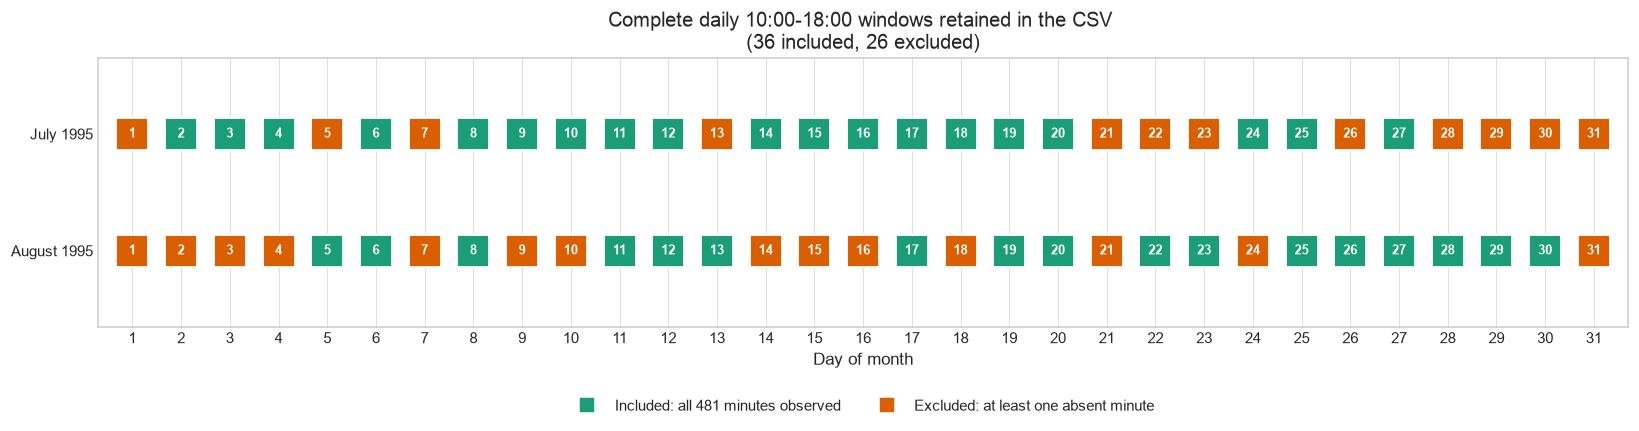

In [75]:
daily_inclusion_plot = daily_paper_window_summary.reset_index().copy()
daily_inclusion_plot["date"] = pd.to_datetime(
    daily_inclusion_plot["date"]
)
daily_inclusion_plot["included_in_csv"] = daily_inclusion_plot[
    "absent_minutes"
].eq(0)
daily_inclusion_plot["month"] = daily_inclusion_plot["date"].dt.strftime(
    "%B %Y"
)
daily_inclusion_plot["day"] = daily_inclusion_plot["date"].dt.day

included_count = int(daily_inclusion_plot["included_in_csv"].sum())
excluded_count = len(daily_inclusion_plot) - included_count
print(
    "The exported dataset consists of minute-level data only from days "
    "without absent minutes. Recorded zero counts remain valid observations."
)

month_order = daily_inclusion_plot["month"].drop_duplicates().tolist()
month_positions = {
    month: len(month_order) - position - 1
    for position, month in enumerate(month_order)
}
status_colors = {True: "#1b9e77", False: "#d95f02"}

fig, ax = plt.subplots(figsize=(15, 4.2))
for included, color in status_colors.items():
    subset = daily_inclusion_plot.loc[
        daily_inclusion_plot["included_in_csv"].eq(included)
    ]
    y_positions = subset["month"].map(month_positions)
    ax.scatter(
        subset["day"],
        y_positions,
        marker="s",
        s=430,
        color=color,
        edgecolor="white",
        linewidth=1.2,
        zorder=2,
    )
    for day, y_position in zip(subset["day"], y_positions):
        ax.text(
            day,
            y_position,
            str(day),
            ha="center",
            va="center",
            color="white",
            fontsize=8.5,
            fontweight="bold",
            zorder=3,
        )

ax.set(
    title=(
        "Complete daily 10:00-18:00 windows retained in the CSV "
        "\n"
        f"({included_count} included, {excluded_count} excluded)"
    ),
    xlabel="Day of month",
    xlim=(0.3, 31.7),
    ylim=(-0.65, len(month_order) - 0.35),
    xticks=np.arange(1, 32),
    yticks=list(month_positions.values()),
    yticklabels=list(month_positions.keys()),
)
ax.grid(axis="x", color="#dddddd", linewidth=0.6, zorder=0)
ax.grid(axis="y", visible=False)
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=status_colors[True],
        markeredgecolor="white",
        markersize=11,
        label="Included: all 481 minutes observed",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="none",
        markerfacecolor=status_colors[False],
        markeredgecolor="white",
        markersize=11,
        label="Excluded: at least one absent minute",
    ),
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
    frameon=False,
)
plt.tight_layout()
plt.show()


### 2.1 Diagnose and visualize daily-window coverage

The calendar plot above gives an immediate inclusion map: green dates have all 481 required timestamps and are written to the CSV; orange dates have at least one absent minute and are excluded. The diagnostic below adds two quantitative views using the already calculated daily summary—it does not construct or filter the windows a second time.

Across the 62 candidate dates,

$$
|\mathcal{C}|=36
$$

windows are complete and 26 are incomplete. The left panel reports $A_d$, the number of absent minutes on each date. A value of 481 means that the entire 10:00–18:00 window is absent. The right panel compares the total numbers of complete and incomplete days.

These plots help distinguish an actual observed low count from a loss of coverage. In particular, the long interruption around the end of July and beginning of August is visible as large blocks of absent minutes. The modeling dataset contains **only minute data from dates without absent minutes**. No incomplete date is partially retained, and missing timestamps are never converted to zeros.


Calendar days examined: 62
Days with at least one absent minute from 10:00–18:00: 26
Days with all 481 minutes observed: 36

Affected days and absent-minute counts
      date  absent_minutes_10_to_18
1995-07-01                        6
1995-07-05                        2
1995-07-07                        2
1995-07-13                       11
1995-07-21                        2
1995-07-22                        1
1995-07-23                        2
1995-07-26                        9
1995-07-28                      268
1995-07-29                      481
1995-07-30                      481
1995-07-31                      481
1995-08-01                      195
1995-08-02                      481
1995-08-03                       68
1995-08-04                        2
1995-08-07                       11
1995-08-09                        4
1995-08-10                        2
1995-08-14                        1
1995-08-15                        4
1995-08-16                        3
1995-08-

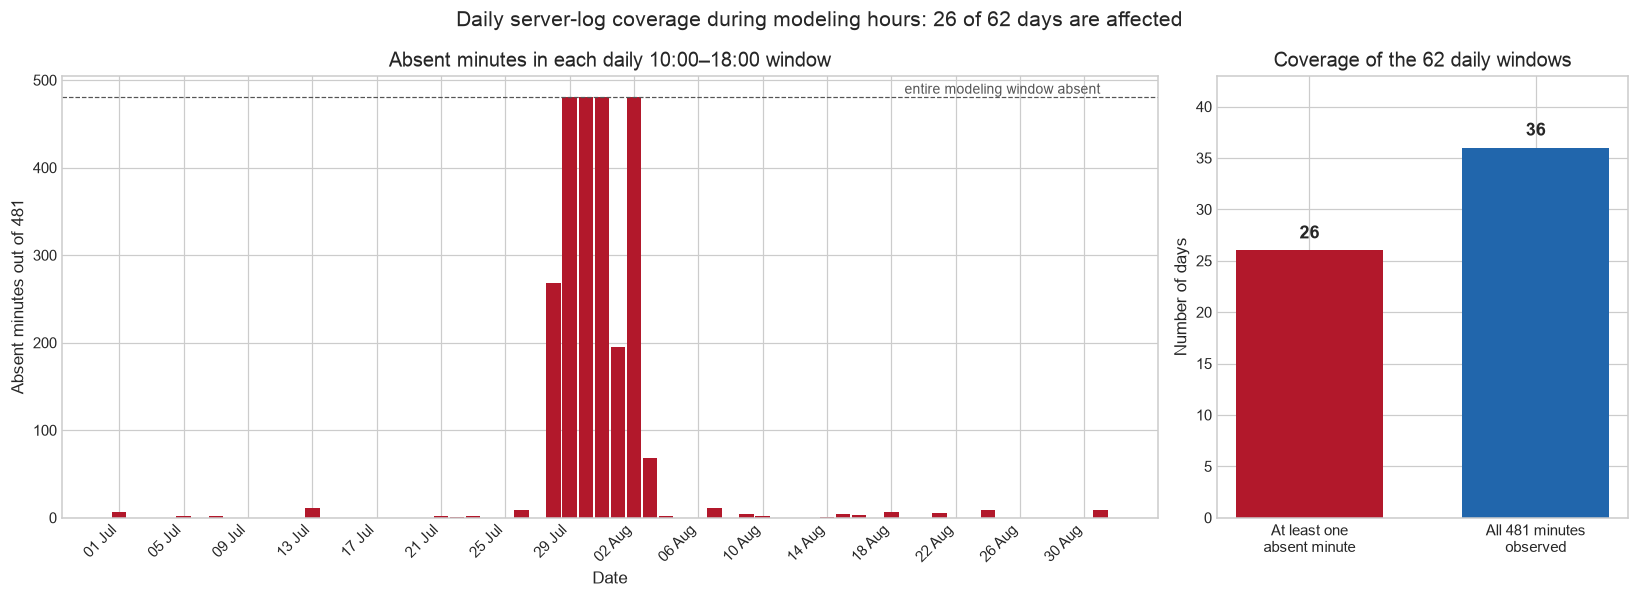

In [76]:
modeling_window_coverage = (
    daily_paper_window_summary.reset_index()
    .rename(columns={"absent_minutes": "absent_minutes_10_to_18"})
)
modeling_window_coverage["date"] = pd.to_datetime(
    modeling_window_coverage["date"]
)
modeling_window_coverage["has_absent_minute"] = modeling_window_coverage[
    "absent_minutes_10_to_18"
].gt(0)
analysis_days = modeling_window_coverage["date"]
days_with_absence = int(modeling_window_coverage["has_absent_minute"].sum())
days_fully_observed = int(len(modeling_window_coverage) - days_with_absence)

print(f"Calendar days examined: {len(modeling_window_coverage)}")
print(f"Days with at least one absent minute from 10:00–18:00: {days_with_absence}")
print(f"Days with all 481 minutes observed: {days_fully_observed}")

print("\nAffected days and absent-minute counts")
print(
    modeling_window_coverage.loc[
        modeling_window_coverage["has_absent_minute"],
        ["date", "absent_minutes_10_to_18"],
    ].to_string(index=False)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    gridspec_kw={"width_ratios": [3.2, 1.2]},
)

day_positions = np.arange(len(modeling_window_coverage))
daily_colors = np.where(
    modeling_window_coverage["has_absent_minute"], "#b2182b", "#67a9cf"
)
axes[0].bar(
    day_positions,
    modeling_window_coverage["absent_minutes_10_to_18"],
    color=daily_colors,
    width=0.9,
    edgecolor="none",
)
axes[0].set(
    title="Absent minutes in each daily 10:00–18:00 window",
    xlabel="Date",
    ylabel="Absent minutes out of 481",
    ylim=(0, 505),
)
day_tick_positions = np.arange(0, len(modeling_window_coverage), 4)
axes[0].set_xticks(
    day_tick_positions,
    [analysis_days[i].strftime("%d %b") for i in day_tick_positions],
    rotation=45,
    ha="right",
)
axes[0].axhline(481, color="#555555", linestyle="--", linewidth=0.8)
axes[0].text(
    len(modeling_window_coverage) - 1,
    481,
    " entire modeling window absent",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)

summary_labels = ["At least one\nabsent minute", "All 481 minutes\nobserved"]
summary_values = [days_with_absence, days_fully_observed]
summary_colors = ["#b2182b", "#2166ac"]
summary_bars = axes[1].bar(
    summary_labels, summary_values, color=summary_colors, width=0.65
)
axes[1].set(
    title="Coverage of the 62 daily windows",
    ylabel="Number of days",
    ylim=(0, max(summary_values) + 7),
)
for bar, value in zip(summary_bars, summary_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        str(value),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

fig.suptitle(
    f"Daily server-log coverage during modeling hours: "
    f"{days_with_absence} of {len(modeling_window_coverage)} days are affected",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 3. Inspect representative complete daily unique-host series

Before averaging or fitting distributions, it is useful to see how individual complete days differ. This section plots ten of the 36 fully observed daily `unique_hosts` series. The selection is deterministic and spreads the examples across the ordered list of complete dates; it is not a search for unusually smooth or convenient days.

Let the complete dates in chronological order be

$$
d_{(0)},d_{(1)},\ldots,d_{(D-1)},\qquad D=36.
$$

For plot number $j\in\{0,\ldots,9\}$, the chosen position is approximately

$$
i_j=\operatorname{round}\!\left(\frac{j(D-1)}{9}\right).
$$

The selected date is $d_{(i_j)}$. This evenly spaced rule makes the selection reproducible and gives coverage across both months.

For a selected date $d$, the displayed series is

$$
Y_{d,1},Y_{d,2},\ldots,Y_{d,481},
$$

where $Y_{d,m}$ is the number of distinct server-wide hosts at minute position $m$. All panels use the same horizontal and vertical scales:

- minute 1 is 10:00 and minute 481 is 18:00;
- the vertical axis is the number of distinct hosts in that minute; and
- the title reports the daily mean and maximum.

The plots reveal substantial differences in overall level and local variation between dates. They also show why dates should remain separate: the observation at 18:00 on one date is not followed one minute later by 10:00 on the next retained date.


Fully observed 10:00–18:00 daily windows: 36
Selected days
 plot       date  absent_minutes_10_to_18 mean_distinct_hosts  maximum_distinct_hosts
    1 1995-07-02                        0               18.83                      37
    2 1995-07-08                        0               12.06                      24
    3 1995-07-12                        0               32.65                      54
    4 1995-07-17                        0               28.14                      45
    5 1995-07-24                        0               22.59                      43
    6 1995-08-05                        0                9.07                      18
    7 1995-08-12                        0               10.31                      20
    8 1995-08-20                        0                9.45                      17
    9 1995-08-26                        0                8.52                      20
   10 1995-08-30                        0               26.03                    

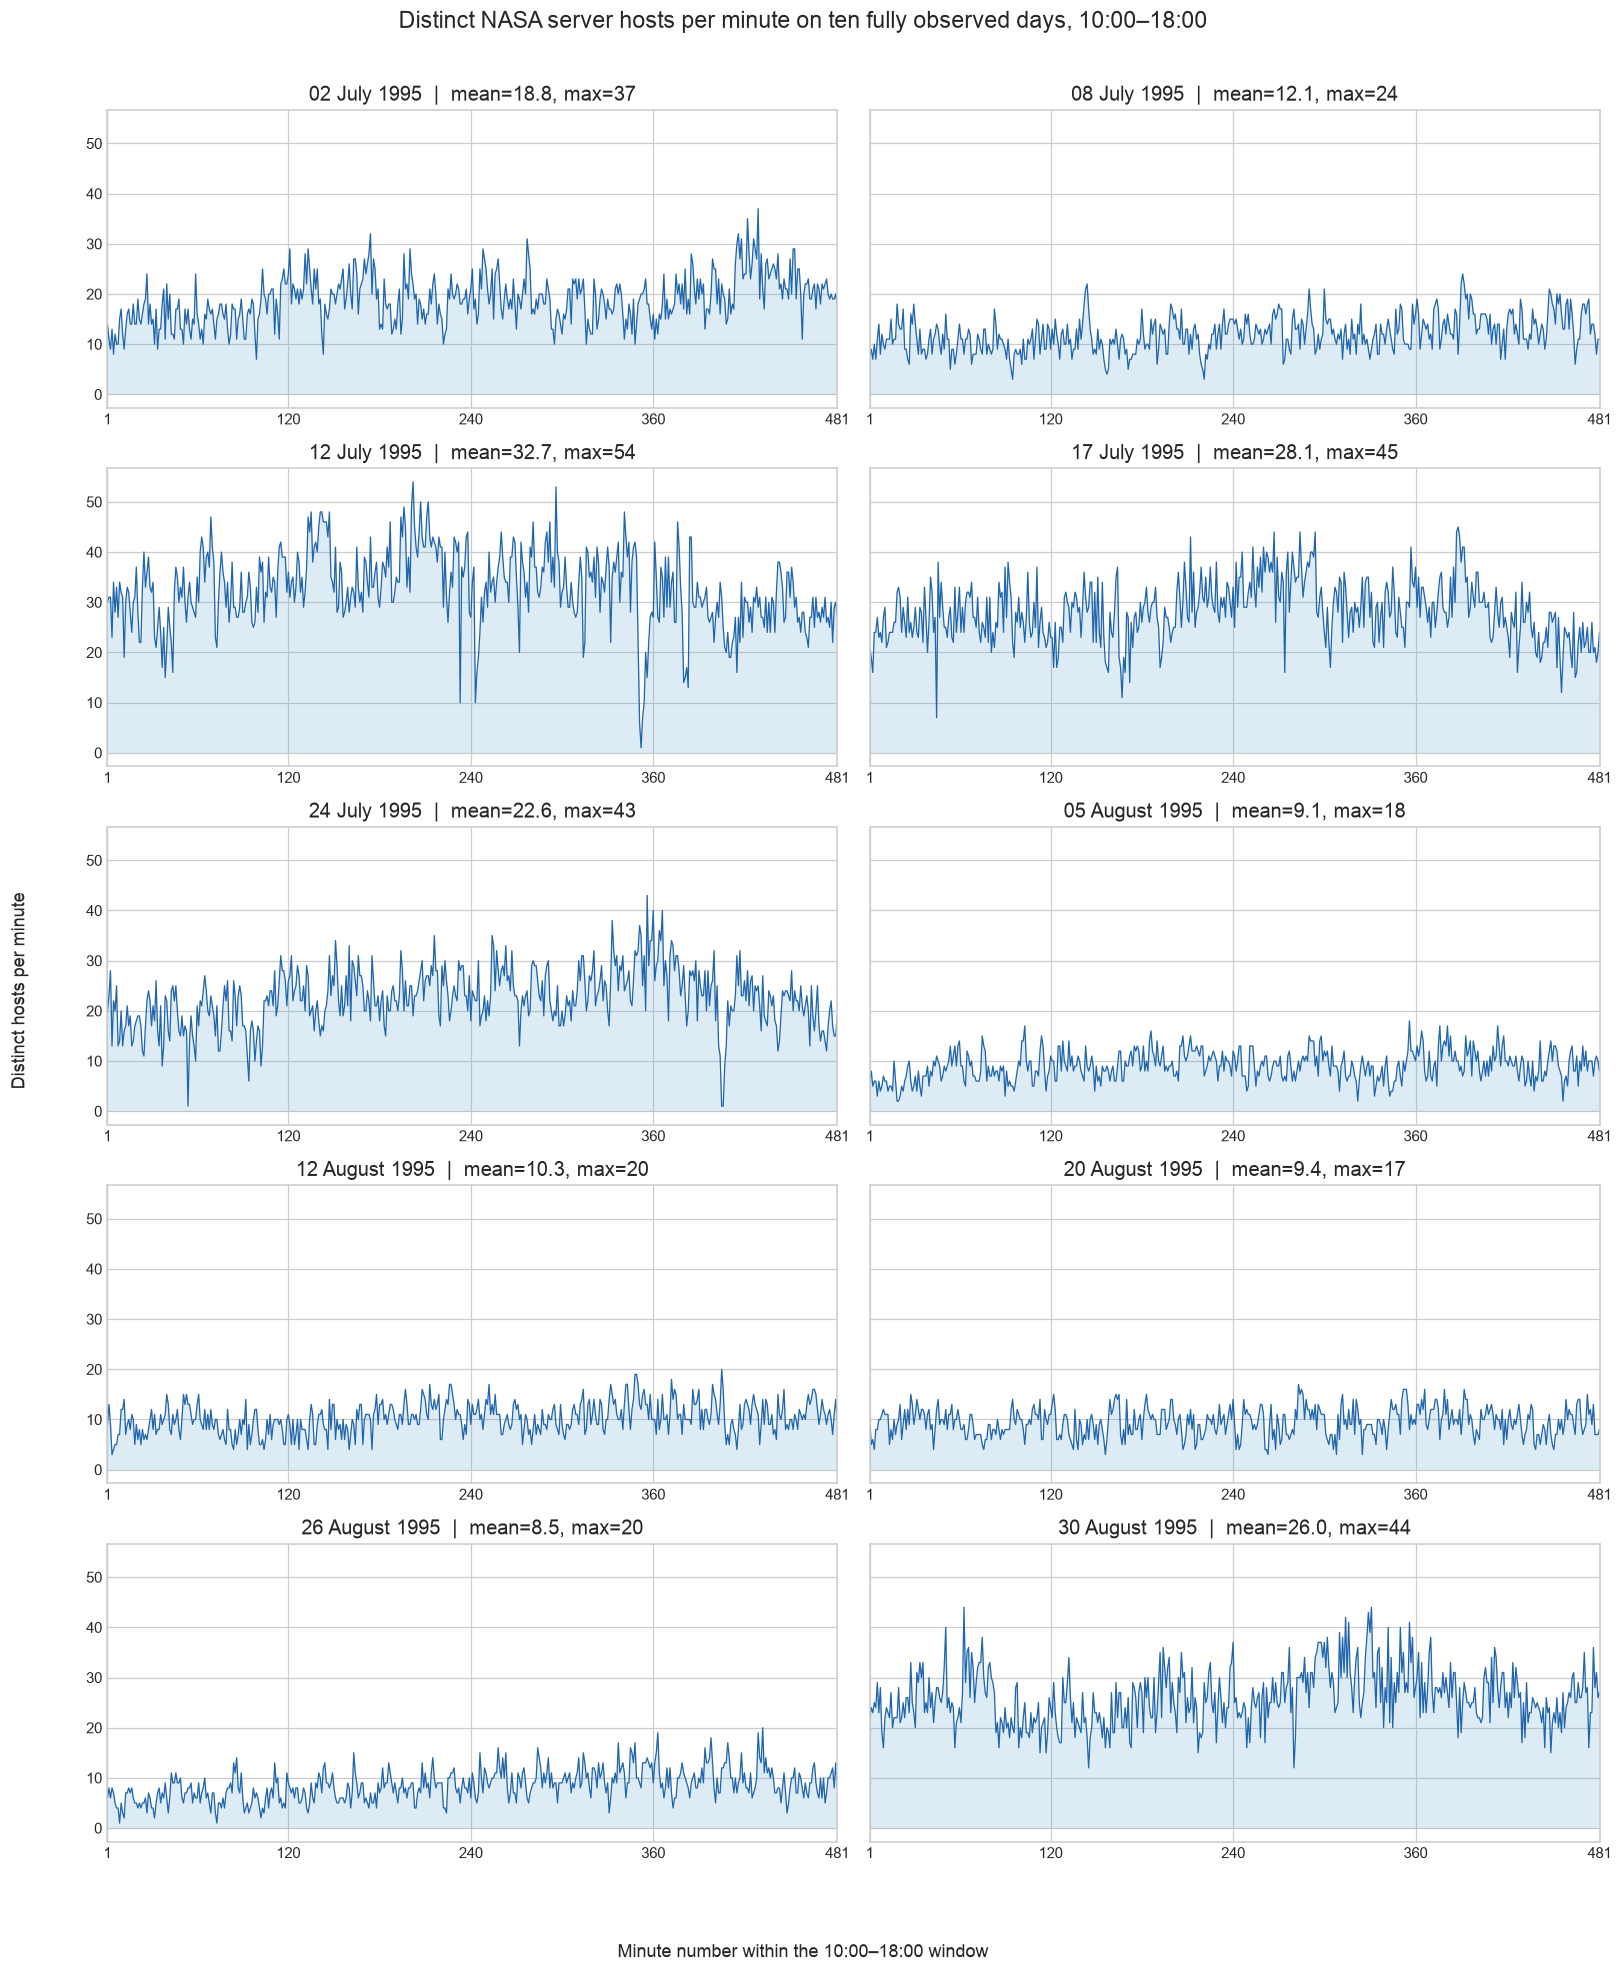

In [77]:
candidate_days = paper_window_days

complete_daily_windows = []
for day in candidate_days:
    window_index = pd.date_range(
        day + pd.Timedelta(hours=10),
        day + pd.Timedelta(hours=18),
        freq="1min",
    )
    window = minute_df.reindex(window_index)
    if window["requests"].notna().all():
        complete_daily_windows.append((day, window))

if len(complete_daily_windows) < 10:
    raise ValueError("Fewer than ten fully observed daily windows are available")

# Select ten positions evenly across the chronologically ordered complete days.
selected_positions = np.rint(
    np.linspace(0, len(complete_daily_windows) - 1, 10)
).astype(int)
selected_daily_windows = [complete_daily_windows[i] for i in selected_positions]

selected_day_table = pd.DataFrame(
    {
        "plot": np.arange(1, 11),
        "date": [day.strftime("%Y-%m-%d") for day, _ in selected_daily_windows],
        "absent_minutes_10_to_18": [
            int(window["requests"].isna().sum())
            for _, window in selected_daily_windows
        ],
        "mean_distinct_hosts": [
            window["unique_hosts"].mean() for _, window in selected_daily_windows
        ],
        "maximum_distinct_hosts": [
            int(window["unique_hosts"].max()) for _, window in selected_daily_windows
        ],
    }
)

print(f"Fully observed 10:00–18:00 daily windows: {len(complete_daily_windows)}")
print("Selected days")
print(
    selected_day_table.to_string(
        index=False,
        formatters={"mean_distinct_hosts": "{:.2f}".format},
    )
)

fig, axes = plt.subplots(5, 2, figsize=(15, 18), sharex=True, sharey=True)
minute_number = np.arange(1, 482)

for ax, (day, window) in zip(axes.flat, selected_daily_windows):
    distinct_hosts = window["unique_hosts"].to_numpy(dtype=int)
    ax.plot(minute_number, distinct_hosts, color="#2166ac", linewidth=0.85)
    ax.fill_between(
        minute_number, distinct_hosts, color="#67a9cf", alpha=0.22, linewidth=0
    )
    ax.set_title(
        f"{day:%d %B %Y}  |  mean={distinct_hosts.mean():.1f}, "
        f"max={distinct_hosts.max()}"
    )
    ax.set_xlim(1, 481)
    ax.set_xticks([1, 120, 240, 360, 481])
    ax.tick_params(axis="x", labelbottom=True)

fig.suptitle(
    "Distinct NASA server hosts per minute on ten fully observed days, 10:00–18:00",
    fontsize=15,
    y=0.995,
)
fig.supxlabel("Minute number within the 10:00–18:00 window", fontsize=12)
fig.supylabel("Distinct hosts per minute", fontsize=12)
plt.tight_layout(rect=(0.035, 0.035, 1, 0.985))
plt.show()

## 4. Estimate the common intraday seasonal mean

The daily plots suggest that unique-host activity changes systematically with time of day. This section estimates that common intraday pattern without applying classical time-series decomposition and without joining separate dates.

### 4.1 Arrange the data as a balanced panel

Let $D=36$ be the number of complete dates and $M=481$ the number of minute positions. Define

$$
Y_{d,m}=\text{number of unique hosts on date }d\text{ at position }m,
$$

for $d=1,\ldots,D$ and $m=1,\ldots,M$. The data are pivoted into a $D\times M$ matrix:

| Date | $m=1$ (10:00) | $m=2$ (10:01) | $\cdots$ | $m=481$ (18:00) |
|---|---:|---:|---:|---:|
| Date 1 | $Y_{1,1}$ | $Y_{1,2}$ | $\cdots$ | $Y_{1,481}$ |
| Date 2 | $Y_{2,1}$ | $Y_{2,2}$ | $\cdots$ | $Y_{2,481}$ |
| $\vdots$ | $\vdots$ | $\vdots$ | $\ddots$ | $\vdots$ |
| Date 36 | $Y_{36,1}$ | $Y_{36,2}$ | $\cdots$ | $Y_{36,481}$ |

This is a **balanced panel** because every date supplies all 481 positions. The row boundary is meaningful: $Y_{d,481}$ and $Y_{d',1}$ are not treated as consecutive minute observations.

### 4.2 Average the same clock minute across dates

For every position $m$, the cross-date average is

$$
\overline{Y}_m=\frac{1}{D}\sum_{d=1}^{D}Y_{d,m}.
$$

For example,

$$
\overline{Y}_{1}
=
\frac{Y_{1,1}+Y_{2,1}+\cdots+Y_{36,1}}{36}
$$

is the average unique-host count at 10:00. Repeating this calculation for all $m$ produces one 481-point average profile. Although every $Y_{d,m}$ is an integer, $\overline{Y}_m$ need not be an integer.

Averaging suppresses fluctuations that are specific to one date while retaining changes shared at the same clock time. The resulting curve estimates the minute-specific mean

$$
s_m=\operatorname{E}(Y_{d,m}),
$$

where $s_m$ is interpreted as the common intraday seasonal component over the observed 10:00–18:00 interval.

### 4.3 Smooth the 481 averages with a non-cyclic cubic spline

The 481 averages remain noisy because each is based on only 36 dates. A cubic regression spline provides a smooth descriptive estimate $f(m)$ of their changing level. In basis form,

$$
f(m)=\sum_{j=1}^{J}\beta_j B_j(m),
$$

where $B_j(m)$ are cubic B-spline basis functions and $\beta_j$ are fitted coefficients. With fixed interior knots at 11:00, 12:00, …, 17:00, the coefficients are chosen by least squares:

$$
\widehat{\boldsymbol{\beta}}
=
\operatorname*{arg\,min}_{\boldsymbol{\beta}}
\sum_{m=1}^{481}
\left[
\overline{Y}_m-
\sum_{j=1}^{J}\beta_jB_j(m)
\right]^2.
$$

The spline is **regular and non-cyclic**. A cyclic spline would impose endpoint conditions such as

$$
f(1)=f(481),
$$

and usually matching endpoint derivatives. That would incorrectly treat 18:00 as adjacent to 10:00. Because the intervening 16 hours are not observed, the fitted values and slopes at the two endpoints are allowed to differ.

This procedure estimates a common within-window mean curve; it is not a classical decomposition into trend, seasonal, and residual series. Date-to-date level differences and within-day stochastic dependence remain in the original observations.


In [78]:
# Rows remain separated by date; columns are the 481 within-day minutes.
distinct_host_panel = (
    fully_observed_minute_df_10_to_18.pivot(
        index="date",
        columns="minute_in_window",
        values="unique_hosts",
    )
    .sort_index()
    .sort_index(axis=1)
)
if (
    distinct_host_panel.shape
    != (len(fully_observed_days), minutes_per_paper_window)
    or distinct_host_panel.isna().any().any()
):
    raise AssertionError(
        "Expected one complete 481-minute row for every retained date"
    )

average_minute_profile = (
    distinct_host_panel.mean(axis=0)
    .rename("average_unique_hosts")
    .to_frame()
)
average_minute_profile["clock_time"] = (
    pd.Timestamp("2000-01-01 10:00")
    + pd.to_timedelta(
        average_minute_profile.index.to_numpy() - 1,
        unit="min",
    )
)

print(
    f"Balanced panel: {distinct_host_panel.shape[0]} dates x "
    f"{distinct_host_panel.shape[1]} within-day minutes."
)
print("No lags are calculated across daily boundaries.")
average_minute_profile.head()


Balanced panel: 36 dates x 481 within-day minutes.
No lags are calculated across daily boundaries.


,average_unique_hosts,clock_time
minute_in_window,,
1,16.527778,2000-01-01 10:00:00
2,16.083333,2000-01-01 10:01:00
3,15.555556,2000-01-01 10:02:00
4,15.25,2000-01-01 10:03:00
5,15.805556,2000-01-01 10:04:00


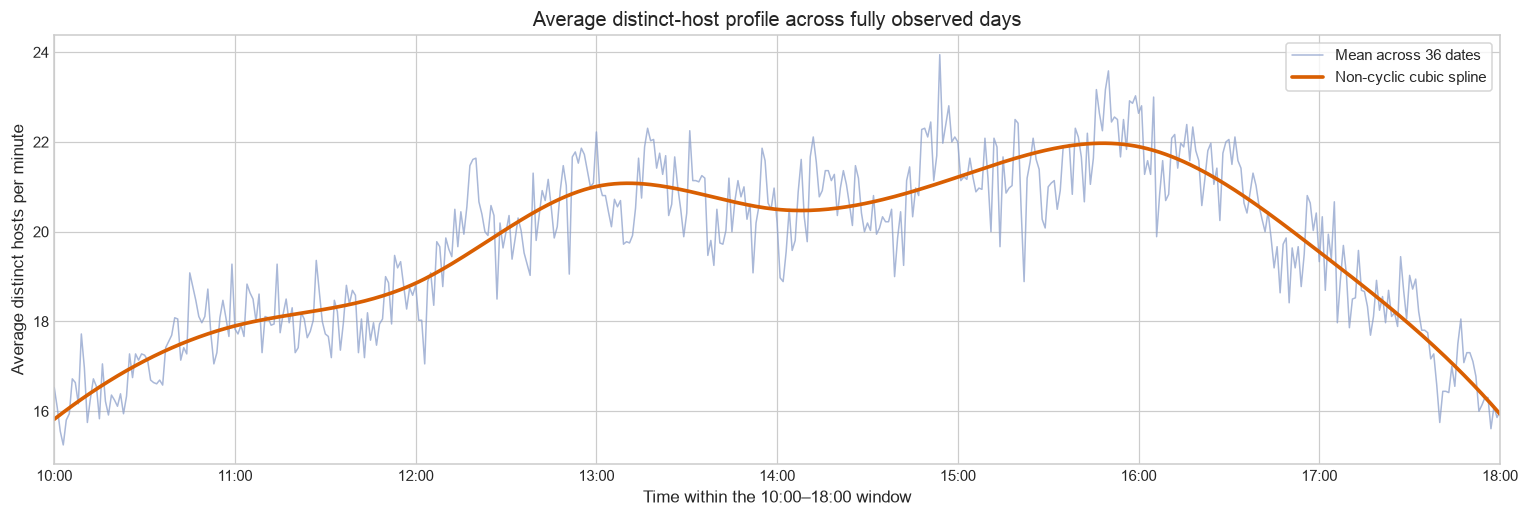

In [79]:
from scipy.interpolate import LSQUnivariateSpline

profile_x = average_minute_profile.index.to_numpy(dtype=float)
profile_y = average_minute_profile["average_unique_hosts"].to_numpy(
    dtype=float
)
# Hourly interior knots give a regular cubic spline without joining 18:00 to 10:00.
spline_knots = np.arange(61, minutes_per_paper_window, 60, dtype=float)
intraday_spline = LSQUnivariateSpline(
    profile_x, profile_y, t=spline_knots, k=3
)
average_minute_profile["noncyclic_spline"] = intraday_spline(profile_x)

clock_tick_positions = np.arange(1, minutes_per_paper_window + 1, 60)
clock_tick_labels = pd.date_range(
    "2000-01-01 10:00",
    "2000-01-01 18:00",
    freq="1h",
).strftime("%H:%M")

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(
    profile_x,
    profile_y,
    color="#8da0cb",
    linewidth=1.0,
    alpha=0.75,
    label="Mean across 36 dates",
)
ax.plot(
    profile_x,
    average_minute_profile["noncyclic_spline"],
    color="#d95f02",
    linewidth=2.4,
    label="Non-cyclic cubic spline",
)
ax.set(
    title="Average distinct-host profile across fully observed days",
    xlabel="Time within the 10:00–18:00 window",
    ylabel="Average distinct hosts per minute",
    xlim=(1, minutes_per_paper_window),
    xticks=clock_tick_positions,
    xticklabels=clock_tick_labels,
)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


### 4.4 Interpretation of the non-cyclic spline

The fitted profile rises from the morning into the afternoon, reaches its highest level around 15:00–16:00, and then declines toward 18:00. Therefore, the expected number of unique hosts is not constant across the 481 minute positions. The plot provides clear evidence of one recurring **daily intraday seasonal component** within the observed window.

If the fitted spline is denoted by $\widehat{s}_m$, then a simple additive description is

$$
Y_{d,m}=\widehat{s}_m+e_{d,m},
$$

where $e_{d,m}$ contains date-specific departures and short-run dependence. This equation is descriptive: the notebook has estimated $\widehat{s}_m$ but has not yet fitted a complete probabilistic model for $e_{d,m}$.

Because the raw mean depends on $m$, the unadjusted observations cannot be weakly stationary across the full 10:00–18:00 interval. The next subsection removes the centered spline effect and exports a transparent derived dataset. Section 5 then reports baseline stationarity diagnostics for the original daily counts.


### 4.5 Remove the estimated seasonal component and save a new dataset

The spline $\widehat{s}_m$ estimates the smooth expected host count at minute position $m$. Directly calculating $Y_{d,m}-\widehat{s}_m$ would produce residuals centered near zero, including negative and noninteger values. Such residuals are useful for diagnostics but are not a count series and therefore cannot be used directly as the response in an INAR model.

To remove the intraday shape while retaining the overall count level, first define the average fitted level

$$
\overline{s}
=
\frac{1}{481}\sum_{m=1}^{481}\widehat{s}_m.
$$

The centered seasonal component is

$$
\widehat{c}_m=\widehat{s}_m-\overline{s}.
$$

By construction, the 481 centered seasonal effects average to zero. Positive values of $\widehat{c}_m$ identify times when the fitted activity is above the overall daily-window level, while negative values identify times when it is below that level.

The continuous seasonally adjusted value is

$$
Z_{d,m}
=
Y_{d,m}-\widehat{c}_m
=
Y_{d,m}-\widehat{s}_m+\overline{s}.
$$

This transformation subtracts the fitted time-of-day deviation but adds the overall level back. Before nonnegativity constraints and rounding, it preserves the grand sample mean because

$$
\frac{1}{36\times481}
\sum_{d=1}^{36}\sum_{m=1}^{481}Z_{d,m}
=
\frac{1}{36\times481}
\sum_{d=1}^{36}\sum_{m=1}^{481}Y_{d,m}.
$$

The continuous values are retained in the output so that the transformation can be audited. A second column provides a nonnegative integer version:

$$
Z^{\mathrm{int}}_{d,m}
=
\operatorname{round}\!\left(\max(0,Z_{d,m})\right).
$$

The implementation uses `numpy.rint`, which rounds to the nearest integer and resolves an exact half-integer by choosing the nearest even integer. Exact half-integers are unlikely here because the spline values are continuous. Clipping at zero is necessary for only 2 of the 17,316 observations. For all non-clipped observations, nearest-integer rounding changes a value by at most 0.5.

The new CSV preserves all columns from the complete-window dataset and adds:

- `fitted_intraday_mean`: $\widehat{s}_m$;
- `centered_intraday_seasonal_component`: $\widehat{c}_m$;
- `unique_hosts_seasonally_adjusted_continuous`: $Z_{d,m}$ before clipping and rounding; and
- `unique_hosts_seasonally_adjusted`: the final nonnegative integer $Z^{\mathrm{int}}_{d,m}$.

The file is saved as `data/NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv`. The integer column is a pragmatic derived series for exploratory count modeling. Rounding and clipping slightly alter its mean and distribution, so formal regression modeling should preferably retain the original counts and represent $\widehat{s}_m$ through a mean function, offset, or seasonal covariate. The original `unique_hosts` column remains in the new file and is never overwritten.


Saved 17,316 rows to /Users/andja/Projects/projekti_doktorske/nasa/data/NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv
Spline reference level: 19.673
Centered seasonal component range: -3.851 to 2.298
Continuous values clipped at zero: 2
Original and continuous-adjusted mean: 19.673
Integer-adjusted mean after clipping and rounding: 19.709
Maximum nearest-integer rounding error: 0.500
Range of the fitted spline after integer adjustment: 0.423 hosts


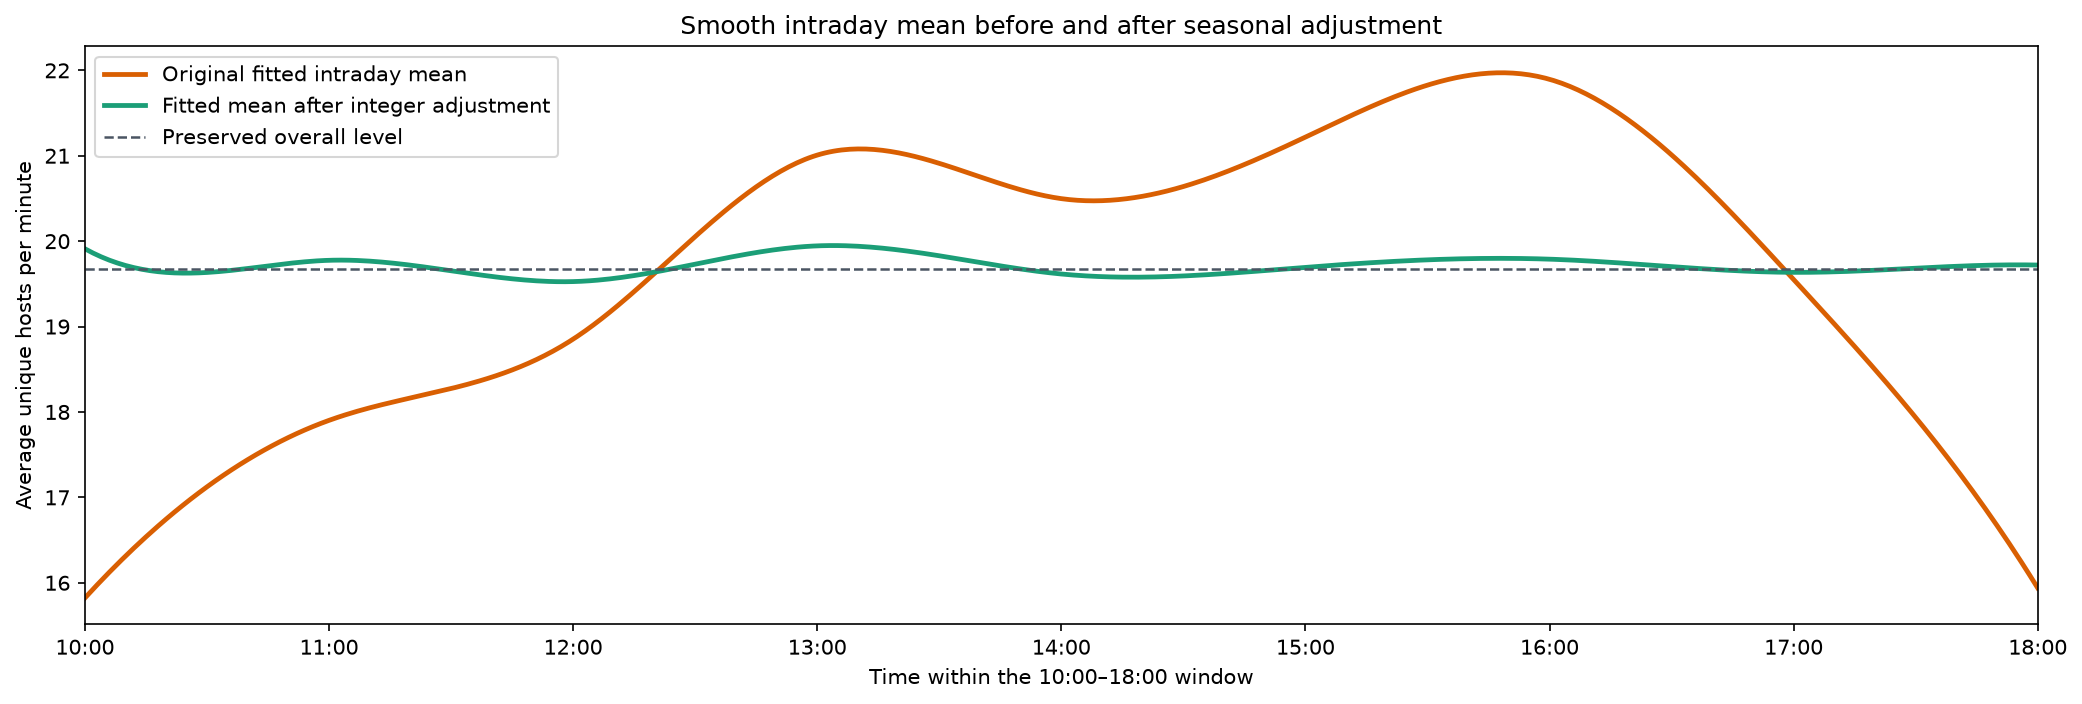

In [ ]:
# Attach the fitted minute-specific mean to every complete daily window.
seasonal_adjustment_profile = (
    average_minute_profile[["noncyclic_spline"]]
    .rename(columns={"noncyclic_spline": "fitted_intraday_mean"})
    .reset_index()
)
seasonal_reference_level = seasonal_adjustment_profile[
    "fitted_intraday_mean"
].mean()
seasonal_adjustment_profile[
    "centered_intraday_seasonal_component"
] = (
    seasonal_adjustment_profile["fitted_intraday_mean"]
    - seasonal_reference_level
)

seasonally_adjusted_minute_df_10_to_18 = (
    fully_observed_minute_df_10_to_18.merge(
        seasonal_adjustment_profile,
        on="minute_in_window",
        how="left",
        validate="many_to_one",
        sort=False,
    )
)

# Remove the centered spline effect. Keep this continuous value for auditing.
seasonally_adjusted_minute_df_10_to_18[
    "unique_hosts_seasonally_adjusted_continuous"
] = (
    seasonally_adjusted_minute_df_10_to_18["unique_hosts"].astype(float)
    - seasonally_adjusted_minute_df_10_to_18[
        "centered_intraday_seasonal_component"
    ]
)

continuous_adjusted_hosts = seasonally_adjusted_minute_df_10_to_18[
    "unique_hosts_seasonally_adjusted_continuous"
]
negative_before_clipping = int(continuous_adjusted_hosts.lt(0).sum())
nonnegative_adjusted_hosts = continuous_adjusted_hosts.clip(lower=0)

# numpy.rint performs deterministic nearest-integer rounding (ties to even).
seasonally_adjusted_minute_df_10_to_18[
    "unique_hosts_seasonally_adjusted"
] = np.rint(nonnegative_adjusted_hosts).astype("Int64")

adjusted_host_column = "unique_hosts_seasonally_adjusted"
new_adjustment_columns = [
    "fitted_intraday_mean",
    "centered_intraday_seasonal_component",
    "unique_hosts_seasonally_adjusted_continuous",
    adjusted_host_column,
]
if seasonally_adjusted_minute_df_10_to_18[new_adjustment_columns].isna().any().any():
    raise AssertionError("The seasonal adjustment produced a missing value")
if not seasonally_adjusted_minute_df_10_to_18[adjusted_host_column].ge(0).all():
    raise AssertionError("The integer-adjusted count must be nonnegative")
if not seasonally_adjusted_minute_df_10_to_18.groupby("date").size().eq(
    minutes_per_paper_window
).all():
    raise AssertionError("Every adjusted date must still contain 481 rows")
if not np.isclose(
    continuous_adjusted_hosts.mean(),
    seasonally_adjusted_minute_df_10_to_18["unique_hosts"].mean(),
):
    raise AssertionError("The continuous adjustment did not preserve the grand mean")

seasonally_adjusted_csv = (
    DATA_DIR / "NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv"
)
seasonally_adjusted_minute_df_10_to_18.to_csv(
    seasonally_adjusted_csv,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
    float_format="%.6f",
)

# Verify that the smooth intraday shape is nearly flat after integerization.
adjusted_average_profile = (
    seasonally_adjusted_minute_df_10_to_18.groupby(
        "minute_in_window", sort=True
    )[adjusted_host_column]
    .mean()
    .astype(float)
)
adjusted_intraday_spline = LSQUnivariateSpline(
    profile_x,
    adjusted_average_profile.to_numpy(),
    t=spline_knots,
    k=3,
)(profile_x)

rounding_error = np.abs(
    seasonally_adjusted_minute_df_10_to_18[adjusted_host_column].astype(float)
    - nonnegative_adjusted_hosts
)
original_grand_mean = seasonally_adjusted_minute_df_10_to_18[
    "unique_hosts"
].mean()
adjusted_integer_mean = seasonally_adjusted_minute_df_10_to_18[
    adjusted_host_column
].mean()

print(
    f"Saved {len(seasonally_adjusted_minute_df_10_to_18):,} rows to "
    f"{seasonally_adjusted_csv.resolve()}"
)
print(f"Spline reference level: {seasonal_reference_level:.3f}")
print(
    "Centered seasonal component range: "
    f"{seasonal_adjustment_profile['centered_intraday_seasonal_component'].min():.3f} "
    "to "
    f"{seasonal_adjustment_profile['centered_intraday_seasonal_component'].max():.3f}"
)
print(f"Continuous values clipped at zero: {negative_before_clipping}")
print(f"Original and continuous-adjusted mean: {original_grand_mean:.3f}")
print(f"Integer-adjusted mean after clipping and rounding: {adjusted_integer_mean:.3f}")
print(f"Maximum nearest-integer rounding error: {rounding_error.max():.3f}")
print(
    "Range of the fitted spline after integer adjustment: "
    f"{np.ptp(adjusted_intraday_spline):.3f} hosts"
)

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(
    profile_x,
    average_minute_profile["noncyclic_spline"],
    color="#d95f02",
    linewidth=2.3,
    label="Original fitted intraday mean",
)
ax.plot(
    profile_x,
    adjusted_intraday_spline,
    color="#1b9e77",
    linewidth=2.3,
    label="Fitted mean after integer adjustment",
)
ax.axhline(
    seasonal_reference_level,
    color="#4b5563",
    linestyle="--",
    linewidth=1.2,
    label="Preserved overall level",
)
ax.set(
    title="Smooth intraday mean before and after seasonal adjustment",
    xlabel="Time within the 10:00–18:00 window",
    ylabel="Average unique hosts per minute",
    xlim=(1, minutes_per_paper_window),
    xticks=clock_tick_positions,
    xticklabels=clock_tick_labels,
)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


### 4.6 Plot the same ten days after seasonal adjustment

This figure reuses the exact ten dates selected in section 3. No new sample is drawn. Keeping the dates, chronological panel order, 481-minute horizontal axis, and shared vertical scale makes the original and seasonally adjusted plots directly comparable.

For each selected date $d$, the plotted series is

$$
Z^{\mathrm{int}}_{d,1},Z^{\mathrm{int}}_{d,2},\ldots,Z^{\mathrm{int}}_{d,481},
$$

where $Z^{\mathrm{int}}_{d,m}$ is the nonnegative integer-adjusted count created in subsection 4.5. The dashed horizontal line is the preserved overall level $\overline{s}\approx19.673$. Panel titles report the adjusted daily mean and maximum.

The adjusted series are not expected to become flat. The procedure removes the smooth **average time-of-day effect shared across the 36 dates**. It deliberately retains minute-to-minute variation, serial dependence, bursts, and differences in overall traffic level between dates. Comparison with section 3 should therefore focus on the within-day shape: the common morning rise, afternoon peak, and evening decline should be much less pronounced, while genuine short-run fluctuations remain visible.


Same ten dates as section 3
 plot       date adjusted_mean  adjusted_minimum  adjusted_maximum
    1 1995-07-02         18.87                 8                38
    2 1995-07-08         12.09                 2                23
    3 1995-07-12         32.69                 0                53
    4 1995-07-17         28.17                 9                44
    5 1995-07-24         22.63                 0                41
    6 1995-08-05          9.11                 0                18
    7 1995-08-12         10.34                 3                19
    8 1995-08-20          9.48                 1                18
    9 1995-08-26          8.56                 1                21
   10 1995-08-30         26.07                11                46


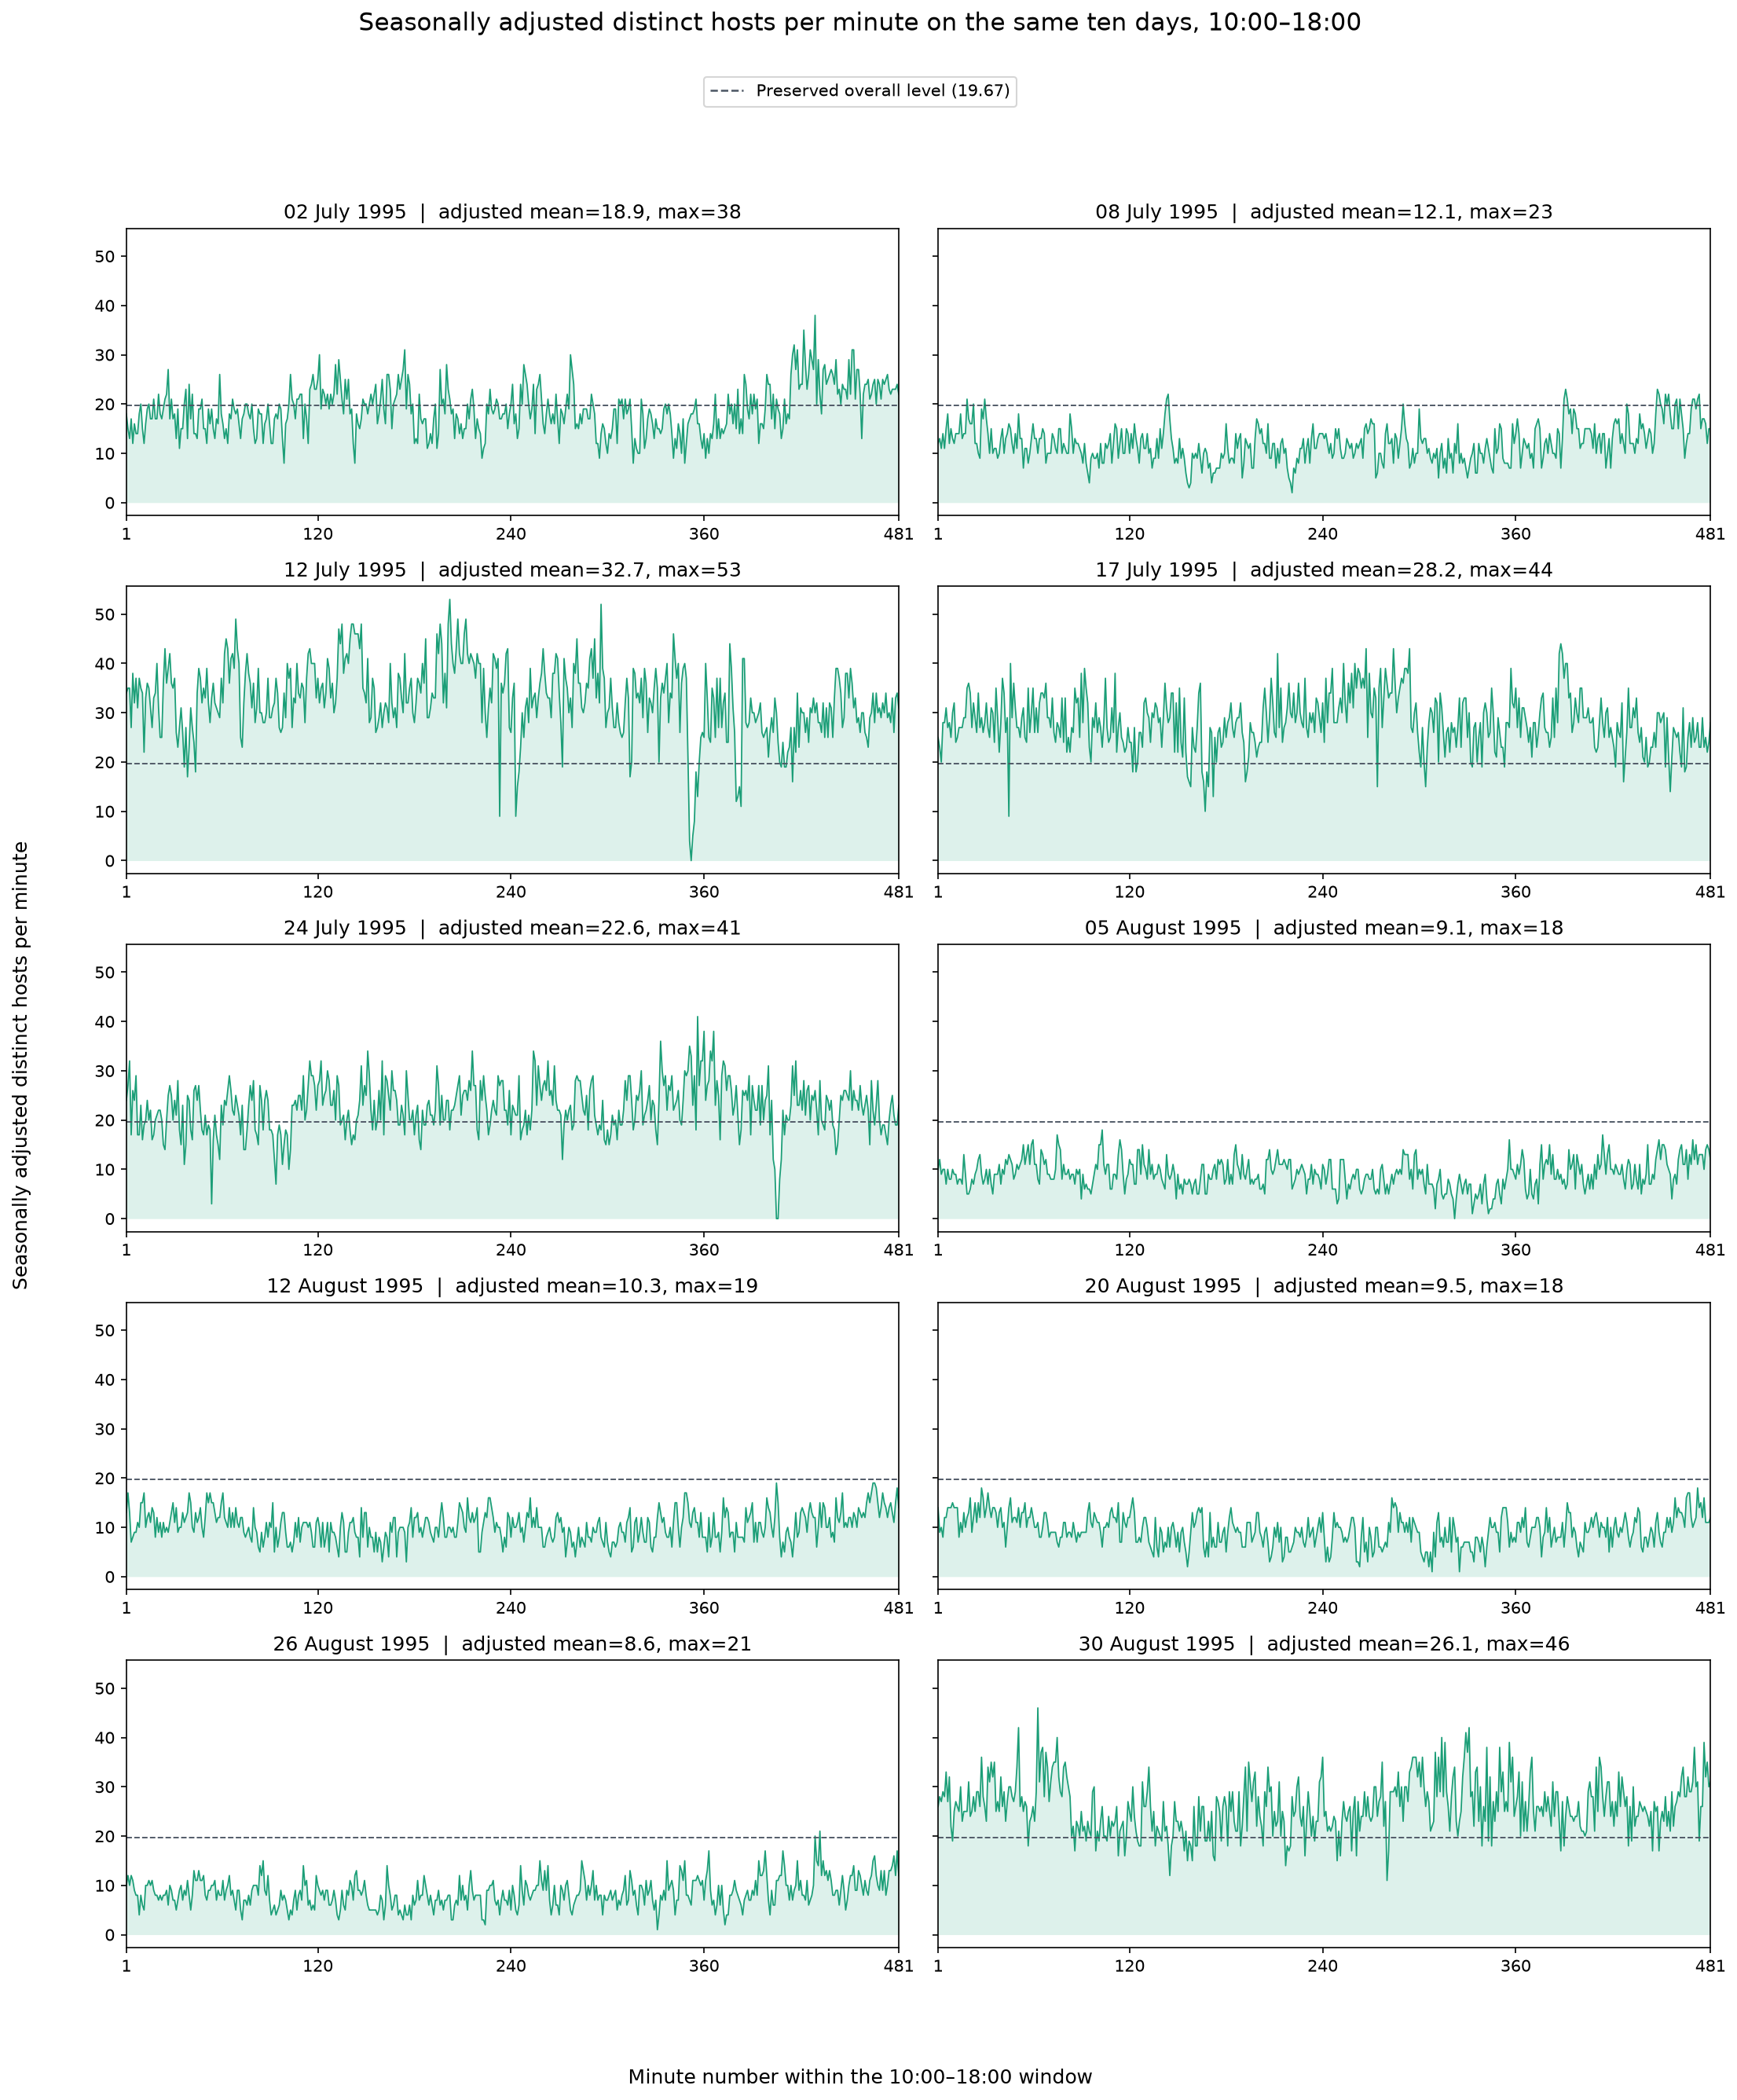

In [ ]:
# Reuse the same ten deterministic dates selected for the original plots.
same_ten_adjusted_days = pd.DatetimeIndex(
    pd.to_datetime(selected_day_table["date"])
)
adjusted_ten_day_plot_data = seasonally_adjusted_minute_df_10_to_18.copy()
adjusted_ten_day_plot_data["plot_date"] = pd.to_datetime(
    adjusted_ten_day_plot_data["date"]
).dt.normalize()

adjusted_ten_day_records = []
adjusted_ten_day_series = []
for plot_number, day in enumerate(same_ten_adjusted_days, start=1):
    daily_adjusted_counts = (
        adjusted_ten_day_plot_data.loc[
            adjusted_ten_day_plot_data["plot_date"].eq(day.normalize()),
            ["minute_in_window", "unique_hosts_seasonally_adjusted"],
        ]
        .sort_values("minute_in_window")
        ["unique_hosts_seasonally_adjusted"]
        .to_numpy(dtype=int)
    )
    if len(daily_adjusted_counts) != minutes_per_paper_window:
        raise AssertionError(
            f"{day:%Y-%m-%d} does not contain exactly 481 adjusted counts"
        )

    adjusted_ten_day_series.append((day, daily_adjusted_counts))
    adjusted_ten_day_records.append(
        {
            "plot": plot_number,
            "date": day.strftime("%Y-%m-%d"),
            "adjusted_mean": daily_adjusted_counts.mean(),
            "adjusted_minimum": daily_adjusted_counts.min(),
            "adjusted_maximum": daily_adjusted_counts.max(),
        }
    )

adjusted_ten_day_summary = pd.DataFrame(adjusted_ten_day_records)
print("Same ten dates as section 3")
print(
    adjusted_ten_day_summary.to_string(
        index=False,
        formatters={"adjusted_mean": "{:.2f}".format},
    )
)

fig_adjusted_ten_days, axes = plt.subplots(
    5,
    2,
    figsize=(15, 18),
    sharex=True,
    sharey=True,
)
adjusted_minute_number = np.arange(1, minutes_per_paper_window + 1)

for axis, (day, daily_adjusted_counts) in zip(
    axes.flat, adjusted_ten_day_series
):
    axis.plot(
        adjusted_minute_number,
        daily_adjusted_counts,
        color="#1b9e77",
        linewidth=0.85,
    )
    axis.fill_between(
        adjusted_minute_number,
        daily_adjusted_counts,
        color="#66c2a5",
        alpha=0.22,
        linewidth=0,
    )
    axis.axhline(
        seasonal_reference_level,
        color="#4b5563",
        linestyle="--",
        linewidth=0.9,
    )
    axis.set_title(
        f"{day:%d %B %Y}  |  adjusted mean={daily_adjusted_counts.mean():.1f}, "
        f"max={daily_adjusted_counts.max()}"
    )
    axis.set_xlim(1, minutes_per_paper_window)
    axis.set_xticks([1, 120, 240, 360, 481])
    axis.tick_params(axis="x", labelbottom=True)

fig_adjusted_ten_days.suptitle(
    "Seasonally adjusted distinct hosts per minute on the same ten days, "
    "10:00–18:00",
    fontsize=15,
    y=0.997,
)
fig_adjusted_ten_days.supxlabel(
    "Minute number within the 10:00–18:00 window",
    fontsize=12,
    y=0.018,
)
fig_adjusted_ten_days.supylabel(
    "Seasonally adjusted distinct hosts per minute",
    fontsize=12,
)
reference_handle = plt.Line2D(
    [0],
    [0],
    color="#4b5563",
    linestyle="--",
    linewidth=1.2,
    label=f"Preserved overall level ({seasonal_reference_level:.2f})",
)
fig_adjusted_ten_days.legend(
    handles=[reference_handle],
    loc="upper center",
    frameon=True,
    bbox_to_anchor=(0.5, 0.970),
)
plt.tight_layout(rect=(0.035, 0.045, 1, 0.935))
plt.show()


## 5. Diagnose stationarity before and after seasonal adjustment

This section applies the same within-day stationarity diagnostics to two balanced panels:

1. the original distinct-host counts $Y_{d,m}$; and
2. the nonnegative integer seasonally adjusted counts $Z^{\mathrm{int}}_{d,m}$ saved in subsection 4.5.

Both panels contain the same 36 dates and the same 481 minute positions from 10:00 through 18:00. The comparison therefore changes the response values but not the observation window, missing-minute policy, test settings, or significance threshold. Every ADF and KPSS test receives one date at a time, so a test lag never crosses a daily boundary.

In the definitions below, $X_{d,m}$ denotes whichever of these two series is being tested.

### 5.1 Meaning of weak stationarity

For a fixed date $d$, a weakly stationary series satisfies, for every valid minute $m$ and lag $k$,

$$
\operatorname{E}(X_{d,m})=\mu_d,
$$

$$
\operatorname{Var}(X_{d,m})=\sigma_d^2,
$$

and

$$
\operatorname{Cov}(X_{d,m},X_{d,m-k})=\gamma_d(k).
$$

The mean and variance must not change with clock time inside that date, and covariance may depend on the distance $k$ but not on the particular minute $m$. Removing the average spline profile directly targets the first condition. It does not automatically guarantee constant variance or time-invariant serial dependence.

### 5.2 Augmented Dickey–Fuller test

The ADF regression has the general form

$$
\Delta X_m
=
\alpha+\gamma X_{m-1}
+
\sum_{j=1}^{p}\psi_j\Delta X_{m-j}
+\varepsilon_m,
$$

where $\Delta X_m=X_m-X_{m-1}$. Its null hypothesis is $H_0:\gamma=0$, corresponding to a unit root, and its alternative is $H_1:\gamma<0$. Therefore:

- ADF $p<0.05$: reject the unit-root null;
- ADF $p\geq0.05$: there is insufficient evidence to reject a unit root.

The implementation includes a constant and selects the number of augmentation lags $p$ by minimizing Akaike's information criterion,

$$
\operatorname{AIC}=-2\log(\widehat{L})+2q,
$$

where $\widehat{L}$ is the maximized likelihood and $q$ is the number of estimated parameters.

### 5.3 KPSS level-stationarity test

The KPSS test reverses the null hypothesis. A useful representation is

$$
X_m=\mu+r_m+\varepsilon_m,
\qquad
r_m=r_{m-1}+u_m.
$$

Under level stationarity, the innovation variance of the random-walk component is zero: $H_0:\operatorname{Var}(u_m)=0$. The alternative allows a stochastic change in level. If $e_m$ are residuals after removing the estimated constant and $S_t=\sum_{m=1}^{t}e_m$, the KPSS statistic has the form

$$
\operatorname{KPSS}
=
\frac{\sum_{t=1}^{n}S_t^2}
{n^2\widehat{\omega}^2},
$$

where $\widehat{\omega}^2$ estimates the long-run residual variance. The code uses automatic lag selection for this variance estimate. Therefore:

- KPSS $p<0.05$: reject level stationarity;
- KPSS $p\geq0.05$: do not reject level stationarity.

### 5.4 Joint decision rule

The two tests have opposite null hypotheses and are interpreted together at $\alpha=0.05$:

| ADF result | KPSS result | Working interpretation |
|---|---|---|
| Reject unit root | Do not reject level stationarity | Evidence consistent with level stationarity |
| Do not reject unit root | Reject level stationarity | Evidence of nonstationarity |
| Reject unit root | Reject level stationarity | Not a unit-root random walk, but not constant-level stationary; a changing deterministic mean is plausible |
| Do not reject unit root | Do not reject level stationarity | Inconclusive because neither test supplies decisive evidence |

These are screening tests, not proofs. Both were developed for linear time-series settings, whereas these observations are discrete counts with serial dependence. Performing 36 pairs of tests also means that individual decisions should not be interpreted without considering the full pattern of results and the plotted series.


### 5.5 Results for the original unique-host counts

The first application uses the original `unique_hosts` panel $Y_{d,m}$. It provides the baseline against which the effect of removing the common intraday seasonal mean will be evaluated. The following cell reports every daily ADF and KPSS result, summarizes the joint classifications, and the next figure places each $p$-value against the common 5% decision threshold.


In [80]:
import warnings

from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss


def classify_stationarity(adf_pvalue: float, kpss_pvalue: float) -> str:
    adf_rejects_unit_root = adf_pvalue < 0.05
    kpss_rejects_stationarity = kpss_pvalue < 0.05
    if adf_rejects_unit_root and not kpss_rejects_stationarity:
        return "Evidence consistent with level stationarity"
    if not adf_rejects_unit_root and kpss_rejects_stationarity:
        return "Evidence of nonstationarity"
    if adf_rejects_unit_root and kpss_rejects_stationarity:
        return "Changing mean / conflicting nulls"
    return "Inconclusive"


stationarity_records = []
for date, daily_counts in distinct_host_panel.iterrows():
    # Each test receives exactly one 481-minute window.
    values = daily_counts.to_numpy(dtype=float)
    adf_test = adfuller(values, autolag="AIC", result_object=True)
    with warnings.catch_warnings():
        # KPSS reports bounded table p-values (for example, p <= 0.01).
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_test = kpss(
            values,
            regression="c",
            nlags="auto",
            result_object=True,
        )

    stationarity_records.append(
        {
            "date": pd.Timestamp(date),
            "observations": len(values),
            "adf_statistic": adf_test.statistic,
            "adf_pvalue": adf_test.pvalue,
            "adf_lags": adf_test.lags,
            "kpss_statistic": kpss_test.statistic,
            "kpss_pvalue": kpss_test.pvalue,
            "kpss_lags": kpss_test.lags,
            "assessment": classify_stationarity(
                adf_test.pvalue, kpss_test.pvalue
            ),
        }
    )

stationarity_results = pd.DataFrame(stationarity_records)
stationarity_summary = (
    stationarity_results["assessment"]
    .value_counts()
    .rename_axis("assessment")
    .rename("days")
    .to_frame()
)

print("Stationarity assessment for the 36 separate daily windows")
print(stationarity_summary.to_string())
print(
    f"\nADF rejects a unit root on "
    f"{(stationarity_results['adf_pvalue'] < 0.05).sum()} of 36 days."
)
print(
    f"KPSS rejects level stationarity on "
    f"{(stationarity_results['kpss_pvalue'] < 0.05).sum()} of 36 days."
)

stationarity_results.round(
    {
        "adf_statistic": 3,
        "adf_pvalue": 4,
        "kpss_statistic": 3,
        "kpss_pvalue": 4,
    }
)


Stationarity assessment for the 36 separate daily windows
                                             days
assessment                                       
Changing mean / conflicting nulls              27
Evidence consistent with level stationarity     8
Evidence of nonstationarity                     1

ADF rejects a unit root on 35 of 36 days.
KPSS rejects level stationarity on 28 of 36 days.


,date,observations,adf_statistic,adf_pvalue,adf_lags,kpss_statistic,kpss_pvalue,kpss_lags,assessment
0,1995-07-02,481,-6.102,0.0000,3,1.251,0.0100,11,Changing mean / conflicting nulls
1,1995-07-03,481,-5.235,0.0000,5,0.517,0.0378,10,Changing mean / conflicting nulls
2,1995-07-04,481,-7.730,0.0000,2,0.166,0.1000,10,Evidence consistent with level stationarity
3,1995-07-06,481,-4.090,0.0010,8,0.677,0.0157,10,Changing mean / conflicting nulls
4,1995-07-08,481,-8.236,0.0000,2,2.001,0.0100,10,Changing mean / conflicting nulls
5,1995-07-09,481,-4.325,0.0004,6,1.301,0.0100,10,Changing mean / conflicting nulls
6,1995-07-10,481,-3.760,0.0033,10,0.761,0.0100,10,Changing mean / conflicting nulls
7,1995-07-11,481,-3.128,0.0246,12,1.015,0.0100,11,Changing mean / conflicting nulls
8,1995-07-12,481,-4.838,0.0000,5,0.760,0.0100,10,Changing mean / conflicting nulls
9,1995-07-14,481,-5.358,0.0000,4,0.286,0.1000,10,Evidence consistent with level stationarity


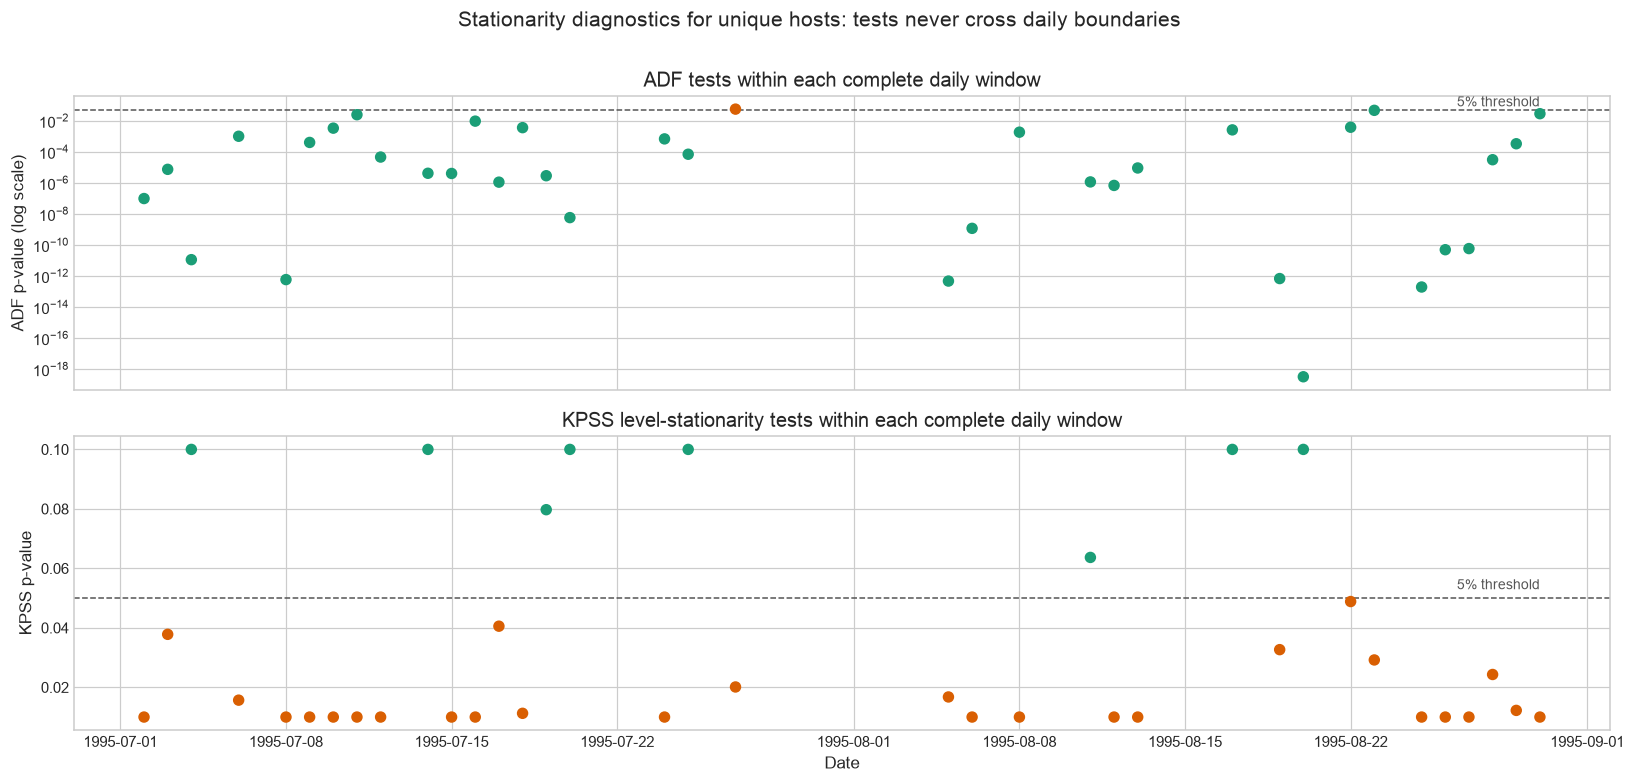

In [81]:
plot_dates = stationarity_results["date"]
adf_rejects = stationarity_results["adf_pvalue"].lt(0.05)
kpss_rejects = stationarity_results["kpss_pvalue"].lt(0.05)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
axes[0].scatter(
    plot_dates,
    stationarity_results["adf_pvalue"],
    c=np.where(adf_rejects, "#1b9e77", "#d95f02"),
    s=42,
    zorder=3,
)
axes[0].axhline(0.05, color="#555555", linestyle="--", linewidth=1)
axes[0].set_yscale("log")
axes[0].set(
    title="ADF tests within each complete daily window",
    ylabel="ADF p-value (log scale)",
)
axes[0].text(
    plot_dates.max(),
    0.055,
    "5% threshold",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)

axes[1].scatter(
    plot_dates,
    stationarity_results["kpss_pvalue"],
    c=np.where(kpss_rejects, "#d95f02", "#1b9e77"),
    s=42,
    zorder=3,
)
axes[1].axhline(0.05, color="#555555", linestyle="--", linewidth=1)
axes[1].set(
    title="KPSS level-stationarity tests within each complete daily window",
    xlabel="Date",
    ylabel="KPSS p-value",
)
axes[1].text(
    plot_dates.max(),
    0.052,
    "5% threshold",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)

fig.suptitle(
    "Stationarity diagnostics for unique hosts: tests never cross daily boundaries",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()


### 5.6 Representative original daily windows from each assessment

The test summary shows how many dates fall into each assessment, but it does not show the time-domain patterns that produced those decisions. This subsection plots representative original daily windows from all three observed categories:

- three dates from `Changing mean / conflicting nulls`;
- three dates from `Evidence consistent with level stationarity`; and
- the one date classified as `Evidence of nonstationarity`.

The examples are selected reproducibly rather than chosen by visual appearance. Within a category containing $n_g$ chronologically ordered dates, $r_g=3$ examples are taken from the evenly spaced positions

$$
i_j
=
\operatorname{round}\!\left(
\frac{j(n_g-1)}{r_g-1}
\right),
\qquad j=0,1,2.
$$

This selects an early, middle, and late date from the category. The nonstationary category contains only one date, so that date is shown automatically. Here, “representative” means chronologically distributed across the category; it does not mean that the dates were chosen to make the visual differences appear especially large.

Every panel contains the original 481 `unique_hosts` observations tested in section 5. The dashed line is that date's arithmetic mean,

$$
\overline{Y}_d
=
\frac{1}{481}\sum_{m=1}^{481}Y_{d,m}.
$$

All panels share the same axes. The titles report the ADF and KPSS $p$-values used by the classification rule. These plots should be interpreted together with the tests: a series classified as level-stationary can still fluctuate strongly, and a “conflicting nulls” result does not identify a particular deterministic trend by itself.


Representative original daily windows by stationarity assessment
                                 assessment       date daily_mean  daily_minimum  daily_maximum ADF p-value KPSS p-value
          Changing mean / conflicting nulls 1995-07-02      18.83              7             37      0.0000       0.0100
          Changing mean / conflicting nulls 1995-08-05       9.07              2             18      0.0000       0.0168
          Changing mean / conflicting nulls 1995-08-30      26.03             12             44      0.0286       0.0100
Evidence consistent with level stationarity 1995-07-04      23.82              3             40      0.0000       0.1000
Evidence consistent with level stationarity 1995-07-25      22.29              4             36      0.0001       0.1000
Evidence consistent with level stationarity 1995-08-20       9.45              3             17      0.0000       0.1000
                Evidence of nonstationarity 1995-07-27      20.49              6        

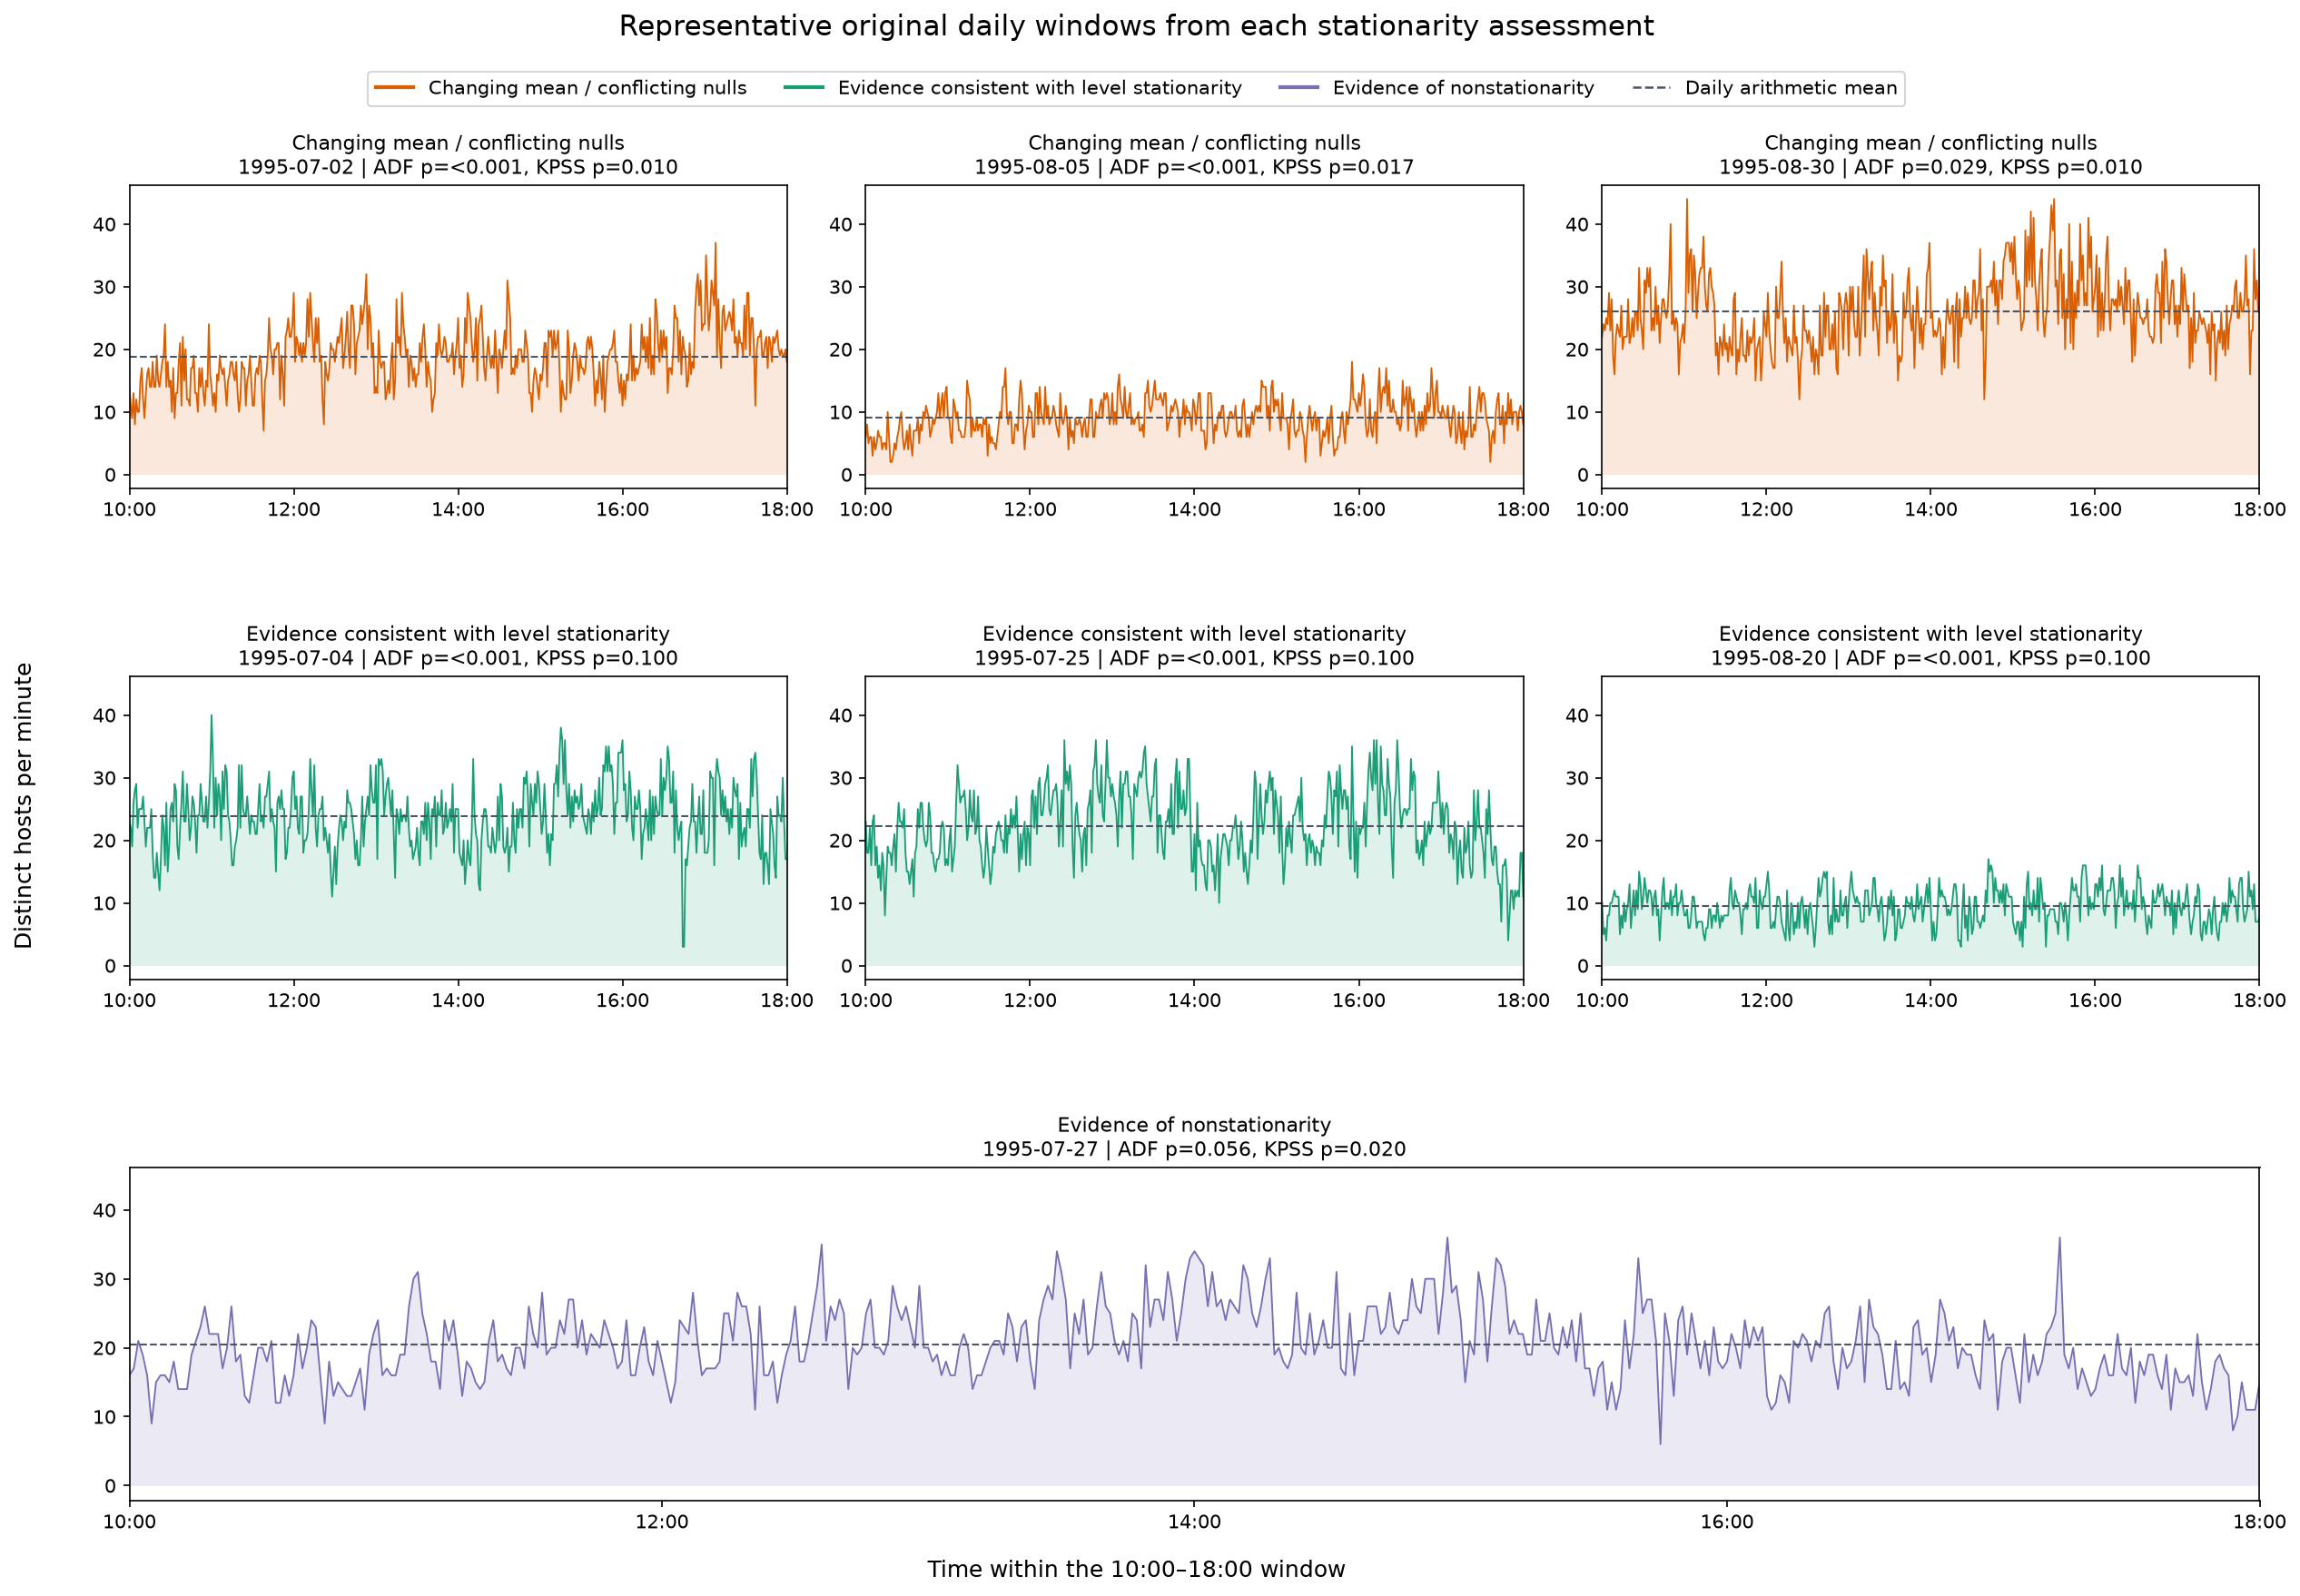

In [ ]:
from matplotlib.lines import Line2D


REPRESENTATIVE_EXAMPLES_PER_LARGE_GROUP = 3
assessment_plot_order = [
    "Changing mean / conflicting nulls",
    "Evidence consistent with level stationarity",
    "Evidence of nonstationarity",
]
assessment_colors = {
    "Changing mean / conflicting nulls": "#d95f02",
    "Evidence consistent with level stationarity": "#1b9e77",
    "Evidence of nonstationarity": "#7570b3",
}


def evenly_spaced_stationarity_examples(
    group: pd.DataFrame,
    number_of_examples: int,
) -> pd.DataFrame:
    """Select chronological positions without inspecting the plotted values."""
    ordered_group = group.sort_values("date").reset_index(drop=True)
    if len(ordered_group) <= number_of_examples:
        return ordered_group
    positions = np.rint(
        np.linspace(0, len(ordered_group) - 1, number_of_examples)
    ).astype(int)
    return ordered_group.iloc[positions].reset_index(drop=True)


representative_stationarity_frames = []
for assessment in assessment_plot_order:
    assessment_group = stationarity_results.loc[
        stationarity_results["assessment"].eq(assessment)
    ]
    requested_examples = (
        1
        if assessment == "Evidence of nonstationarity"
        else REPRESENTATIVE_EXAMPLES_PER_LARGE_GROUP
    )
    selected_group = evenly_spaced_stationarity_examples(
        assessment_group,
        requested_examples,
    ).copy()
    selected_group["assessment_order"] = assessment_plot_order.index(assessment)
    representative_stationarity_frames.append(selected_group)

representative_stationarity_examples = (
    pd.concat(representative_stationarity_frames, ignore_index=True)
    .sort_values(["assessment_order", "date"])
    .reset_index(drop=True)
)

# Map normalized timestamps back to the panel's original date-index objects.
panel_date_lookup = {
    pd.Timestamp(panel_date).normalize(): panel_date
    for panel_date in distinct_host_panel.index
}
representative_daily_series = []
representative_summary_records = []

for example in representative_stationarity_examples.itertuples(index=False):
    normalized_date = pd.Timestamp(example.date).normalize()
    panel_date = panel_date_lookup[normalized_date]
    daily_counts = distinct_host_panel.loc[panel_date].to_numpy(dtype=float)
    if len(daily_counts) != minutes_per_paper_window:
        raise AssertionError(
            f"{normalized_date:%Y-%m-%d} does not contain exactly 481 values"
        )

    representative_daily_series.append(
        {
            "assessment": example.assessment,
            "date": normalized_date,
            "values": daily_counts,
            "adf_pvalue": example.adf_pvalue,
            "kpss_pvalue": example.kpss_pvalue,
        }
    )
    representative_summary_records.append(
        {
            "assessment": example.assessment,
            "date": normalized_date.strftime("%Y-%m-%d"),
            "daily_mean": daily_counts.mean(),
            "daily_minimum": int(daily_counts.min()),
            "daily_maximum": int(daily_counts.max()),
            "ADF p-value": example.adf_pvalue,
            "KPSS p-value": example.kpss_pvalue,
        }
    )

representative_stationarity_summary = pd.DataFrame(
    representative_summary_records
)
print("Representative original daily windows by stationarity assessment")
print(
    representative_stationarity_summary.to_string(
        index=False,
        formatters={
            "daily_mean": "{:.2f}".format,
            "ADF p-value": "{:.4f}".format,
            "KPSS p-value": "{:.4f}".format,
        },
    )
)


def stationarity_pvalue_label(value: float) -> str:
    return "<0.001" if value < 0.001 else f"{value:.3f}"


fig_stationarity_examples = plt.figure(figsize=(17, 12))
grid = fig_stationarity_examples.add_gridspec(
    3,
    3,
    height_ratios=[1, 1, 1.1],
)

example_axes = []
for column in range(3):
    if not example_axes:
        axis = fig_stationarity_examples.add_subplot(grid[0, column])
    else:
        axis = fig_stationarity_examples.add_subplot(
            grid[0, column],
            sharex=example_axes[0],
            sharey=example_axes[0],
        )
    example_axes.append(axis)

for column in range(3):
    example_axes.append(
        fig_stationarity_examples.add_subplot(
            grid[1, column],
            sharex=example_axes[0],
            sharey=example_axes[0],
        )
    )

example_axes.append(
    fig_stationarity_examples.add_subplot(
        grid[2, :],
        sharex=example_axes[0],
        sharey=example_axes[0],
    )
)

stationarity_minute_number = np.arange(1, minutes_per_paper_window + 1)
stationarity_clock_positions = [1, 121, 241, 361, 481]
stationarity_clock_labels = ["10:00", "12:00", "14:00", "16:00", "18:00"]

for axis, example in zip(example_axes, representative_daily_series):
    line_color = assessment_colors[example["assessment"]]
    daily_values = example["values"]
    daily_mean = daily_values.mean()

    axis.plot(
        stationarity_minute_number,
        daily_values,
        color=line_color,
        linewidth=0.9,
    )
    axis.fill_between(
        stationarity_minute_number,
        daily_values,
        color=line_color,
        alpha=0.14,
        linewidth=0,
    )
    axis.axhline(
        daily_mean,
        color="#4b5563",
        linestyle="--",
        linewidth=1.0,
    )
    axis.set_title(
        f"{example['assessment']}\n"
        f"{example['date']:%Y-%m-%d} | "
        f"ADF p={stationarity_pvalue_label(example['adf_pvalue'])}, "
        f"KPSS p={stationarity_pvalue_label(example['kpss_pvalue'])}",
        fontsize=10.5,
    )
    axis.set_xlim(1, minutes_per_paper_window)
    axis.set_xticks(stationarity_clock_positions)
    axis.set_xticklabels(stationarity_clock_labels)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=assessment_colors[assessment],
        linewidth=2,
        label=assessment,
    )
    for assessment in assessment_plot_order
]
legend_handles.append(
    Line2D(
        [0],
        [0],
        color="#4b5563",
        linestyle="--",
        linewidth=1.2,
        label="Daily arithmetic mean",
    )
)

fig_stationarity_examples.suptitle(
    "Representative original daily windows from each stationarity assessment",
    fontsize=15,
    y=0.985,
)
fig_stationarity_examples.supxlabel(
    "Time within the 10:00–18:00 window",
    fontsize=12,
    y=0.025,
)
fig_stationarity_examples.supylabel(
    "Distinct hosts per minute",
    fontsize=12,
    x=0.015,
)
fig_stationarity_examples.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=4,
    frameon=True,
)
fig_stationarity_examples.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.075,
    top=0.88,
    hspace=0.60,
    wspace=0.12,
)
plt.show()


### 5.7 Interpretation of the original-count diagnostics

At the 5% threshold, the ADF test rejects a unit root on 35 of 36 dates, while the KPSS test rejects constant-level stationarity on 28 dates. Combining the two decisions gives:

- 27 dates for which both null hypotheses are rejected;
- 8 dates with results consistent with level stationarity; and
- 1 date for which ADF does not reject a unit root while KPSS rejects stationarity.

The frequent double rejection is not a logical contradiction. It says that most daily series do not resemble a unit-root random walk, but they also do not fluctuate around one fixed level. A smooth deterministic change in the mean—such as the intraday profile estimated above—can produce exactly this pattern.

The evidence therefore agrees with the spline: the raw `unique_hosts` counts should not be modeled as a constant-mean stationary series over the entire daily window. Because 36 pairs of tests are performed and the data are dependent counts, individual $p$-values should not be overinterpreted. Subsections 5.8–5.10 now repeat the complete procedure on the saved adjusted integer series, allowing the effect of seasonal removal to be assessed without changing the test settings.


### 5.8 Results for the seasonally adjusted integer counts

This analysis reloads `data/NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv` and tests the exported `unique_hosts_seasonally_adjusted` column. Testing the saved file confirms the behavior of the exact nonnegative integer series intended for exploratory count modeling, rather than an unsaved intermediate object.

For every date $d$ and minute position $m$, this response is

$$
Z^{\mathrm{int}}_{d,m}
=
\operatorname{round}\!\left[
\max\!\left(0,Y_{d,m}-\widehat{s}_m+\overline{s}\right)
\right].
$$

The same ADF specification, AIC lag selection, KPSS level test, automatic KPSS lag selection, 5% threshold, and joint classification rule used for the original counts are retained. Each test again receives exactly 481 observations from one date. The summary table directly compares the numbers of dates in each category before and after seasonal adjustment.


In [ ]:
adjusted_stationarity_csv = (
    DATA_DIR / "NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv"
)
adjusted_stationarity_df = pd.read_csv(
    adjusted_stationarity_csv,
    parse_dates=["minute", "date"],
)
adjusted_distinct_host_panel = (
    adjusted_stationarity_df.pivot(
        index="date",
        columns="minute_in_window",
        values="unique_hosts_seasonally_adjusted",
    )
    .sort_index()
    .sort_index(axis=1)
)

expected_adjusted_shape = (
    distinct_host_panel.shape[0],
    minutes_per_paper_window,
)
if adjusted_distinct_host_panel.shape != expected_adjusted_shape:
    raise AssertionError(
        "The adjusted panel does not have the expected 36-by-481 shape"
    )
if adjusted_distinct_host_panel.isna().any().any():
    raise AssertionError("The adjusted panel contains an absent minute")
if not adjusted_distinct_host_panel.index.equals(distinct_host_panel.index):
    raise AssertionError(
        "The adjusted and original panels do not contain the same dates"
    )

adjusted_stationarity_records = []
for date, daily_counts in adjusted_distinct_host_panel.iterrows():
    # Every test remains inside one 481-minute daily window.
    values = daily_counts.to_numpy(dtype=float)
    adf_test = adfuller(values, autolag="AIC", result_object=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_test = kpss(
            values,
            regression="c",
            nlags="auto",
            result_object=True,
        )

    adjusted_stationarity_records.append(
        {
            "date": pd.Timestamp(date),
            "observations": len(values),
            "adf_statistic": adf_test.statistic,
            "adf_pvalue": adf_test.pvalue,
            "adf_lags": adf_test.lags,
            "kpss_statistic": kpss_test.statistic,
            "kpss_pvalue": kpss_test.pvalue,
            "kpss_lags": kpss_test.lags,
            "assessment": classify_stationarity(
                adf_test.pvalue,
                kpss_test.pvalue,
            ),
        }
    )

adjusted_stationarity_results = pd.DataFrame(
    adjusted_stationarity_records
)
adjusted_stationarity_summary = (
    adjusted_stationarity_results["assessment"]
    .value_counts()
    .rename_axis("assessment")
    .rename("days")
    .to_frame()
)

comparison_assessment_order = [
    "Changing mean / conflicting nulls",
    "Evidence consistent with level stationarity",
    "Evidence of nonstationarity",
    "Inconclusive",
]
stationarity_count_comparison = pd.concat(
    {
        "Original unique_hosts": stationarity_summary["days"],
        "Seasonally adjusted unique_hosts": (
            adjusted_stationarity_summary["days"]
        ),
    },
    axis=1,
).fillna(0).astype(int).reindex(comparison_assessment_order, fill_value=0)

stationarity_comparison_by_date = stationarity_results.merge(
    adjusted_stationarity_results,
    on="date",
    suffixes=("_original", "_adjusted"),
    validate="one_to_one",
)
stationarity_transition_table = pd.crosstab(
    stationarity_comparison_by_date["assessment_original"],
    stationarity_comparison_by_date["assessment_adjusted"],
    rownames=["Original assessment"],
    colnames=["Adjusted assessment"],
)

print("Stationarity assessment for the adjusted 36 daily windows")
print(adjusted_stationarity_summary.to_string())
print(
    f"\nADF rejects a unit root on "
    f"{(adjusted_stationarity_results['adf_pvalue'] < 0.05).sum()} "
    "of 36 adjusted days."
)
print(
    f"KPSS rejects level stationarity on "
    f"{(adjusted_stationarity_results['kpss_pvalue'] < 0.05).sum()} "
    "of 36 adjusted days."
)
print("\nOriginal versus seasonally adjusted classification counts")
print(stationarity_count_comparison.to_string())
print("\nDate-level movement between classifications")
print(stationarity_transition_table.to_string())

adjusted_stationarity_results.round(
    {
        "adf_statistic": 3,
        "adf_pvalue": 4,
        "kpss_statistic": 3,
        "kpss_pvalue": 4,
    }
)


Stationarity assessment for the adjusted 36 daily windows
                                             days
assessment                                       
Changing mean / conflicting nulls              20
Evidence consistent with level stationarity    15
Evidence of nonstationarity                     1

ADF rejects a unit root on 35 of 36 adjusted days.
KPSS rejects level stationarity on 21 of 36 adjusted days.

Original versus seasonally adjusted classification counts
                                             Original unique_hosts  Seasonally adjusted unique_hosts
assessment                                                                                          
Changing mean / conflicting nulls                               27                                20
Evidence consistent with level stationarity                      8                                15
Evidence of nonstationarity                                      1                                 1
Inconclusive     

,date,observations,adf_statistic,adf_pvalue,adf_lags,kpss_statistic,kpss_pvalue,kpss_lags,assessment
0,1995-07-02,481,-5.783,0.0000,3,0.630,0.0199,11,Changing mean / conflicting nulls
1,1995-07-03,481,-6.090,0.0000,5,0.565,0.0270,9,Changing mean / conflicting nulls
2,1995-07-04,481,-7.584,0.0000,2,0.310,0.1000,10,Evidence consistent with level stationarity
3,1995-07-06,481,-5.078,0.0000,8,0.358,0.0952,9,Evidence consistent with level stationarity
4,1995-07-08,481,-5.188,0.0000,5,0.818,0.0100,10,Changing mean / conflicting nulls
5,1995-07-09,481,-4.552,0.0002,6,0.519,0.0373,10,Changing mean / conflicting nulls
6,1995-07-10,481,-12.901,0.0000,0,0.187,0.1000,9,Evidence consistent with level stationarity
7,1995-07-11,481,-6.477,0.0000,3,0.588,0.0237,10,Changing mean / conflicting nulls
8,1995-07-12,481,-5.008,0.0000,5,1.013,0.0100,10,Changing mean / conflicting nulls
9,1995-07-14,481,-5.733,0.0000,4,0.612,0.0216,10,Changing mean / conflicting nulls


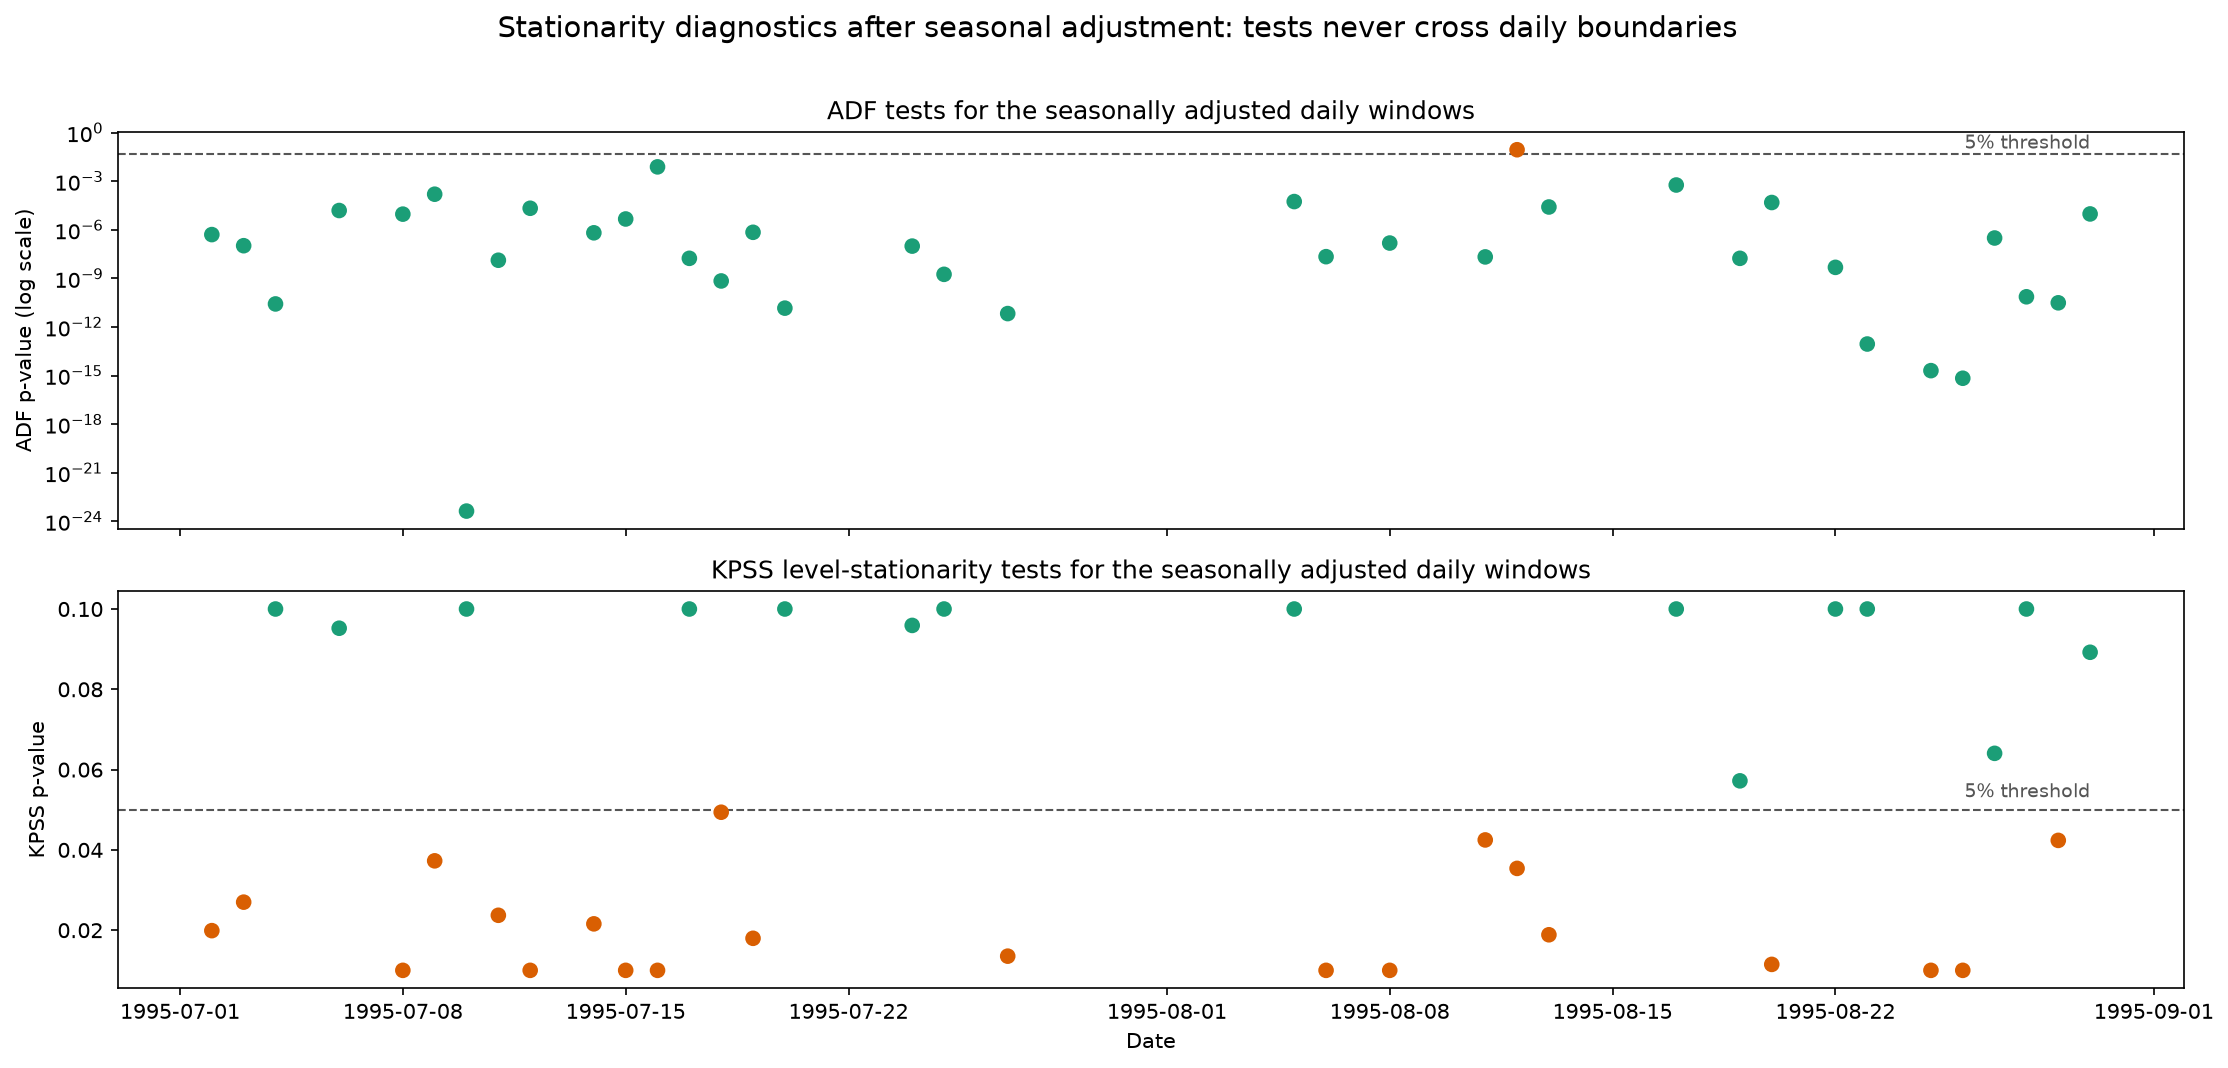

In [ ]:
adjusted_plot_dates = adjusted_stationarity_results["date"]
adjusted_adf_rejects = adjusted_stationarity_results["adf_pvalue"].lt(0.05)
adjusted_kpss_rejects = adjusted_stationarity_results["kpss_pvalue"].lt(0.05)

fig_adjusted_stationarity_pvalues, axes = plt.subplots(
    2,
    1,
    figsize=(15, 7),
    sharex=True,
)
axes[0].scatter(
    adjusted_plot_dates,
    adjusted_stationarity_results["adf_pvalue"],
    c=np.where(adjusted_adf_rejects, "#1b9e77", "#d95f02"),
    s=42,
    zorder=3,
)
axes[0].axhline(0.05, color="#555555", linestyle="--", linewidth=1)
axes[0].set_yscale("log")
axes[0].set(
    title="ADF tests for the seasonally adjusted daily windows",
    ylabel="ADF p-value (log scale)",
)
axes[0].text(
    adjusted_plot_dates.max(),
    0.055,
    "5% threshold",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)

axes[1].scatter(
    adjusted_plot_dates,
    adjusted_stationarity_results["kpss_pvalue"],
    c=np.where(adjusted_kpss_rejects, "#d95f02", "#1b9e77"),
    s=42,
    zorder=3,
)
axes[1].axhline(0.05, color="#555555", linestyle="--", linewidth=1)
axes[1].set(
    title=(
        "KPSS level-stationarity tests for the seasonally adjusted "
        "daily windows"
    ),
    xlabel="Date",
    ylabel="KPSS p-value",
)
axes[1].text(
    adjusted_plot_dates.max(),
    0.052,
    "5% threshold",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555555",
)

fig_adjusted_stationarity_pvalues.suptitle(
    "Stationarity diagnostics after seasonal adjustment: "
    "tests never cross daily boundaries",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()


### 5.9 Representative adjusted daily windows from each assessment

The adjusted classifications are visualized with the same reproducible rule used for the original counts. Three chronologically spaced dates are selected from each category containing many dates, while the sole adjusted date with evidence of nonstationarity is shown automatically. The categories are recalculated after seasonal adjustment, so these dates need not match the original representative sample.

Each panel shows all 481 integer-adjusted values $Z^{\mathrm{int}}_{d,m}$. The dashed line is that adjusted date's arithmetic mean,

$$
\overline{Z}^{\mathrm{int}}_d
=
\frac{1}{481}
\sum_{m=1}^{481}Z^{\mathrm{int}}_{d,m}.
$$

All panels share the same axes, and their titles show the ADF and KPSS $p$-values that generated the displayed assessment. As before, the plot supplements the tests: visible fluctuations alone do not prove nonstationarity, and a joint rejection does not identify a unique cause.


Representative adjusted daily windows by stationarity assessment
                                 assessment       date adjusted_mean  adjusted_minimum  adjusted_maximum ADF p-value KPSS p-value
          Changing mean / conflicting nulls 1995-07-02         18.87                 8                38      0.0000       0.0199
          Changing mean / conflicting nulls 1995-07-19         25.81                 7                44      0.0000       0.0180
          Changing mean / conflicting nulls 1995-08-29         23.23                11                48      0.0000       0.0424
Evidence consistent with level stationarity 1995-07-04         23.86                 2                42      0.0000       0.1000
Evidence consistent with level stationarity 1995-08-05          9.11                 0                18      0.0001       0.1000
Evidence consistent with level stationarity 1995-08-30         26.07                11                46      0.0000       0.0892
                Evidence 

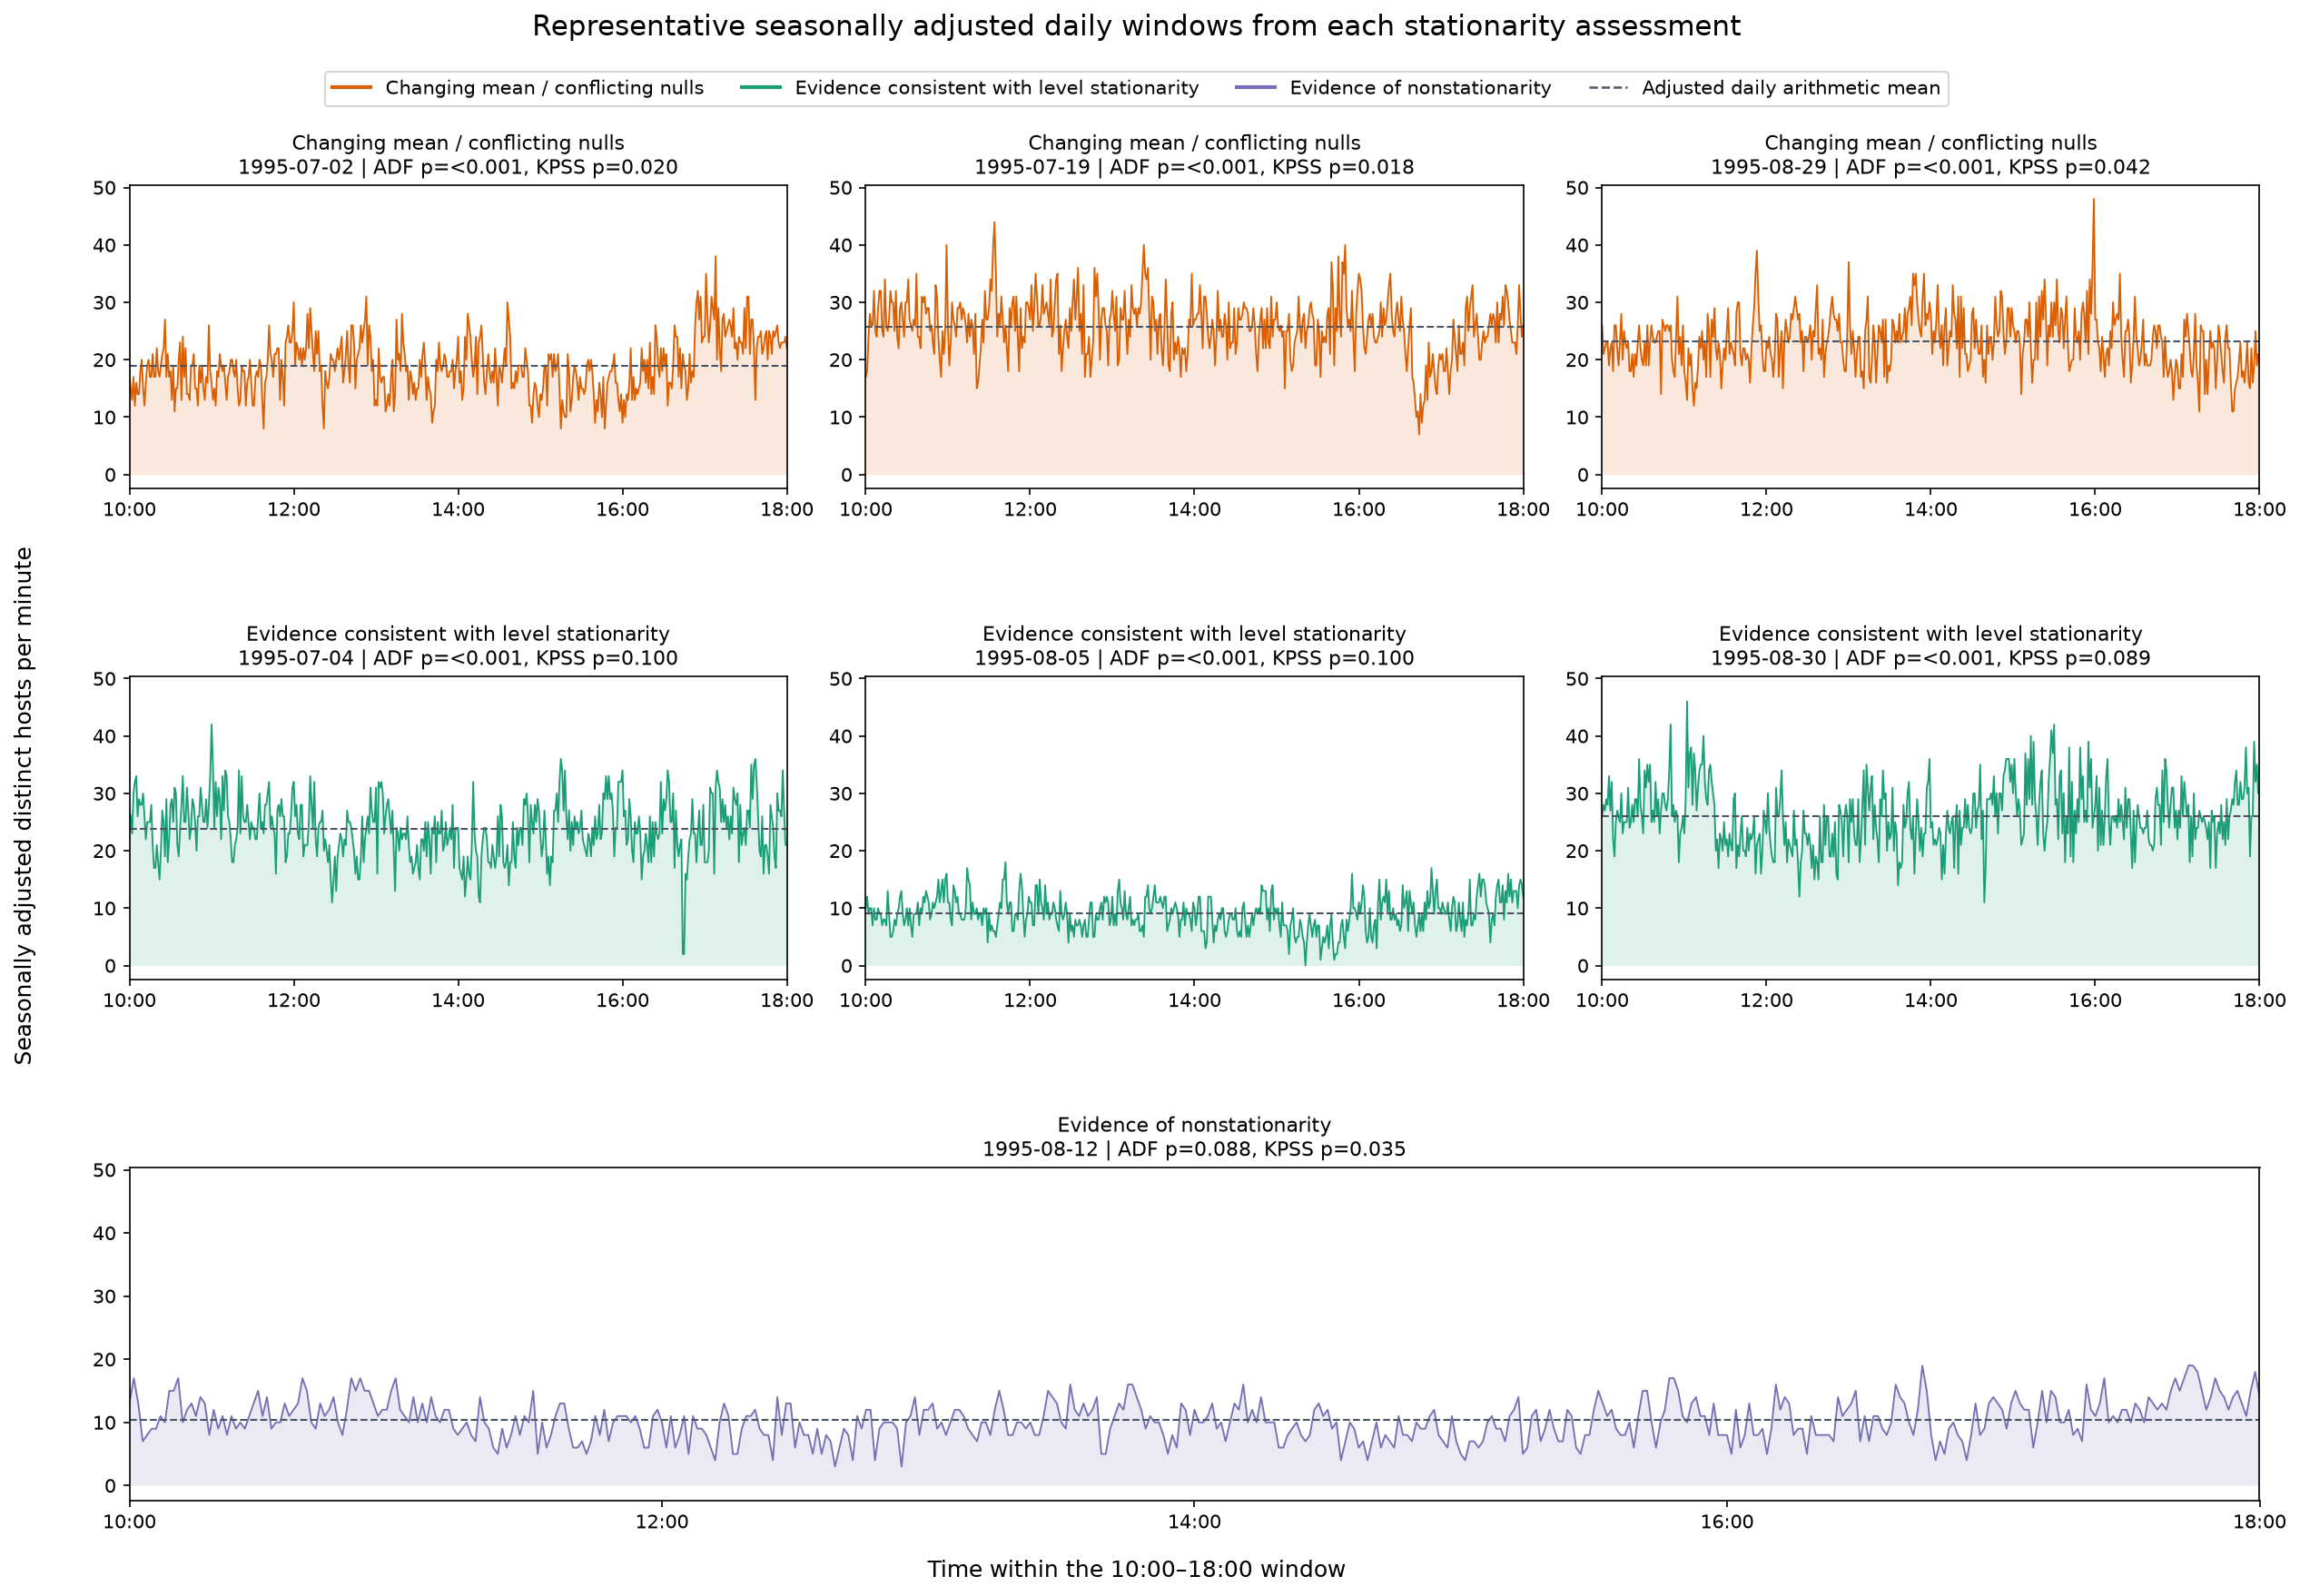

In [ ]:
from matplotlib.lines import Line2D


ADJUSTED_EXAMPLES_PER_LARGE_GROUP = 3
adjusted_assessment_plot_order = [
    "Changing mean / conflicting nulls",
    "Evidence consistent with level stationarity",
    "Evidence of nonstationarity",
]
adjusted_assessment_colors = {
    "Changing mean / conflicting nulls": "#d95f02",
    "Evidence consistent with level stationarity": "#1b9e77",
    "Evidence of nonstationarity": "#7570b3",
}


def select_adjusted_stationarity_examples(
    group: pd.DataFrame,
    number_of_examples: int,
) -> pd.DataFrame:
    """Select chronological positions without inspecting plotted values."""
    ordered_group = group.sort_values("date").reset_index(drop=True)
    if len(ordered_group) <= number_of_examples:
        return ordered_group
    positions = np.rint(
        np.linspace(0, len(ordered_group) - 1, number_of_examples)
    ).astype(int)
    return ordered_group.iloc[positions].reset_index(drop=True)


adjusted_representative_frames = []
for assessment in adjusted_assessment_plot_order:
    assessment_group = adjusted_stationarity_results.loc[
        adjusted_stationarity_results["assessment"].eq(assessment)
    ]
    requested_examples = (
        1
        if assessment == "Evidence of nonstationarity"
        else ADJUSTED_EXAMPLES_PER_LARGE_GROUP
    )
    selected_group = select_adjusted_stationarity_examples(
        assessment_group,
        requested_examples,
    ).copy()
    selected_group["assessment_order"] = (
        adjusted_assessment_plot_order.index(assessment)
    )
    adjusted_representative_frames.append(selected_group)

adjusted_representative_examples = (
    pd.concat(adjusted_representative_frames, ignore_index=True)
    .sort_values(["assessment_order", "date"])
    .reset_index(drop=True)
)

adjusted_panel_date_lookup = {
    pd.Timestamp(panel_date).normalize(): panel_date
    for panel_date in adjusted_distinct_host_panel.index
}
adjusted_representative_daily_series = []
adjusted_representative_summary_records = []

for example in adjusted_representative_examples.itertuples(index=False):
    normalized_date = pd.Timestamp(example.date).normalize()
    panel_date = adjusted_panel_date_lookup[normalized_date]
    daily_counts = adjusted_distinct_host_panel.loc[panel_date].to_numpy(
        dtype=float
    )
    if len(daily_counts) != minutes_per_paper_window:
        raise AssertionError(
            f"{normalized_date:%Y-%m-%d} does not contain exactly 481 values"
        )

    adjusted_representative_daily_series.append(
        {
            "assessment": example.assessment,
            "date": normalized_date,
            "values": daily_counts,
            "adf_pvalue": example.adf_pvalue,
            "kpss_pvalue": example.kpss_pvalue,
        }
    )
    adjusted_representative_summary_records.append(
        {
            "assessment": example.assessment,
            "date": normalized_date.strftime("%Y-%m-%d"),
            "adjusted_mean": daily_counts.mean(),
            "adjusted_minimum": int(daily_counts.min()),
            "adjusted_maximum": int(daily_counts.max()),
            "ADF p-value": example.adf_pvalue,
            "KPSS p-value": example.kpss_pvalue,
        }
    )

adjusted_representative_stationarity_summary = pd.DataFrame(
    adjusted_representative_summary_records
)
print("Representative adjusted daily windows by stationarity assessment")
print(
    adjusted_representative_stationarity_summary.to_string(
        index=False,
        formatters={
            "adjusted_mean": "{:.2f}".format,
            "ADF p-value": "{:.4f}".format,
            "KPSS p-value": "{:.4f}".format,
        },
    )
)


def adjusted_stationarity_pvalue_label(value: float) -> str:
    return "<0.001" if value < 0.001 else f"{value:.3f}"


fig_adjusted_stationarity_examples = plt.figure(figsize=(17, 12))
adjusted_grid = fig_adjusted_stationarity_examples.add_gridspec(
    3,
    3,
    height_ratios=[1, 1, 1.1],
)

adjusted_example_axes = []
for column in range(3):
    if not adjusted_example_axes:
        axis = fig_adjusted_stationarity_examples.add_subplot(
            adjusted_grid[0, column]
        )
    else:
        axis = fig_adjusted_stationarity_examples.add_subplot(
            adjusted_grid[0, column],
            sharex=adjusted_example_axes[0],
            sharey=adjusted_example_axes[0],
        )
    adjusted_example_axes.append(axis)

for column in range(3):
    adjusted_example_axes.append(
        fig_adjusted_stationarity_examples.add_subplot(
            adjusted_grid[1, column],
            sharex=adjusted_example_axes[0],
            sharey=adjusted_example_axes[0],
        )
    )

adjusted_example_axes.append(
    fig_adjusted_stationarity_examples.add_subplot(
        adjusted_grid[2, :],
        sharex=adjusted_example_axes[0],
        sharey=adjusted_example_axes[0],
    )
)

adjusted_stationarity_minute_number = np.arange(
    1,
    minutes_per_paper_window + 1,
)
adjusted_stationarity_clock_positions = [1, 121, 241, 361, 481]
adjusted_stationarity_clock_labels = [
    "10:00",
    "12:00",
    "14:00",
    "16:00",
    "18:00",
]

for axis, example in zip(
    adjusted_example_axes,
    adjusted_representative_daily_series,
):
    line_color = adjusted_assessment_colors[example["assessment"]]
    daily_values = example["values"]
    daily_mean = daily_values.mean()

    axis.plot(
        adjusted_stationarity_minute_number,
        daily_values,
        color=line_color,
        linewidth=0.9,
    )
    axis.fill_between(
        adjusted_stationarity_minute_number,
        daily_values,
        color=line_color,
        alpha=0.14,
        linewidth=0,
    )
    axis.axhline(
        daily_mean,
        color="#4b5563",
        linestyle="--",
        linewidth=1.0,
    )
    axis.set_title(
        f"{example['assessment']}\n"
        f"{example['date']:%Y-%m-%d} | "
        f"ADF p={adjusted_stationarity_pvalue_label(example['adf_pvalue'])}, "
        f"KPSS p={adjusted_stationarity_pvalue_label(example['kpss_pvalue'])}",
        fontsize=10.5,
    )
    axis.set_xlim(1, minutes_per_paper_window)
    axis.set_xticks(adjusted_stationarity_clock_positions)
    axis.set_xticklabels(adjusted_stationarity_clock_labels)

adjusted_legend_handles = [
    Line2D(
        [0],
        [0],
        color=adjusted_assessment_colors[assessment],
        linewidth=2,
        label=assessment,
    )
    for assessment in adjusted_assessment_plot_order
]
adjusted_legend_handles.append(
    Line2D(
        [0],
        [0],
        color="#4b5563",
        linestyle="--",
        linewidth=1.2,
        label="Adjusted daily arithmetic mean",
    )
)

fig_adjusted_stationarity_examples.suptitle(
    "Representative seasonally adjusted daily windows from each "
    "stationarity assessment",
    fontsize=15,
    y=0.985,
)
fig_adjusted_stationarity_examples.supxlabel(
    "Time within the 10:00–18:00 window",
    fontsize=12,
    y=0.025,
)
fig_adjusted_stationarity_examples.supylabel(
    "Seasonally adjusted distinct hosts per minute",
    fontsize=12,
    x=0.015,
)
fig_adjusted_stationarity_examples.legend(
    handles=adjusted_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=4,
    frameon=True,
)
fig_adjusted_stationarity_examples.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.075,
    top=0.88,
    hspace=0.60,
    wspace=0.12,
)
plt.show()


### 5.10 Interpretation after seasonal adjustment

At the 5% threshold, the ADF test rejects a unit root on 35 of the 36 adjusted dates, exactly as for the original counts. The KPSS test rejects constant-level stationarity on 21 adjusted dates, compared with 28 dates before adjustment. The joint classifications change as follows:

| Assessment | Original days | Adjusted days |
|---|---:|---:|
| Changing mean / conflicting nulls | 27 | 20 |
| Evidence consistent with level stationarity | 8 | 15 |
| Evidence of nonstationarity | 1 | 1 |
| Inconclusive | 0 | 0 |

The number of dates consistent with level stationarity rises from 8 to 15, while the double-rejection category falls from 27 to 20. This net improvement is consistent with the intended effect of the spline adjustment: removing the common time-of-day mean makes constant-level behavior more plausible for more daily windows.

The improvement is not uniform across dates. Eleven originally conflicting dates move to the level-stationary category, but four originally level-stationary dates move in the opposite direction. The sole original nonstationary date, 27 July, moves to the conflicting category, while 12 August becomes the sole adjusted date with direct evidence of nonstationarity. These changes are visible in the date-level transition table printed above.

Most importantly, seasonal adjustment does **not** establish stationarity for the full dataset. Twenty adjusted dates still reject both test nulls, and one rejects stationarity without rejecting a unit root. The spline removes only the smooth intraday pattern averaged across all 36 dates. Date-specific mean changes, changing variance, bursts, remaining serial structure, and the small effects of clipping and rounding can still affect the tests.

The adjusted integer series is therefore a useful exploratory count response, but the daily tests should remain diagnostics rather than a guarantee that a stationary INAR model is valid. For formal modeling, it is preferable to compare this adjusted-series approach with a count model that retains the original observations and includes the intraday spline or minute-of-window effect directly in its conditional mean.


## 6. Compare five daily marginal distributions before and after seasonal adjustment

A **marginal distribution** describes how often each count value occurs while temporarily ignoring the order of the observations. To avoid mixing dates with different traffic levels, this section constructs a separate empirical distribution for each of five complete daily windows. The complete procedure is first applied to the original `unique_hosts` counts and then repeated on the integer `unique_hosts_seasonally_adjusted` counts saved in subsection 4.5.

### 6.1 Reproducible selection of five dates

Only the 36 dates already verified to contain all 481 timestamps are eligible. Five dates are sampled without replacement using NumPy's pseudorandom generator with seed `2026`. Sorting the sampled dates affects only their display order. The fixed seed ensures that every execution selects the same dates:

$$
\text{1995-07-02},\ \text{1995-07-09},\ \text{1995-07-18},\ \text{1995-08-11},\ \text{1995-08-20}.
$$

The adjusted analysis reuses these exact dates. It does not draw a second sample. Before either comparison, the relevant saved CSV is checked for required columns, exactly 481 rows per date, no absent response values, and no duplicate `(date, minute_in_window)` pairs.

### 6.2 Empirical absolute frequencies

For selected date $d$, let $X_{d,m}$ denote either the original or integer-adjusted unique-host count at minute $m$, with $n=481$. For each nonnegative integer $k$, the empirical absolute frequency is

$$
O_{d,k}
=
\sum_{m=1}^{n}\mathbf{1}\{X_{d,m}=k\}.
$$

Thus, $O_{d,k}$ is the number of the day's 481 minutes containing exactly $k$ unique hosts. The histogram bars show counts of minutes, not percentages or probability densities.

### 6.3 Estimate and overlay a Poisson distribution

A Poisson random variable with parameter $\lambda_d>0$ has probability mass function

$$
P(Z_d=k)
=
e^{-\lambda_d}\frac{\lambda_d^k}{k!},
\qquad k=0,1,2,\ldots.
$$

For Poisson data, the mean and variance are both $\lambda_d$:

$$
\operatorname{E}(Z_d)=\operatorname{Var}(Z_d)=\lambda_d.
$$

The log-likelihood for one date is

$$
\ell_d(\lambda_d)
=
\sum_{m=1}^{n}
\left[
X_{d,m}\log\lambda_d-\lambda_d-\log(X_{d,m}!)
\right].
$$

Maximizing this expression gives the estimator

$$
\widehat{\lambda}_d
=
\overline{X}_d
=
\frac{1}{481}\sum_{m=1}^{481}X_{d,m}.
$$

The fitted absolute frequency at count $k$ is

$$
E_{d,k}
=
481\,P(Z_d=k\mid\widehat{\lambda}_d)
=
481e^{-\widehat{\lambda}_d}
\frac{\widehat{\lambda}_d^k}{k!}.
$$

The red points and line show $E_{d,k}$. The count support extends through the largest observed value and far enough to contain 99.99% of the fitted Poisson probability.

### 6.4 Dispersion as an additional descriptive check

For each date, the notebook reports the sample variance $S_d^2$ and the variance-to-mean ratio

$$
D_d=\frac{S_d^2}{\overline{X}_d}.
$$

A Poisson-like marginal has $D_d\approx1$. Values above 1 indicate overdispersion and values below 1 indicate underdispersion. Comparing $|D_d-1|$ before and after adjustment shows whether the variance-to-mean relationship moves closer to the Poisson benchmark. This ratio and the histograms are descriptive checks rather than formal goodness-of-fit tests.

The procedure follows the graphical comparison in Weiß (2008, Section 3, Figure 1(b)), adapted from one 481-minute series to five separate NASA dates. Observations from different dates are never pooled.

**Reference:** Weiß, C. H. (2008). “The combined INAR(p) models for time series of counts.” *Statistics & Probability Letters*, 78, 1817–1822, Section 3 and Figure 1(b). [https://doi.org/10.1016/j.spl.2008.01.036](https://doi.org/10.1016/j.spl.2008.01.036).


### 6.5 Results for the original unique-host counts

The first comparison uses the original `unique_hosts` response. The summary reports the estimated Poisson rate, sample variance, observed range, and dispersion ratio for every sampled date. The accompanying figure overlays the fitted Poisson absolute frequencies on the empirical daily histogram.


In [82]:
# Read exactly the complete-window CSV exported above.
saved_complete_minute_data = pd.read_csv(
    paper_window_csv,
    parse_dates=["minute", "date"],
)

required_columns = {"date", "minute_in_window", "unique_hosts"}
missing_columns = required_columns.difference(saved_complete_minute_data.columns)
if missing_columns:
    raise ValueError(
        "Saved complete-window data is missing columns: "
        + ", ".join(sorted(missing_columns))
    )

saved_complete_minute_data["date"] = saved_complete_minute_data[
    "date"
].dt.normalize()
saved_window_sizes = saved_complete_minute_data.groupby("date").size()
if not saved_window_sizes.eq(minutes_per_paper_window).all():
    raise ValueError("The saved CSV contains an incomplete 10:00-18:00 window.")
if saved_complete_minute_data["unique_hosts"].isna().any():
    raise ValueError("The saved CSV contains an absent unique-host count.")
if saved_complete_minute_data.duplicated(
    ["date", "minute_in_window"]
).any():
    raise ValueError("The saved CSV contains duplicate date-minute observations.")

RANDOM_DAY_SEED = 2026
NUMBER_OF_RANDOM_DAYS = 5
available_complete_days = pd.DatetimeIndex(
    sorted(saved_complete_minute_data["date"].unique())
)
if len(available_complete_days) < NUMBER_OF_RANDOM_DAYS:
    raise ValueError("Fewer than five complete daily windows are available.")

random_generator = np.random.default_rng(RANDOM_DAY_SEED)
selected_poisson_days = pd.DatetimeIndex(
    np.sort(
        random_generator.choice(
            available_complete_days.to_numpy(),
            size=NUMBER_OF_RANDOM_DAYS,
            replace=False,
        )
    )
)
selected_poisson_data = saved_complete_minute_data.loc[
    saved_complete_minute_data["date"].isin(selected_poisson_days),
    ["date", "minute_in_window", "unique_hosts"],
].copy()

selected_day_sizes = selected_poisson_data.groupby("date").size()
if not selected_day_sizes.eq(minutes_per_paper_window).all():
    raise AssertionError("A selected date does not contain exactly 481 minutes.")

daily_poisson_summary = (
    selected_poisson_data.groupby("date", sort=True)["unique_hosts"]
    .agg(
        observations="size",
        lambda_hat="mean",
        sample_variance="var",
        minimum="min",
        maximum="max",
    )
)
daily_poisson_summary["variance / mean"] = (
    daily_poisson_summary["sample_variance"]
    / daily_poisson_summary["lambda_hat"]
)

print(f"Random seed: {RANDOM_DAY_SEED}")
print("Selected dates:", ", ".join(selected_poisson_days.strftime("%Y-%m-%d")))
print(
    daily_poisson_summary.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)


Random seed: 2026
Selected dates: 1995-07-02, 1995-07-09, 1995-07-18, 1995-08-11, 1995-08-20
            observations  lambda_hat  sample_variance  minimum  maximum  variance / mean
date                                                                                    
1995-07-02           481      18.832           23.244        7       37            1.234
1995-07-09           481      10.609           12.630        2       23            1.191
1995-07-18           481      25.439           53.651        1       43            2.109
1995-08-11           481      20.025           25.224        6       35            1.260
1995-08-20           481       9.449            8.035        3       17            0.850


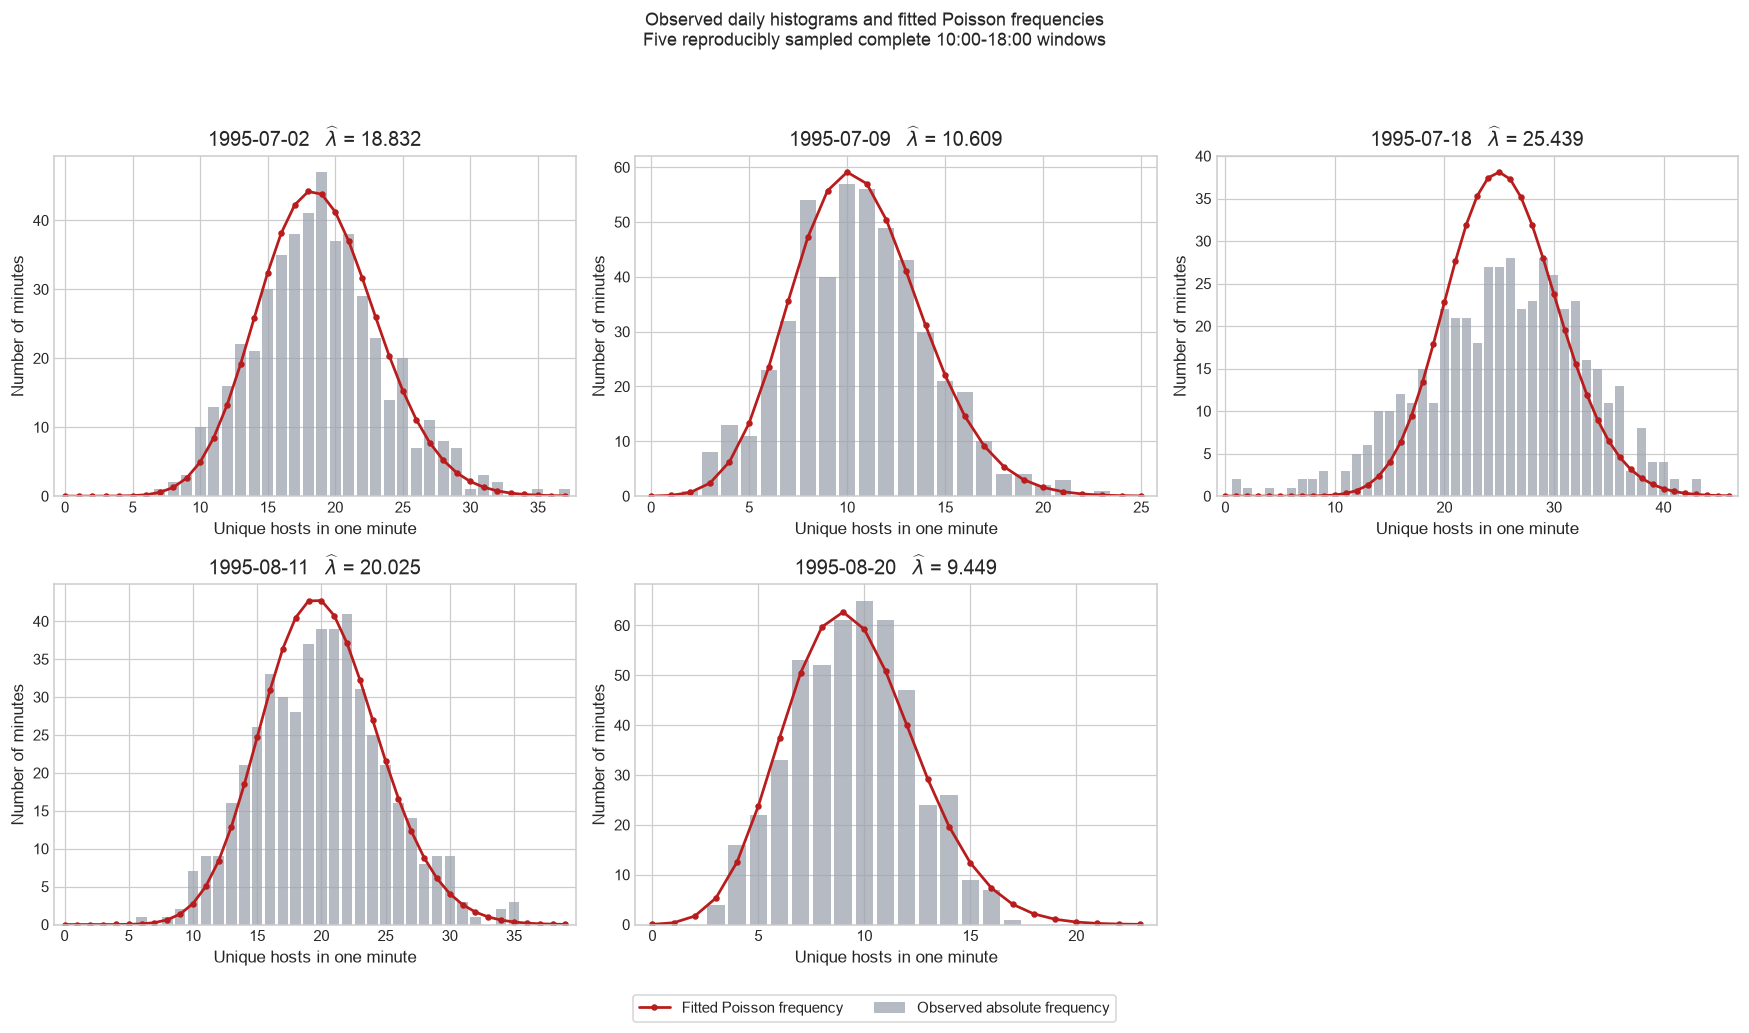

In [83]:
fig_daily_poisson, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9.5),
)
plot_axes = axes.ravel()

for axis, day in zip(plot_axes, selected_poisson_days):
    day_counts = selected_poisson_data.loc[
        selected_poisson_data["date"].eq(day),
        "unique_hosts",
    ].to_numpy(dtype=int)
    lambda_hat = day_counts.mean()

    # Include every observed value and virtually all fitted Poisson mass.
    poisson_upper = int(np.ceil(poisson.ppf(0.9999, mu=lambda_hat)))
    maximum_count = max(int(day_counts.max()), poisson_upper)
    count_support = np.arange(0, maximum_count + 1)

    observed_absolute_frequency = (
        pd.Series(day_counts)
        .value_counts()
        .reindex(count_support, fill_value=0)
        .sort_index()
    )
    poisson_expected_frequency = (
        len(day_counts) * poisson.pmf(count_support, mu=lambda_hat)
    )

    axis.bar(
        count_support,
        observed_absolute_frequency,
        width=0.82,
        color="#9CA3AF",
        alpha=0.75,
        label="Observed absolute frequency",
    )
    axis.plot(
        count_support,
        poisson_expected_frequency,
        color="#B91C1C",
        marker="o",
        markersize=3.2,
        linewidth=1.8,
        label="Fitted Poisson frequency",
    )
    axis.set(
        title=f"{day:%Y-%m-%d}   $\\widehat{{\\lambda}}$ = {lambda_hat:.3f}",
        xlabel="Unique hosts in one minute",
        ylabel="Number of minutes",
        xlim=(-0.8, maximum_count + 0.8),
        ylim=(0, None),
    )

# The sixth panel is unnecessary because exactly five dates were requested.
fig_daily_poisson.delaxes(plot_axes[-1])

handles, labels = plot_axes[0].get_legend_handles_labels()
fig_daily_poisson.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)
fig_daily_poisson.suptitle(
    "Observed daily histograms and fitted Poisson frequencies\n"
    "Five reproducibly sampled complete 10:00-18:00 windows",
    y=0.99,
)
plt.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()


### 6.6 Interpretation of the original Poisson comparisons

The five estimated means and dispersion summaries are:

| Date | $\widehat{\lambda}_d$ | Sample variance $S_d^2$ | $D_d=S_d^2/\overline{X}_d$ |
|---|---:|---:|---:|
| 1995-07-02 | 18.832 | 23.244 | 1.234 |
| 1995-07-09 | 10.609 | 12.630 | 1.191 |
| 1995-07-18 | 25.439 | 53.651 | 2.109 |
| 1995-08-11 | 20.025 | 25.224 | 1.260 |
| 1995-08-20 | 9.449 | 8.035 | 0.850 |

The fitted curve uses only one estimated parameter—the daily arithmetic mean. The comparisons show that the five dates do not share exactly the same marginal behavior:

- 2 July, 9 July, and 11 August are moderately overdispersed relative to Poisson;
- 20 August is slightly underdispersed; and
- 18 July is strongly overdispersed, with a sample variance more than twice its mean and the clearest disagreement between observed and fitted frequencies.

The intraday mean pattern helps explain why a single Poisson distribution may be too narrow. If minute $m$ were conditionally Poisson with a changing mean $\lambda_{d,m}$, the marginal variance across the day would satisfy the variance decomposition

$$
\operatorname{Var}(X_{d,m})
=
\operatorname{E}(\lambda_{d,m})
+
\operatorname{Var}(\lambda_{d,m}),
$$

which exceeds the marginal mean whenever $\lambda_{d,m}$ varies across minutes. Serial dependence can also change histogram uncertainty. Consequently, the figure answers only whether a Poisson shape is visually plausible for each raw daily marginal distribution; it does not establish an independent, identically distributed Poisson data-generating process.

A conventional independent-observation goodness-of-fit test would be misleading here because the counts have both time-varying means and serial dependence. Subsections 6.7 and 6.8 repeat the graphical and dispersion checks on the saved adjusted counts before section 7 examines within-day dependence.


### 6.7 Results for the seasonally adjusted integer counts

The following cells repeat the same procedure on `unique_hosts_seasonally_adjusted` from `data/NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv`. The same five dates and all 481 adjusted values per date are used. For each date, the adjusted Poisson estimator is

$$
\widehat{\lambda}^{\mathrm{adj}}_d
=
\frac{1}{481}
\sum_{m=1}^{481}Z^{\mathrm{int}}_{d,m}.
$$

Because the centered continuous seasonal correction sums to zero across the 481 minute positions, it preserves each complete date's mean before clipping and rounding. Any small difference between the original and adjusted fitted rates therefore comes from those final nonnegativity and integerization operations.


In [ ]:
# Read the seasonally adjusted CSV saved in subsection 4.5.
adjusted_poisson_csv = (
    DATA_DIR / "NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv"
)
saved_adjusted_minute_data = pd.read_csv(
    adjusted_poisson_csv,
    parse_dates=["minute", "date"],
)

adjusted_required_columns = {
    "date",
    "minute_in_window",
    "unique_hosts_seasonally_adjusted",
}
adjusted_missing_columns = adjusted_required_columns.difference(
    saved_adjusted_minute_data.columns
)
if adjusted_missing_columns:
    raise ValueError(
        "Saved adjusted data is missing columns: "
        + ", ".join(sorted(adjusted_missing_columns))
    )

saved_adjusted_minute_data["date"] = saved_adjusted_minute_data[
    "date"
].dt.normalize()
adjusted_saved_window_sizes = saved_adjusted_minute_data.groupby("date").size()
if not adjusted_saved_window_sizes.eq(minutes_per_paper_window).all():
    raise ValueError(
        "The adjusted CSV contains an incomplete 10:00-18:00 window."
    )
if saved_adjusted_minute_data[
    "unique_hosts_seasonally_adjusted"
].isna().any():
    raise ValueError("The adjusted CSV contains an absent host count.")
if saved_adjusted_minute_data.duplicated(
    ["date", "minute_in_window"]
).any():
    raise ValueError(
        "The adjusted CSV contains duplicate date-minute observations."
    )

adjusted_host_values = saved_adjusted_minute_data[
    "unique_hosts_seasonally_adjusted"
].to_numpy(dtype=float)
if (adjusted_host_values < 0).any() or not np.equal(
    adjusted_host_values,
    np.rint(adjusted_host_values),
).all():
    raise ValueError(
        "The adjusted response must contain nonnegative integer counts."
    )

adjusted_available_days = pd.DatetimeIndex(
    sorted(saved_adjusted_minute_data["date"].unique())
)
if not adjusted_available_days.equals(available_complete_days):
    raise AssertionError(
        "The original and adjusted CSV files do not contain the same dates."
    )

selected_adjusted_poisson_data = saved_adjusted_minute_data.loc[
    saved_adjusted_minute_data["date"].isin(selected_poisson_days),
    [
        "date",
        "minute_in_window",
        "unique_hosts_seasonally_adjusted",
    ],
].copy()

selected_adjusted_day_sizes = selected_adjusted_poisson_data.groupby(
    "date"
).size()
if not selected_adjusted_day_sizes.eq(minutes_per_paper_window).all():
    raise AssertionError(
        "A selected adjusted date does not contain exactly 481 minutes."
    )

adjusted_daily_poisson_summary = (
    selected_adjusted_poisson_data.groupby(
        "date",
        sort=True,
    )["unique_hosts_seasonally_adjusted"]
    .agg(
        observations="size",
        lambda_hat="mean",
        sample_variance="var",
        minimum="min",
        maximum="max",
    )
)
adjusted_daily_poisson_summary["variance / mean"] = (
    adjusted_daily_poisson_summary["sample_variance"]
    / adjusted_daily_poisson_summary["lambda_hat"]
)

poisson_before_after_comparison = pd.DataFrame(
    {
        "original lambda": daily_poisson_summary["lambda_hat"],
        "adjusted lambda": adjusted_daily_poisson_summary["lambda_hat"],
        "original dispersion": daily_poisson_summary["variance / mean"],
        "adjusted dispersion": (
            adjusted_daily_poisson_summary["variance / mean"]
        ),
    }
)
poisson_before_after_comparison["change in |dispersion - 1|"] = (
    (poisson_before_after_comparison["adjusted dispersion"] - 1).abs()
    - (poisson_before_after_comparison["original dispersion"] - 1).abs()
)

print("Same selected dates as the original Poisson comparison")
print(", ".join(selected_poisson_days.strftime("%Y-%m-%d")))
print("\nSeasonally adjusted daily Poisson summaries")
print(
    adjusted_daily_poisson_summary.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)
print("\nOriginal versus adjusted comparison")
print(
    poisson_before_after_comparison.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)


Same selected dates as the original Poisson comparison
1995-07-02, 1995-07-09, 1995-07-18, 1995-08-11, 1995-08-20

Seasonally adjusted daily Poisson summaries
            observations  lambda_hat  sample_variance  minimum  maximum  variance / mean
date                                                                                    
1995-07-02           481      18.867           23.620        8       38            1.252
1995-07-09           481      10.644           12.525        1       22            1.177
1995-07-18           481      25.474           41.587        2       41            1.633
1995-08-11           481      20.060           22.128        7       35            1.103
1995-08-20           481       9.484            9.988        1       18            1.053

Original versus adjusted comparison
            original lambda  adjusted lambda  original dispersion  adjusted dispersion  change in |dispersion - 1|
date                                                              

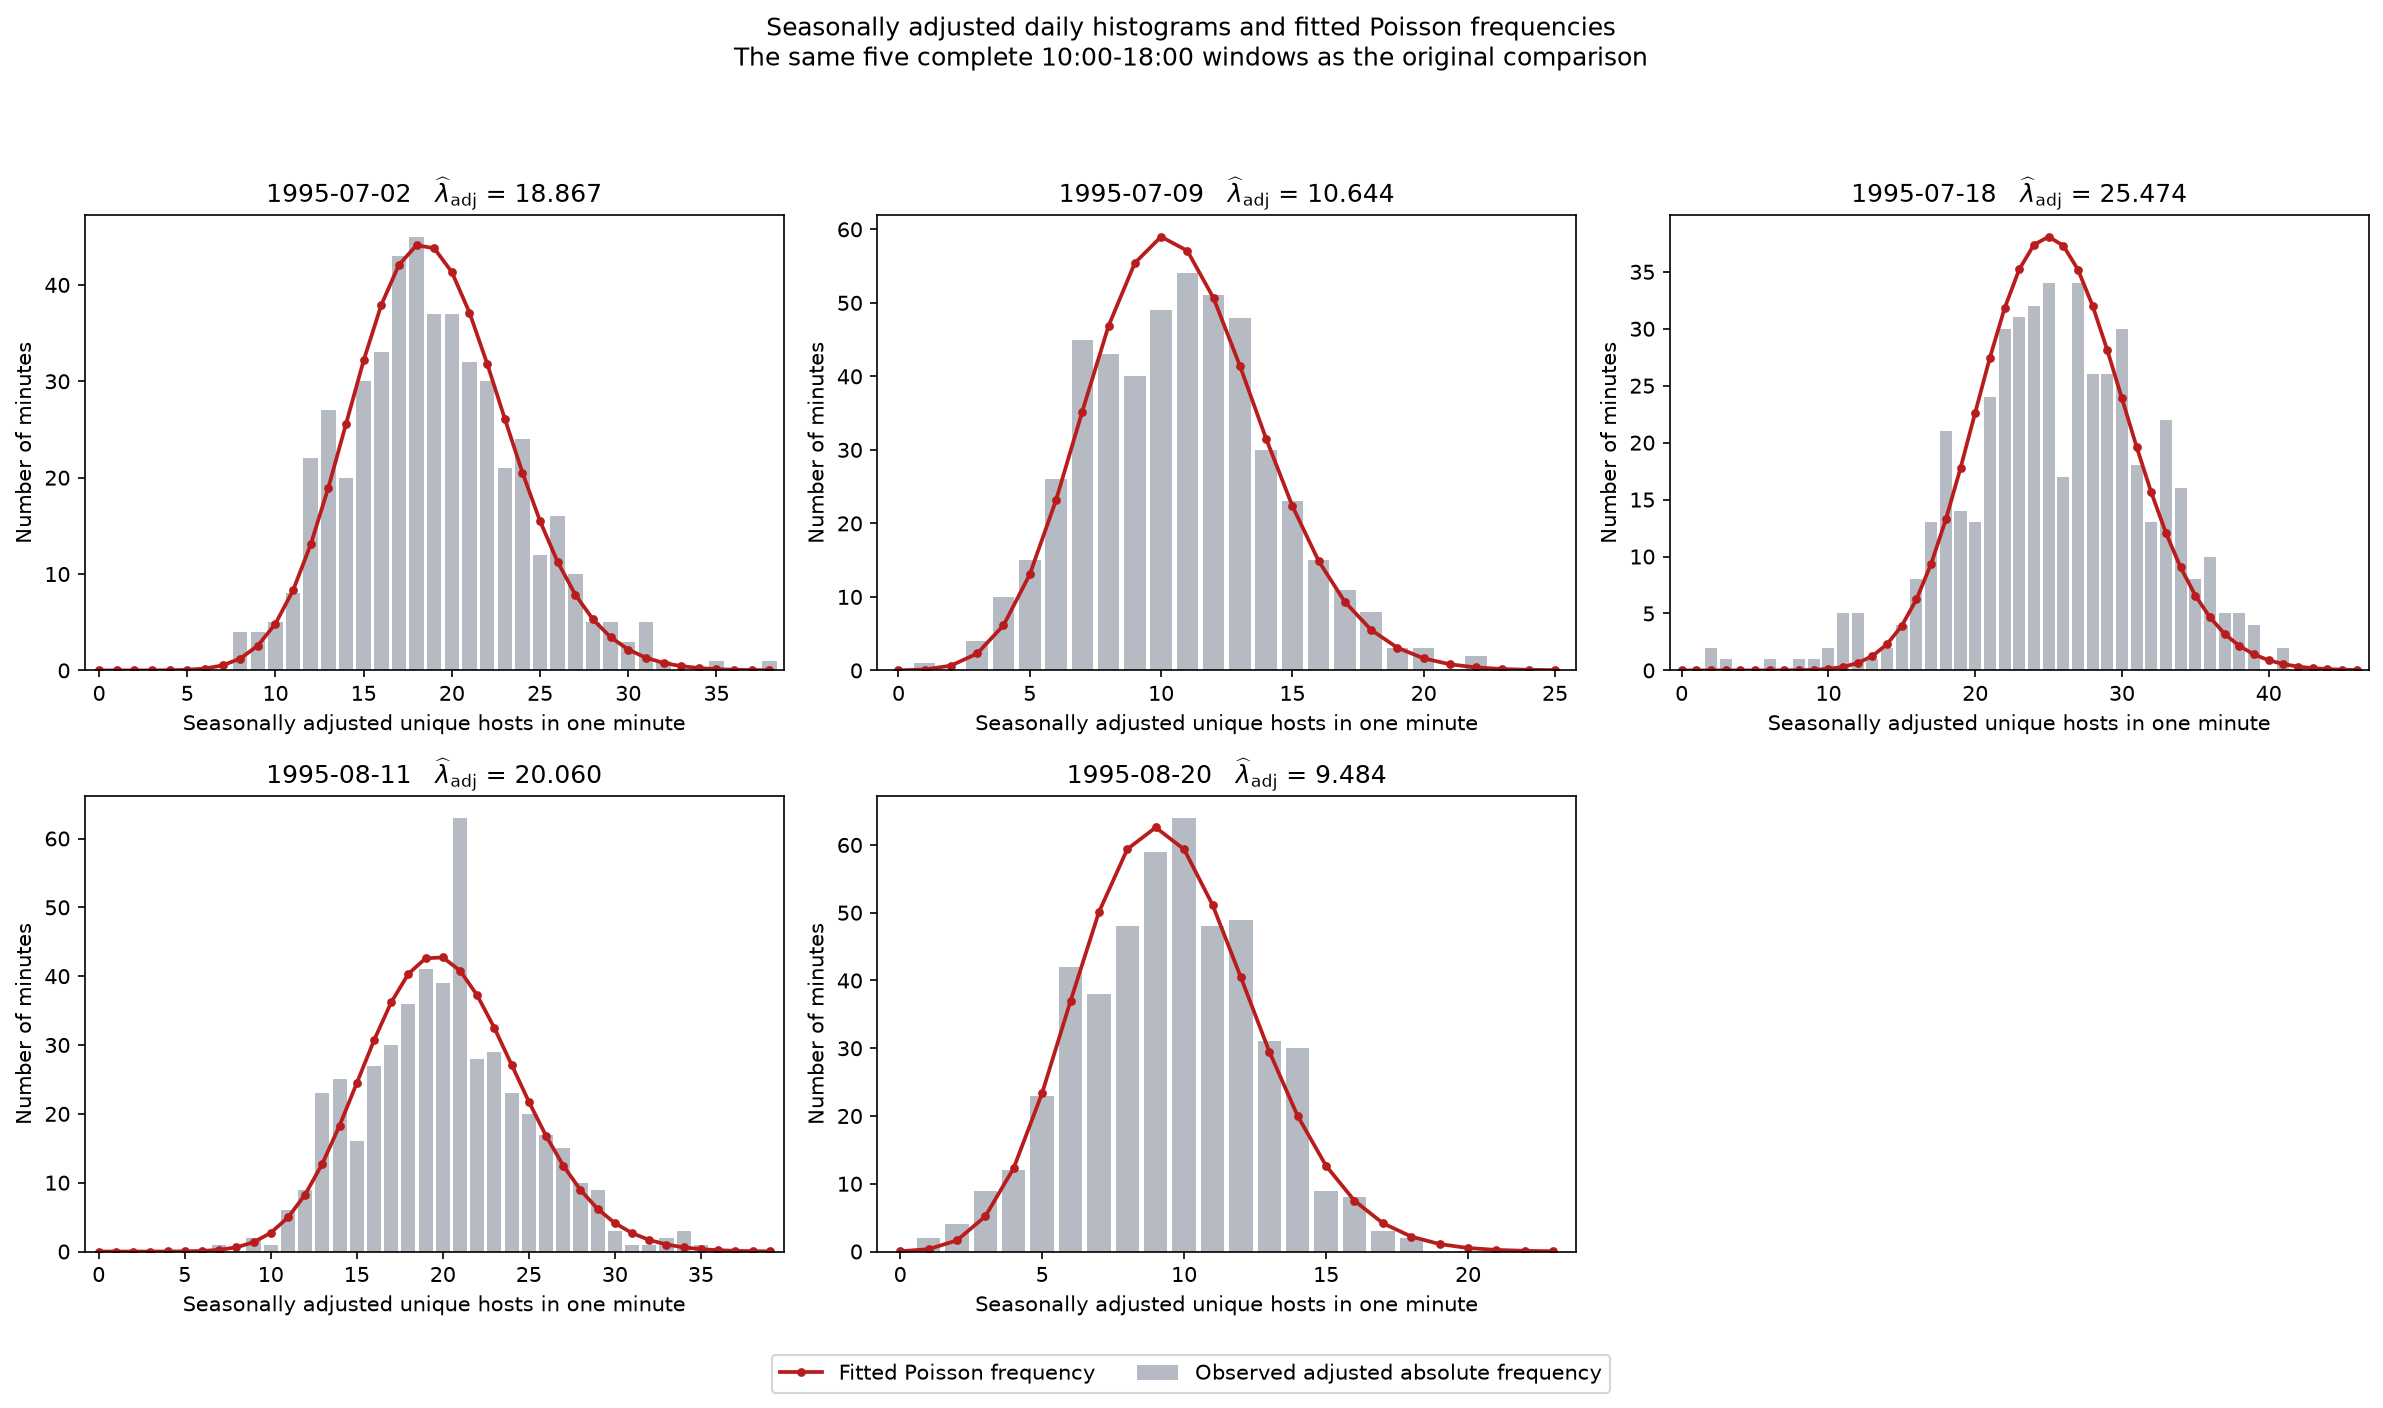

In [ ]:
fig_adjusted_daily_poisson, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9.5),
)
adjusted_plot_axes = axes.ravel()

for axis, day in zip(adjusted_plot_axes, selected_poisson_days):
    adjusted_day_counts = selected_adjusted_poisson_data.loc[
        selected_adjusted_poisson_data["date"].eq(day),
        "unique_hosts_seasonally_adjusted",
    ].to_numpy(dtype=int)
    adjusted_lambda_hat = adjusted_day_counts.mean()

    # Include every observed value and virtually all fitted Poisson mass.
    adjusted_poisson_upper = int(
        np.ceil(poisson.ppf(0.9999, mu=adjusted_lambda_hat))
    )
    adjusted_maximum_count = max(
        int(adjusted_day_counts.max()),
        adjusted_poisson_upper,
    )
    adjusted_count_support = np.arange(0, adjusted_maximum_count + 1)

    adjusted_observed_absolute_frequency = (
        pd.Series(adjusted_day_counts)
        .value_counts()
        .reindex(adjusted_count_support, fill_value=0)
        .sort_index()
    )
    adjusted_poisson_expected_frequency = (
        len(adjusted_day_counts)
        * poisson.pmf(
            adjusted_count_support,
            mu=adjusted_lambda_hat,
        )
    )

    axis.bar(
        adjusted_count_support,
        adjusted_observed_absolute_frequency,
        width=0.82,
        color="#9CA3AF",
        alpha=0.75,
        label="Observed adjusted absolute frequency",
    )
    axis.plot(
        adjusted_count_support,
        adjusted_poisson_expected_frequency,
        color="#B91C1C",
        marker="o",
        markersize=3.2,
        linewidth=1.8,
        label="Fitted Poisson frequency",
    )
    axis.set(
        title=(
            f"{day:%Y-%m-%d}   "
            f"$\\widehat{{\\lambda}}_{{\\mathrm{{adj}}}}$ = "
            f"{adjusted_lambda_hat:.3f}"
        ),
        xlabel="Seasonally adjusted unique hosts in one minute",
        ylabel="Number of minutes",
        xlim=(-0.8, adjusted_maximum_count + 0.8),
        ylim=(0, None),
    )

# The sixth panel is unnecessary because exactly five dates were requested.
fig_adjusted_daily_poisson.delaxes(adjusted_plot_axes[-1])

adjusted_handles, adjusted_labels = (
    adjusted_plot_axes[0].get_legend_handles_labels()
)
fig_adjusted_daily_poisson.legend(
    adjusted_handles,
    adjusted_labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.015),
)
fig_adjusted_daily_poisson.suptitle(
    "Seasonally adjusted daily histograms and fitted Poisson frequencies\n"
    "The same five complete 10:00-18:00 windows as the original comparison",
    y=0.99,
)
plt.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()


### 6.8 Interpretation after seasonal adjustment

The adjusted fitted rates and dispersion summaries are:

| Date | $\widehat{\lambda}^{\mathrm{adj}}_d$ | Adjusted variance | Adjusted $D_d$ |
|---|---:|---:|---:|
| 1995-07-02 | 18.867 | 23.620 | 1.252 |
| 1995-07-09 | 10.644 | 12.525 | 1.177 |
| 1995-07-18 | 25.474 | 41.587 | 1.633 |
| 1995-08-11 | 20.060 | 22.128 | 1.103 |
| 1995-08-20 | 9.484 | 9.988 | 1.053 |

The estimated adjusted rates are only about 0.035 hosts above the original daily means. The continuous centered correction preserves each complete date's mean exactly; clipping and integer rounding create this small difference.

Seasonal removal makes the dispersion ratio closer to the Poisson benchmark $D_d=1$ on four of the five sampled dates:

- 18 July remains overdispersed, but its ratio falls substantially from 2.109 to 1.633;
- 11 August moves from 1.260 to 1.103 and becomes much closer to equidispersion;
- 20 August moves from mild underdispersion at 0.850 to a near-Poisson value of 1.053;
- 9 July improves slightly from 1.191 to 1.177; and
- 2 July becomes slightly farther from 1, changing from 1.234 to 1.252.

In the printed comparison, a negative value of `change in |dispersion - 1|` means that adjustment moves the ratio closer to the Poisson target. The adjusted histograms provide stronger variance-based support for a Poisson marginal on several dates, especially 20 August. They do not make Poisson adequate for every date. The 18 July histogram remains wider than its fitted Poisson curve, while 11 August retains a pronounced excess frequency at one count value despite its near-one dispersion ratio. The other panels also contain local discrepancies between observed and expected frequencies.

This comparison explains one source of the original overdispersion. Mixing minute positions with different expected levels adds between-minute variation to the marginal variance. Removing the common intraday mean reduces that contribution, but it does not remove date-specific changes, bursts, changing variance, or serial dependence. A good visual match also does not establish independent Poisson observations. Section 7 compares within-day serial dependence for the original and seasonally adjusted sampled series.


## 7. Measure within-day dependence before and after seasonal adjustment

The histograms in section 6 discard temporal order. The autocorrelation function (ACF) and partial autocorrelation function (PACF) restore that order and describe how counts separated by several minutes are related. This section applies the same calculations first to the original `unique_hosts` counts and then to the integer `unique_hosts_seasonally_adjusted` counts. Both analyses reuse the same five sampled dates, and every date is processed independently.

In the definitions below, $X_{d,m}$ denotes whichever of the two count series is being analyzed.

### 7.1 Empirical autocorrelation function

For one selected date $d$, write $n=481$ and let

$$
\overline{X}_d=\frac{1}{n}\sum_{m=1}^{n}X_{d,m}.
$$

The empirical ACF at lag $k$ is

$$
\widehat{\rho}_d(k)
=
\frac{
\sum_{m=k+1}^{n}
(X_{d,m}-\overline{X}_d)
(X_{d,m-k}-\overline{X}_d)
}{
\sum_{m=1}^{n}(X_{d,m}-\overline{X}_d)^2
}.
$$

A positive value means that an above-average count tends to be paired with another above-average count $k$ minutes later. The ACF includes both direct dependence at lag $k$ and indirect dependence transmitted through intermediate lags.

### 7.2 Partial autocorrelation function

The PACF at lag $k$ measures the remaining linear association between observations $k$ minutes apart after accounting for lags $1,\ldots,k-1$. Equivalently, consider the order-$k$ linear projection

$$
X_{d,m}
=
c_k+\phi_{k,1}X_{d,m-1}
+\cdots+
\phi_{k,k}X_{d,m-k}
+\varepsilon_{d,m}.
$$

The lag-$k$ PACF is the last coefficient,

$$
\widehat{\alpha}_d(k)=\widehat{\phi}_{k,k}.
$$

The code uses the Yule–Walker maximum-likelihood method. For each order $k$, it forms the Toeplitz autocorrelation matrix $\widehat{R}_k$ and solves

$$
\widehat{R}_k\widehat{\boldsymbol{\phi}}_k
=
\widehat{\boldsymbol{r}}_k,
$$

where $\widehat{\boldsymbol{r}}_k=(\widehat{\rho}(1),\ldots,\widehat{\rho}(k))^{\mathsf{T}}$. The final element of $\widehat{\boldsymbol{\phi}}_k$ is plotted as the PACF at lag $k$.

### 7.3 Lag range and reference band

The notebook computes lags $k=1,\ldots,60$, covering dependence up to one hour. For every date and dataset, the 481 observations are sorted by `minute_in_window` before the correlations are calculated. A pair at lag $k$ always comes from the same date, so an 18:00 value is never paired with a 10:00 value from another date.

Under an ideal independent white-noise approximation, a sample autocorrelation is approximately distributed as

$$
\widehat{\rho}(k)\approx N\!\left(0,\frac{1}{n}\right).
$$

This yields the pointwise 95% reference limits

$$
\pm\frac{1.96}{\sqrt{481}}\approx\pm0.089.
$$

The shaded band marks these limits, and values outside it are highlighted. It is a visual reference rather than a simultaneous 60-lag hypothesis test. Because many correlations are displayed, isolated crossings can occur by chance. These bounds also assume white noise and should not be interpreted as formal model-selection thresholds for non-Gaussian dependent counts.

The figures improve readability relative to the compact presentation in Weiß (2008, Figure 1(c)–(d)) by using a common scale, aligned ACF/PACF panels, a full one-hour horizon, shaded reference bands, and separate rows for the five dates.

**Reference:** Weiß, C. H. (2008). “The combined INAR(p) models for time series of counts.” *Statistics & Probability Letters*, 78, 1817–1822, Figure 1(c)–(d). [https://doi.org/10.1016/j.spl.2008.01.036](https://doi.org/10.1016/j.spl.2008.01.036).


### 7.4 Results for the original unique-host counts

The first calculation uses the original `unique_hosts` values from the five dates selected in section 6. The summary reports ACF values at lags 1, 5, and 15, counts the ACF and PACF values outside the pointwise reference band through lag 60, and lists the highlighted PACF lags among the first ten minutes.


In [84]:
from statsmodels.tsa.stattools import acf as empirical_acf
from statsmodels.tsa.stattools import pacf as empirical_pacf

MAX_DAILY_LAG = 60
WHITE_NOISE_95_BOUND = 1.96 / np.sqrt(minutes_per_paper_window)

daily_dependence_estimates = {}
dependence_summary_records = []

for day in selected_poisson_days:
    day_series = (
        selected_poisson_data.loc[
            selected_poisson_data["date"].eq(day),
            ["minute_in_window", "unique_hosts"],
        ]
        .sort_values("minute_in_window")["unique_hosts"]
        .to_numpy(dtype=float)
    )
    if len(day_series) != minutes_per_paper_window:
        raise AssertionError(
            f"{day:%Y-%m-%d} does not contain exactly 481 observations."
        )

    acf_values = empirical_acf(
        day_series,
        nlags=MAX_DAILY_LAG,
        fft=True,
    )
    pacf_values = empirical_pacf(
        day_series,
        nlags=MAX_DAILY_LAG,
        method="ywmle",
    )
    daily_dependence_estimates[pd.Timestamp(day)] = {
        "acf": acf_values,
        "pacf": pacf_values,
    }

    significant_acf_lags = (
        np.flatnonzero(
            np.abs(acf_values[1:]) > WHITE_NOISE_95_BOUND
        )
        + 1
    )
    significant_pacf_lags = (
        np.flatnonzero(
            np.abs(pacf_values[1:]) > WHITE_NOISE_95_BOUND
        )
        + 1
    )
    short_significant_pacf_lags = significant_pacf_lags[
        significant_pacf_lags <= 10
    ]

    dependence_summary_records.append(
        {
            "date": pd.Timestamp(day),
            "ACF(1)": acf_values[1],
            "ACF(5)": acf_values[5],
            "ACF(15)": acf_values[15],
            "significant ACF lags 1-60": len(significant_acf_lags),
            "significant PACF lags 1-60": len(significant_pacf_lags),
            "significant PACF lags 1-10": (
                ", ".join(map(str, short_significant_pacf_lags))
                if len(short_significant_pacf_lags)
                else "none"
            ),
        }
    )

daily_dependence_summary = (
    pd.DataFrame(dependence_summary_records)
    .set_index("date")
    .sort_index()
)

print(f"Approximate 95% white-noise bound: ±{WHITE_NOISE_95_BOUND:.3f}")
print("Every ACF and PACF is calculated within one 481-minute day.")
print(
    daily_dependence_summary.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)


Approximate 95% white-noise bound: ±0.089
Every ACF and PACF is calculated within one 481-minute day.
            ACF(1)  ACF(5)  ACF(15)  significant ACF lags 1-60  significant PACF lags 1-60 significant PACF lags 1-10
date                                                                                                                 
1995-07-02   0.560   0.287    0.245                         50                           5                    1, 2, 4
1995-07-09   0.546   0.332    0.221                         30                           6              1, 2, 4, 5, 7
1995-07-18   0.642   0.370    0.287                         57                           7                    1, 2, 3
1995-08-11   0.501   0.195    0.120                         36                           7                    1, 2, 6
1995-08-20   0.429   0.071   -0.015                          7                           5                       1, 7


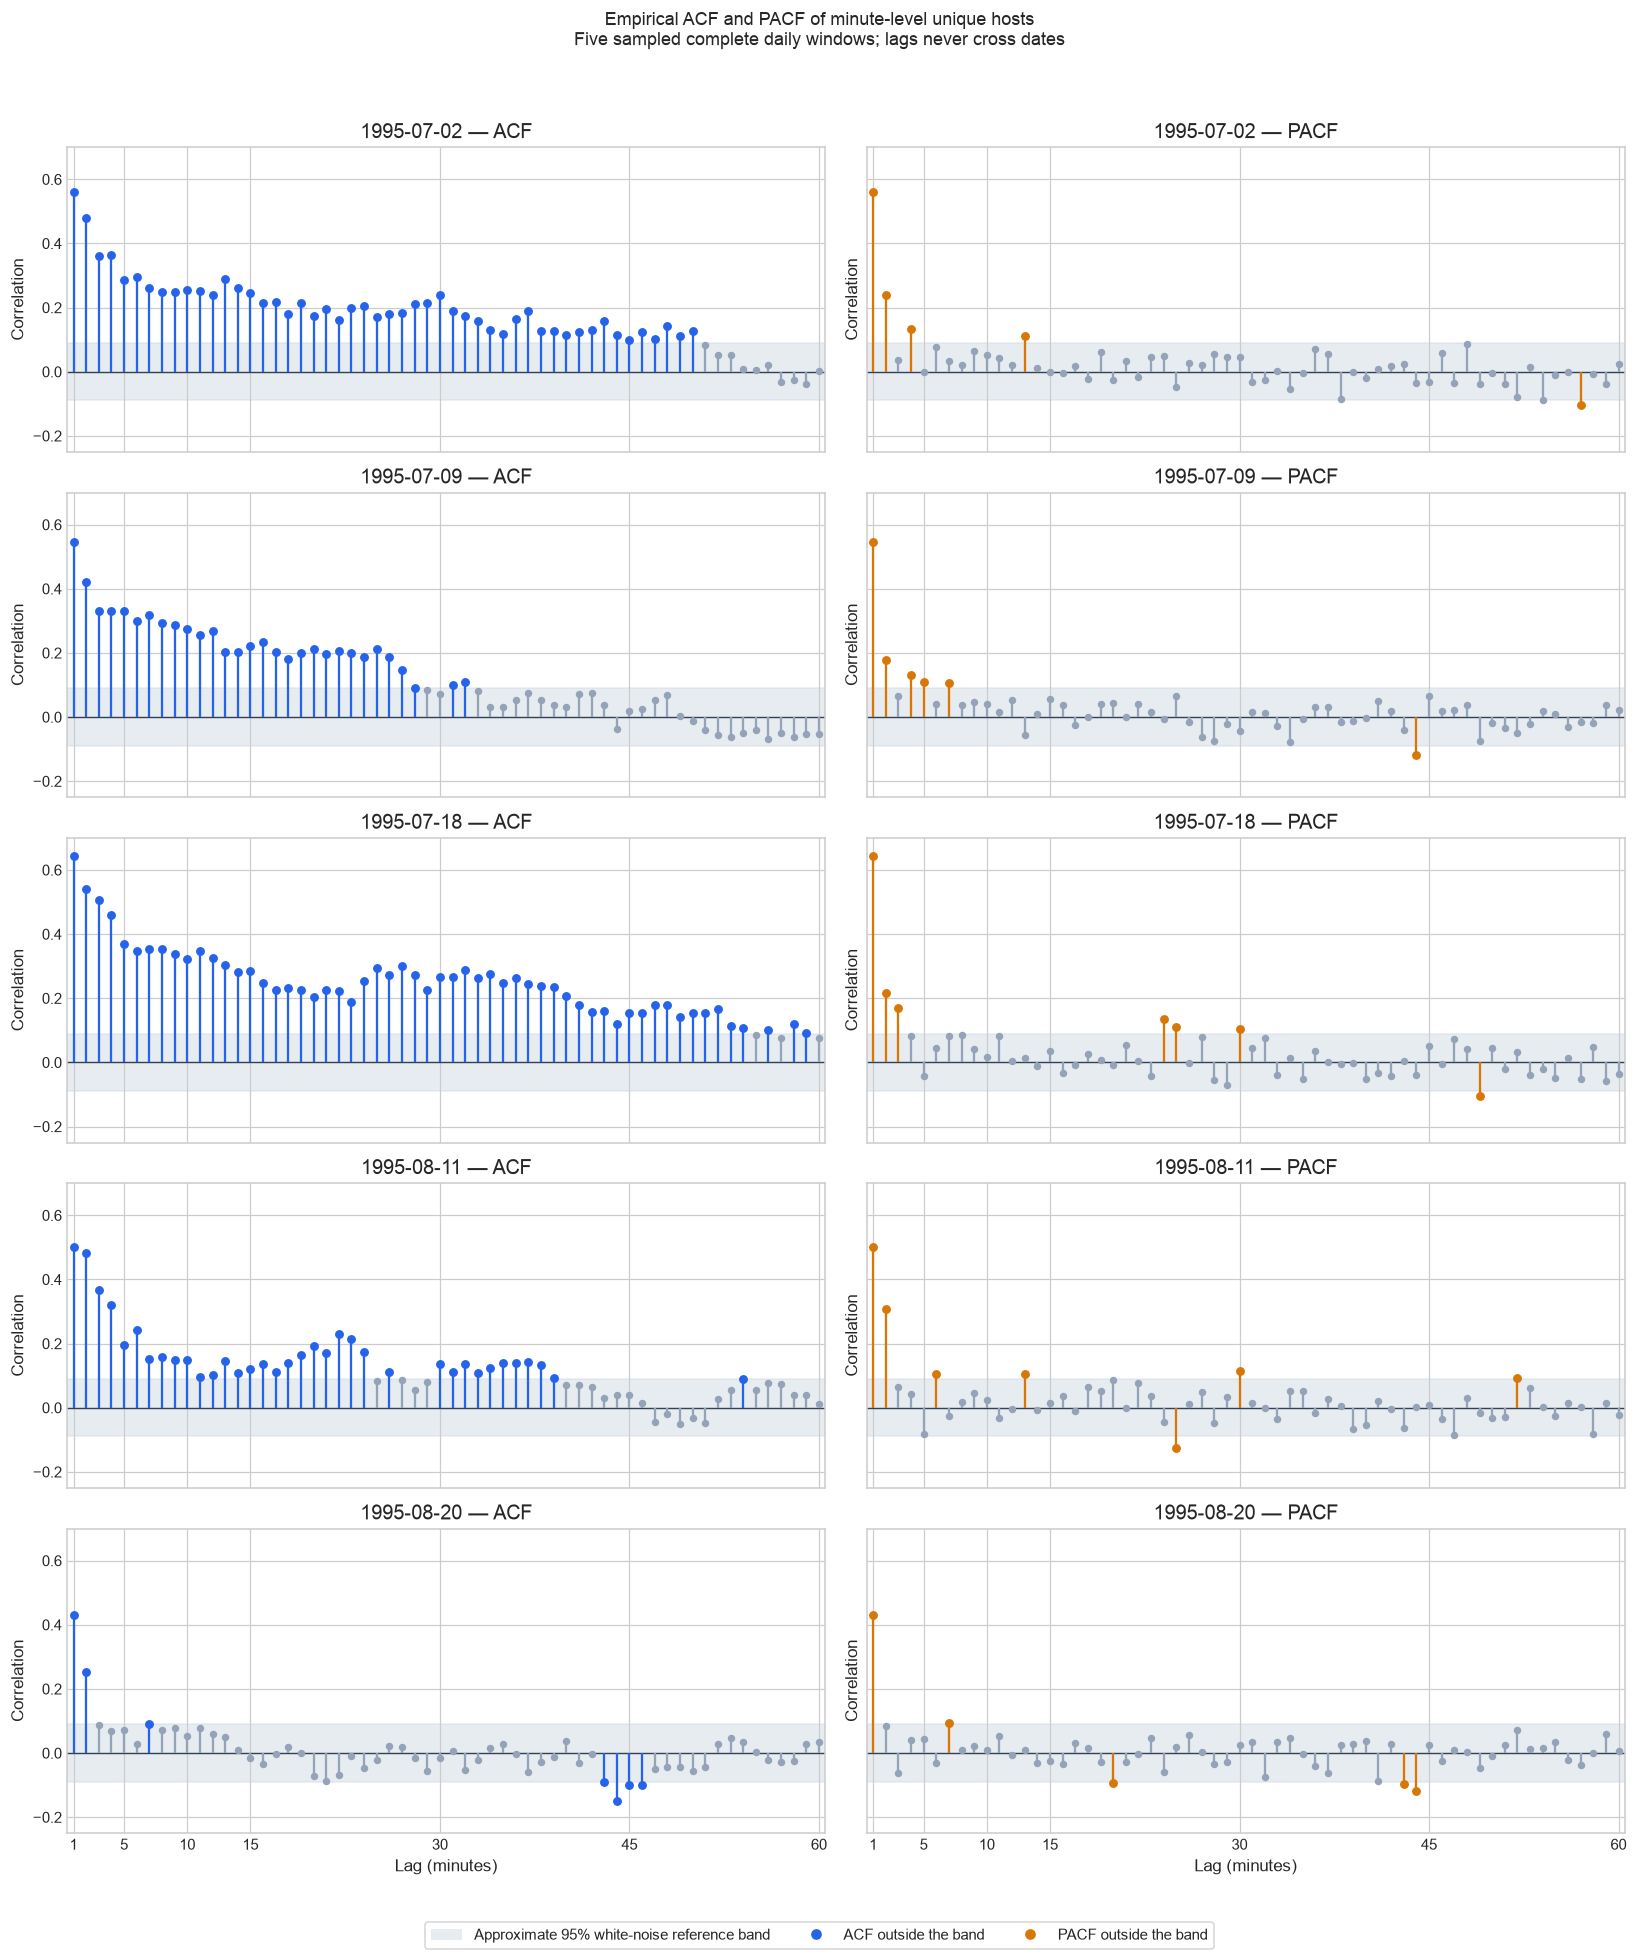

In [85]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

dependence_lags = np.arange(1, MAX_DAILY_LAG + 1)
fig_daily_dependence, dependence_axes = plt.subplots(
    len(selected_poisson_days),
    2,
    figsize=(15, 18),
    sharex=True,
    sharey=True,
)

for row_index, day in enumerate(selected_poisson_days):
    estimates = daily_dependence_estimates[pd.Timestamp(day)]

    for column_index, (name, values, color) in enumerate(
        [
            ("ACF", estimates["acf"][1:], "#2563EB"),
            ("PACF", estimates["pacf"][1:], "#D97706"),
        ]
    ):
        axis = dependence_axes[row_index, column_index]
        outside_band = np.abs(values) > WHITE_NOISE_95_BOUND

        axis.axhspan(
            -WHITE_NOISE_95_BOUND,
            WHITE_NOISE_95_BOUND,
            color="#CBD5E1",
            alpha=0.45,
            zorder=0,
        )
        axis.axhline(0, color="#334155", linewidth=0.9, zorder=1)
        axis.vlines(
            dependence_lags,
            0,
            values,
            color=np.where(outside_band, color, "#94A3B8"),
            linewidth=1.5,
            zorder=2,
        )
        axis.scatter(
            dependence_lags[~outside_band],
            values[~outside_band],
            color="#94A3B8",
            s=15,
            zorder=3,
        )
        axis.scatter(
            dependence_lags[outside_band],
            values[outside_band],
            color=color,
            s=23,
            zorder=4,
        )
        axis.set(
            title=f"{day:%Y-%m-%d} — {name}",
            ylabel="Correlation",
            xlim=(0.5, MAX_DAILY_LAG + 0.5),
            ylim=(-0.25, 0.70),
            xticks=[1, 5, 10, 15, 30, 45, 60],
        )
        if row_index == len(selected_poisson_days) - 1:
            axis.set_xlabel("Lag (minutes)")

legend_handles = [
    Patch(
        facecolor="#CBD5E1",
        alpha=0.45,
        label="Approximate 95% white-noise reference band",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#2563EB",
        markeredgecolor="#2563EB",
        label="ACF outside the band",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#D97706",
        markeredgecolor="#D97706",
        label="PACF outside the band",
    ),
]
fig_daily_dependence.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.012),
)
fig_daily_dependence.suptitle(
    "Empirical ACF and PACF of minute-level unique hosts\n"
    "Five sampled complete daily windows; lags never cross dates",
    y=0.995,
)
plt.tight_layout(rect=(0, 0.045, 1, 0.975))
plt.show()


### 7.5 Interpretation of the original ACF and PACF

All five dates have strong positive lag-1 autocorrelation:

$$
0.429\leq\widehat{\rho}_d(1)\leq0.642.
$$

The original minute-level unique-host observations are therefore not independent. A minute with an unusually high count tends to be followed by another relatively high-count minute, and the strength and duration of this dependence vary by date.

- **18 July has the strongest and most persistent dependence.** Its ACF equals 0.642 at lag 1, 0.370 at lag 5, and 0.287 at lag 15. Fifty-seven of the first 60 ACF values lie outside the pointwise reference band.
- **2 July and 9 July also decay slowly.** Their lag-15 ACF values are 0.245 and 0.221.
- **11 August has clear short-run dependence with a weaker longer tail.** Its ACF falls from 0.501 at lag 1 to 0.120 at lag 15.
- **20 August has the shortest apparent memory.** Its ACF falls from 0.429 at lag 1 to 0.071 at lag 5 and $-0.015$ at lag 15; most later values lie inside the reference band.

The largest PACF values are concentrated at early lags. Lags 1 and 2 are important for the first four dates; 18 July also has a clear lag-3 value, while 2 July and 9 July have notable lag-4 values. The 20 August PACF is dominated by lag 1. This pattern suggests that low autoregressive orders are sensible candidates, but it does not supply one universal cutoff shared by all dates.

Two cautions are essential. First, 60 pointwise comparisons are shown, so isolated later PACF spikes should not automatically be treated as additional autoregressive terms. Second, the ACF is calculated from the raw counts. A slowly changing intraday mean creates positive autocorrelation even when the remaining stochastic component has shorter memory. If

$$
X_{d,m}=s_m+e_{d,m},
$$

then the original ACF combines variation in the common mean $s_m$ with dependence in $e_{d,m}$. Subsections 7.6 and 7.7 repeat the calculation after removing the estimated common seasonal mean.


### 7.6 Results for the seasonally adjusted integer counts

The following cells repeat the complete procedure on `unique_hosts_seasonally_adjusted` from the saved adjusted CSV. The same five dates, 481 observations per date, lag range $1$–$60$, Yule–Walker PACF estimator, and pointwise reference band are retained. For adjusted date $d$, the calculations are applied to

$$
Z^{\mathrm{int}}_{d,1},\ldots,Z^{\mathrm{int}}_{d,481}.
$$

The output includes both the adjusted dependence summary and a direct before-and-after table. A positive ACF change means that the adjusted count series has stronger measured dependence at that lag; a negative change means weaker measured dependence.


In [ ]:
# Reload the exact integer-adjusted response saved in subsection 4.5.
adjusted_dependence_csv = (
    DATA_DIR / "NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv"
)
saved_adjusted_dependence_data = pd.read_csv(
    adjusted_dependence_csv,
    parse_dates=["minute", "date"],
)
saved_adjusted_dependence_data["date"] = saved_adjusted_dependence_data[
    "date"
].dt.normalize()

adjusted_dependence_required_columns = {
    "date",
    "minute_in_window",
    "unique_hosts_seasonally_adjusted",
}
adjusted_dependence_missing_columns = (
    adjusted_dependence_required_columns.difference(
        saved_adjusted_dependence_data.columns
    )
)
if adjusted_dependence_missing_columns:
    raise ValueError(
        "Saved adjusted data is missing columns: "
        + ", ".join(sorted(adjusted_dependence_missing_columns))
    )
if saved_adjusted_dependence_data.duplicated(
    ["date", "minute_in_window"]
).any():
    raise ValueError(
        "The adjusted CSV contains duplicate date-minute observations."
    )

selected_adjusted_dependence_data = saved_adjusted_dependence_data.loc[
    saved_adjusted_dependence_data["date"].isin(selected_poisson_days),
    [
        "date",
        "minute_in_window",
        "unique_hosts_seasonally_adjusted",
    ],
].copy()
adjusted_dependence_window_sizes = selected_adjusted_dependence_data.groupby(
    "date"
).size()
if not adjusted_dependence_window_sizes.eq(
    minutes_per_paper_window
).all():
    raise AssertionError(
        "A selected adjusted date does not contain exactly 481 observations."
    )
if selected_adjusted_dependence_data[
    "unique_hosts_seasonally_adjusted"
].isna().any():
    raise AssertionError("A selected adjusted daily window contains a gap.")

adjusted_daily_dependence_estimates = {}
adjusted_dependence_summary_records = []

for day in selected_poisson_days:
    adjusted_day_series = (
        selected_adjusted_dependence_data.loc[
            selected_adjusted_dependence_data["date"].eq(day),
            ["minute_in_window", "unique_hosts_seasonally_adjusted"],
        ]
        .sort_values("minute_in_window")[
            "unique_hosts_seasonally_adjusted"
        ]
        .to_numpy(dtype=float)
    )
    if len(adjusted_day_series) != minutes_per_paper_window:
        raise AssertionError(
            f"{day:%Y-%m-%d} does not contain exactly 481 observations."
        )

    adjusted_acf_values = empirical_acf(
        adjusted_day_series,
        nlags=MAX_DAILY_LAG,
        fft=True,
    )
    adjusted_pacf_values = empirical_pacf(
        adjusted_day_series,
        nlags=MAX_DAILY_LAG,
        method="ywmle",
    )
    adjusted_daily_dependence_estimates[pd.Timestamp(day)] = {
        "acf": adjusted_acf_values,
        "pacf": adjusted_pacf_values,
    }

    adjusted_significant_acf_lags = (
        np.flatnonzero(
            np.abs(adjusted_acf_values[1:]) > WHITE_NOISE_95_BOUND
        )
        + 1
    )
    adjusted_significant_pacf_lags = (
        np.flatnonzero(
            np.abs(adjusted_pacf_values[1:]) > WHITE_NOISE_95_BOUND
        )
        + 1
    )
    adjusted_short_significant_pacf_lags = (
        adjusted_significant_pacf_lags[
            adjusted_significant_pacf_lags <= 10
        ]
    )

    adjusted_dependence_summary_records.append(
        {
            "date": pd.Timestamp(day),
            "ACF(1)": adjusted_acf_values[1],
            "ACF(5)": adjusted_acf_values[5],
            "ACF(15)": adjusted_acf_values[15],
            "significant ACF lags 1-60": len(
                adjusted_significant_acf_lags
            ),
            "significant PACF lags 1-60": len(
                adjusted_significant_pacf_lags
            ),
            "significant PACF lags 1-10": (
                ", ".join(
                    map(str, adjusted_short_significant_pacf_lags)
                )
                if len(adjusted_short_significant_pacf_lags)
                else "none"
            ),
        }
    )

adjusted_daily_dependence_summary = (
    pd.DataFrame(adjusted_dependence_summary_records)
    .set_index("date")
    .sort_index()
)

dependence_before_after_comparison = pd.DataFrame(
    {
        "original ACF(1)": daily_dependence_summary["ACF(1)"],
        "adjusted ACF(1)": adjusted_daily_dependence_summary["ACF(1)"],
        "change ACF(1)": (
            adjusted_daily_dependence_summary["ACF(1)"]
            - daily_dependence_summary["ACF(1)"]
        ),
        "original ACF(15)": daily_dependence_summary["ACF(15)"],
        "adjusted ACF(15)": adjusted_daily_dependence_summary["ACF(15)"],
        "change ACF(15)": (
            adjusted_daily_dependence_summary["ACF(15)"]
            - daily_dependence_summary["ACF(15)"]
        ),
        "original significant ACF lags": daily_dependence_summary[
            "significant ACF lags 1-60"
        ],
        "adjusted significant ACF lags": adjusted_daily_dependence_summary[
            "significant ACF lags 1-60"
        ],
    }
)

print(f"Approximate 95% white-noise bound: ±{WHITE_NOISE_95_BOUND:.3f}")
print("Every adjusted ACF and PACF remains inside one 481-minute day.")
print("\nSeasonally adjusted dependence summary")
print(
    adjusted_daily_dependence_summary.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)
print("\nOriginal versus adjusted dependence")
print(
    dependence_before_after_comparison.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)


Approximate 95% white-noise bound: ±0.089
Every adjusted ACF and PACF remains inside one 481-minute day.

Seasonally adjusted dependence summary
            ACF(1)  ACF(5)  ACF(15)  significant ACF lags 1-60  significant PACF lags 1-60 significant PACF lags 1-10
date                                                                                                                 
1995-07-02   0.568   0.310    0.270                         50                           7                    1, 2, 4
1995-07-09   0.538   0.315    0.200                         27                           6              1, 2, 4, 5, 7
1995-07-18   0.538   0.202    0.127                         35                           7                    1, 2, 3
1995-08-11   0.431   0.099    0.012                         14                           6                    1, 2, 5
1995-08-20   0.538   0.249    0.130                         35                           4                 1, 2, 4, 7

Original versus adjusted dep

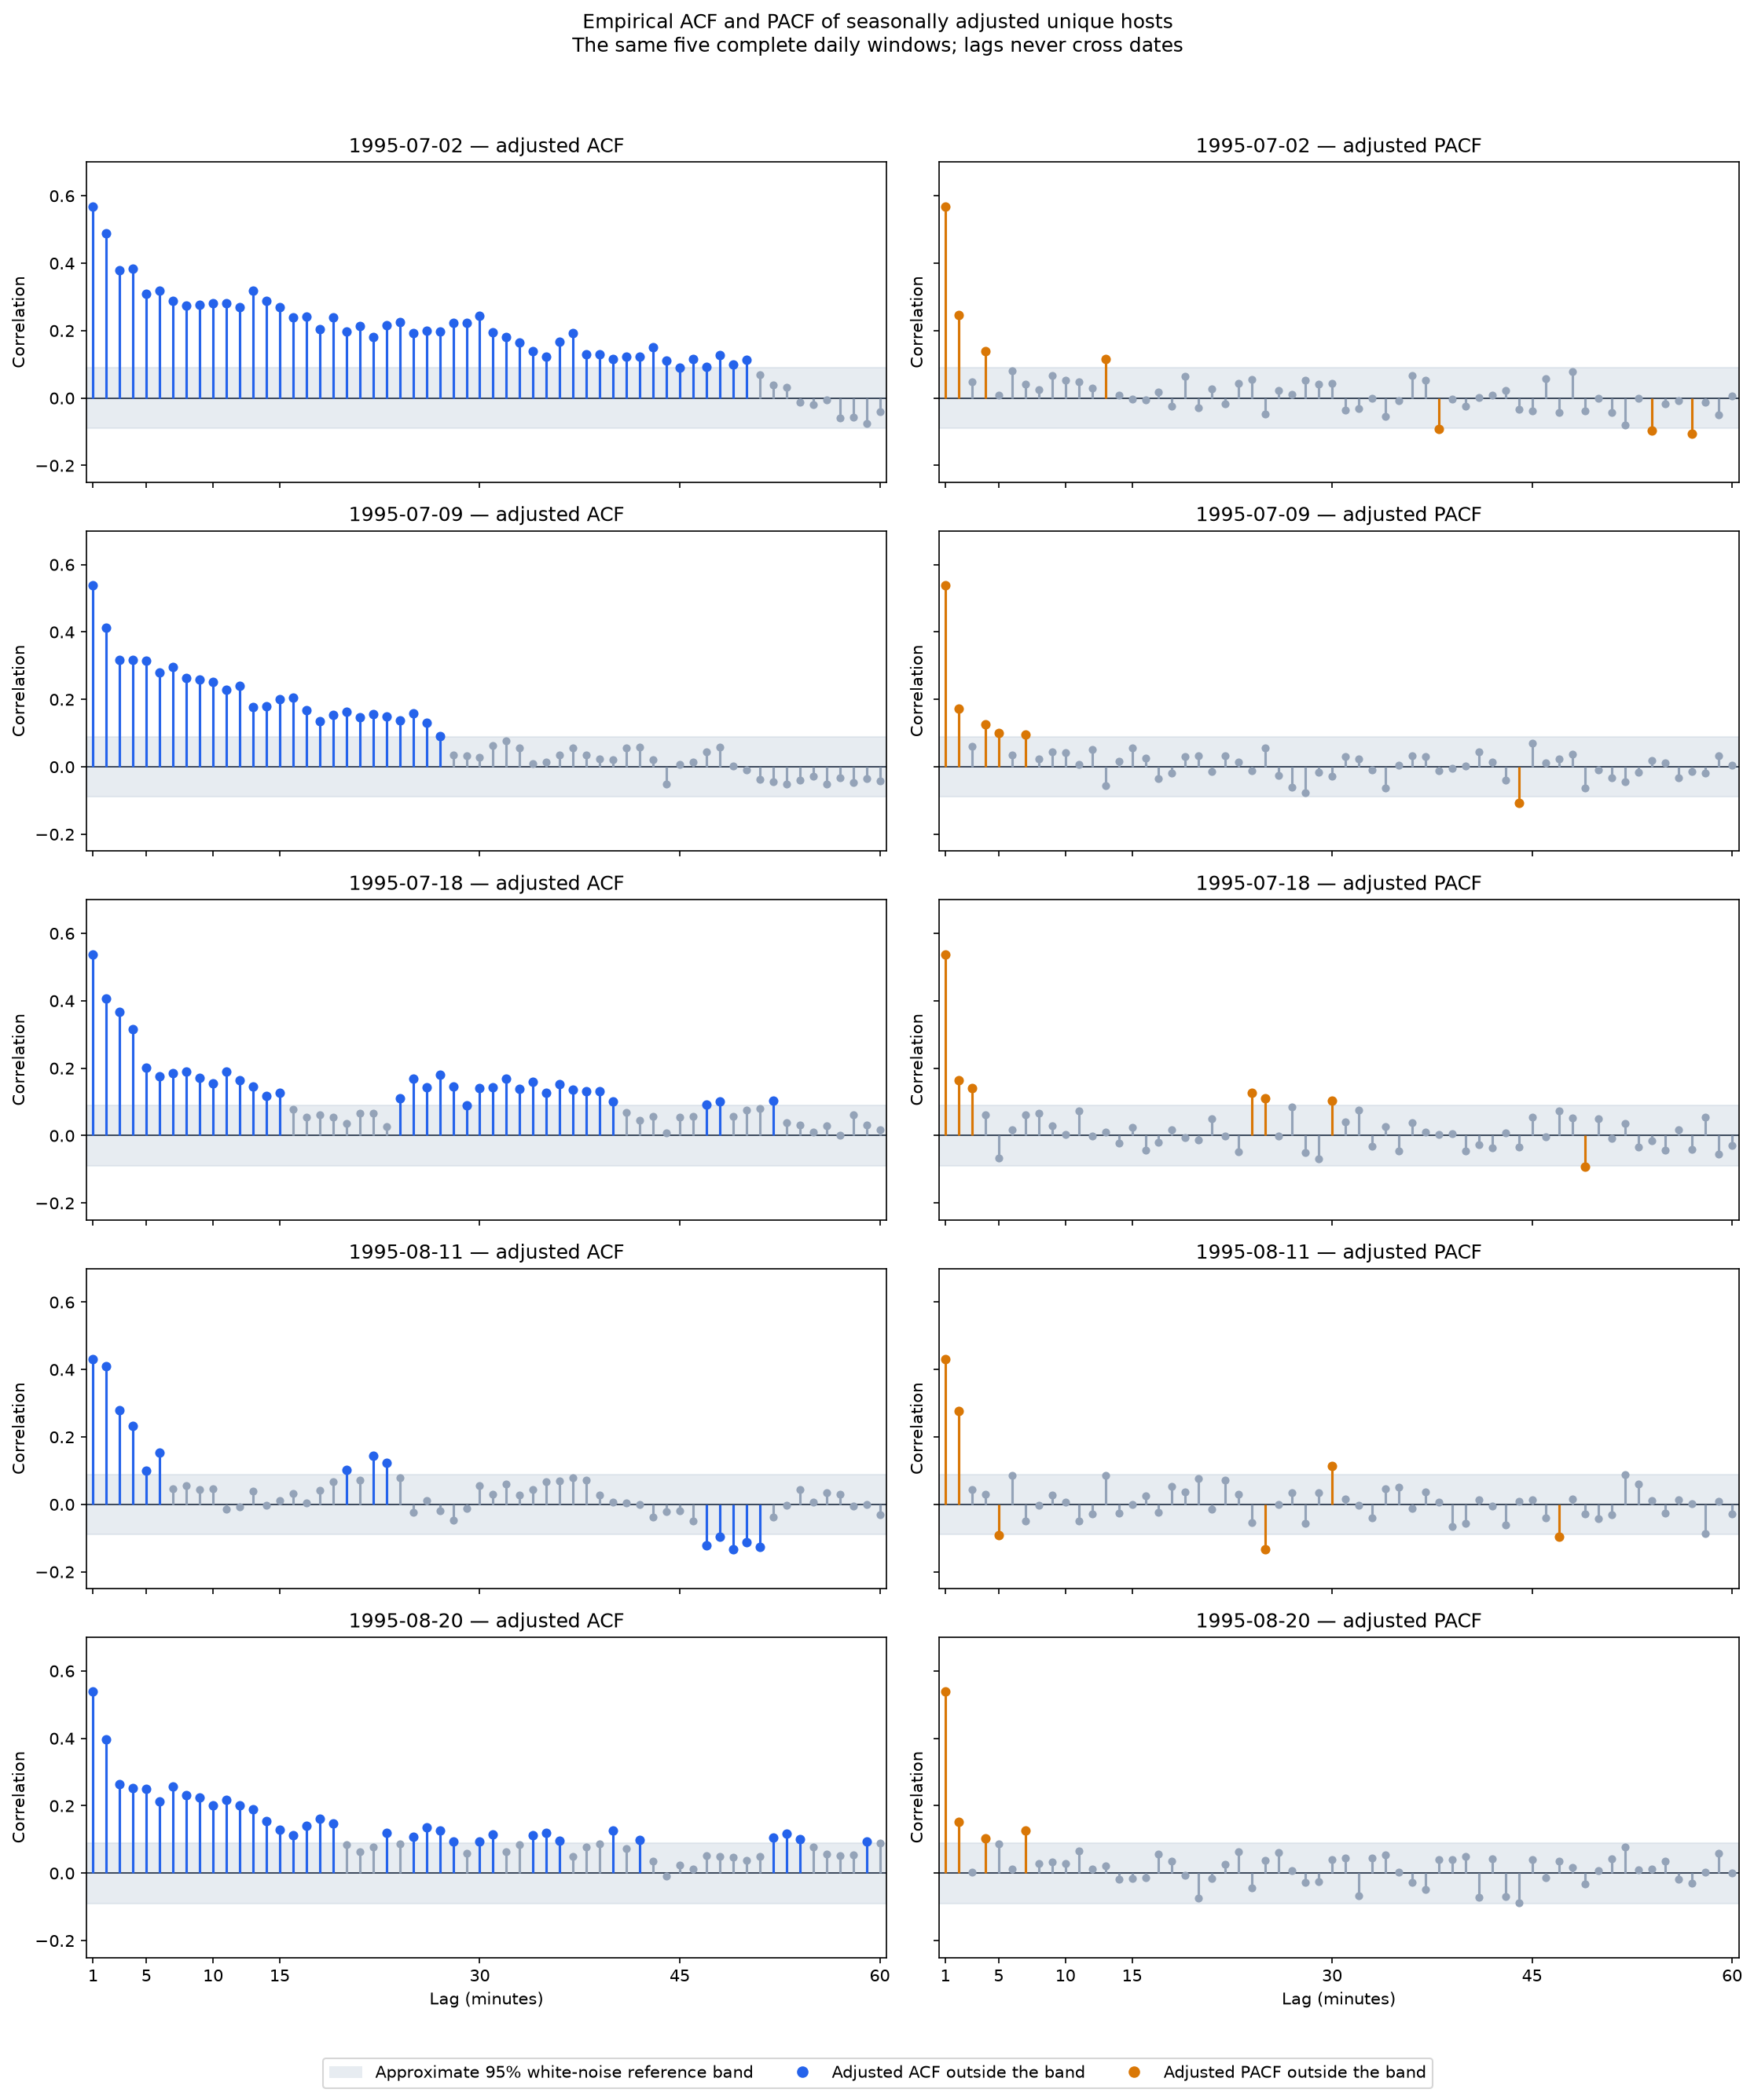

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


adjusted_dependence_lags = np.arange(
    1,
    MAX_DAILY_LAG + 1,
)
fig_adjusted_daily_dependence, adjusted_dependence_axes = plt.subplots(
    len(selected_poisson_days),
    2,
    figsize=(15, 18),
    sharex=True,
    sharey=True,
)

for row_index, day in enumerate(selected_poisson_days):
    adjusted_estimates = adjusted_daily_dependence_estimates[
        pd.Timestamp(day)
    ]

    for column_index, (name, values, color) in enumerate(
        [
            ("ACF", adjusted_estimates["acf"][1:], "#2563EB"),
            ("PACF", adjusted_estimates["pacf"][1:], "#D97706"),
        ]
    ):
        axis = adjusted_dependence_axes[row_index, column_index]
        outside_band = np.abs(values) > WHITE_NOISE_95_BOUND

        axis.axhspan(
            -WHITE_NOISE_95_BOUND,
            WHITE_NOISE_95_BOUND,
            color="#CBD5E1",
            alpha=0.45,
            zorder=0,
        )
        axis.axhline(0, color="#334155", linewidth=0.9, zorder=1)
        axis.vlines(
            adjusted_dependence_lags,
            0,
            values,
            color=np.where(outside_band, color, "#94A3B8"),
            linewidth=1.5,
            zorder=2,
        )
        axis.scatter(
            adjusted_dependence_lags[~outside_band],
            values[~outside_band],
            color="#94A3B8",
            s=15,
            zorder=3,
        )
        axis.scatter(
            adjusted_dependence_lags[outside_band],
            values[outside_band],
            color=color,
            s=23,
            zorder=4,
        )
        axis.set(
            title=f"{day:%Y-%m-%d} — adjusted {name}",
            ylabel="Correlation",
            xlim=(0.5, MAX_DAILY_LAG + 0.5),
            ylim=(-0.25, 0.70),
            xticks=[1, 5, 10, 15, 30, 45, 60],
        )
        if row_index == len(selected_poisson_days) - 1:
            axis.set_xlabel("Lag (minutes)")

adjusted_dependence_legend_handles = [
    Patch(
        facecolor="#CBD5E1",
        alpha=0.45,
        label="Approximate 95% white-noise reference band",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#2563EB",
        markeredgecolor="#2563EB",
        label="Adjusted ACF outside the band",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="#D97706",
        markeredgecolor="#D97706",
        label="Adjusted PACF outside the band",
    ),
]
fig_adjusted_daily_dependence.legend(
    handles=adjusted_dependence_legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.012),
)
fig_adjusted_daily_dependence.suptitle(
    "Empirical ACF and PACF of seasonally adjusted unique hosts\n"
    "The same five complete daily windows; lags never cross dates",
    y=0.995,
)
plt.tight_layout(rect=(0, 0.045, 1, 0.975))
plt.show()


### 7.7 Interpretation after seasonal adjustment

All five adjusted dates retain strong positive lag-1 autocorrelation:

$$
0.431\leq\widehat{\rho}^{\mathrm{adj}}_d(1)\leq0.568.
$$

Removing the common intraday mean therefore does not make the minute counts independent. The adjustment changes the longer-lag pattern differently across dates:

| Date | Adjusted ACF(1) | Adjusted ACF(5) | Adjusted ACF(15) | Adjusted ACF lags outside band |
|---|---:|---:|---:|---:|
| 1995-07-02 | 0.568 | 0.310 | 0.270 | 50 |
| 1995-07-09 | 0.538 | 0.315 | 0.200 | 27 |
| 1995-07-18 | 0.538 | 0.202 | 0.127 | 35 |
| 1995-08-11 | 0.431 | 0.099 | 0.012 | 14 |
| 1995-08-20 | 0.538 | 0.249 | 0.130 | 35 |

- **18 July and 11 August show the clearest reductions in persistence.** For 18 July, ACF(15) falls from 0.287 to 0.127 and the number of highlighted ACF lags falls from 57 to 35. For 11 August, ACF(15) falls from 0.120 to 0.012 and the highlighted count falls from 36 to 14.
- **9 July changes only modestly.** Its ACF is slightly lower after adjustment, and its highlighted ACF-lag count falls from 30 to 27.
- **2 July remains highly persistent.** Its ACF values increase slightly and 50 of 60 lags remain outside the band, so the common seasonal profile was not the principal source of its long dependence.
- **20 August moves in the opposite direction.** ACF(15) rises from $-0.015$ to 0.130 and the number of highlighted ACF lags rises from 7 to 35. Subtracting the average profile can expose a date-specific pattern that was partly cancelled by the common profile; clipping and rounding can also change correlations slightly.

The adjusted PACFs remain concentrated mainly at early lags. The highlighted lags among the first ten are 1, 2, and 4 for 2 July; 1, 2, 4, 5, and 7 for 9 July; 1, 2, and 3 for 18 July; 1, 2, and 5 for 11 August; and 1, 2, 4, and 7 for 20 August. The presence of lag 1 on every date supports testing low-order autoregressive count models, but the additional lags vary enough that one common order should not be selected from these plots alone.

The comparison demonstrates that seasonal removal and serial-dependence removal are different operations. Subtracting $\widehat{s}_m-\overline{s}$ removes the estimated average clock-time level. It does not remove short-run stochastic dependence or date-specific time patterns. Depending on how a date's own trajectory relates to the common profile, its empirical ACF can decrease or increase.

### Overall modeling implication

The exploratory evidence is internally consistent: the original counts have a pronounced time-of-day mean, the adjustment improves several stationarity and marginal-dispersion diagnostics, and both datasets retain substantial short-run serial dependence. A defensible next modeling stage should therefore:

1. compare modeling the original counts with an explicit non-cyclic minute-of-window mean against modeling the integer-adjusted counts;
2. preserve daily boundaries when constructing every lagged variable;
3. compare a small set of candidate INAR orders suggested by the early adjusted PACF values rather than adopting one visual cutoff;
4. allow a count distribution more flexible than Poisson on dates that remain overdispersed; and
5. select the final specification using likelihood criteria, residual ACF/PACF, dispersion diagnostics, and out-of-sample validation.

The present notebook completes the data construction and exploratory diagnosis. It deliberately stops before fitting a final autoregressive count model.
